# Combined EDA — German grid load and residual load

- ℹ️ Plots moved from individual EDA's with [`Claude Spec 03 combined-cherry-picked-eda.md`](../../.claude/specs/03-combined-cherry-picked-eda.md)
- This notebook contains our team-picked plots that bring good insight on our dataset

## Conventions

- We use `time_series` as main dataframe for our EDA
- `SERIES` is used for all features of the smard.csv
- `DERIVED` is used for all engineered features from smard.csv
- `YEARS` is calculated during run time - this makes dynamic plots possible if you decide to run this notebook with a **smaller** or **wider** **time range**
  - this affects: color maps & plot settings
- We use a single ``color config`` for all plots in [1.2](#12-colour-configuration)

---

## 1 Setup

`data/` is **gitignored**, so `data/smard.csv` does not come with a clone. Regenerate it by
running [`notebooks/API-connection.ipynb`](../API-connection.ipynb) top to bottom — it pulls the
SMARD API (no key required) and writes the file in German Excel CSV format
(`sep=";"`, `decimal=","`, `utf-8-sig`).

The data directory is resolved by walking **upward** from the working directory rather than by a
fixed `"../../data/smard.csv"`: this notebook sits two levels below the repo root, and a
hardcoded depth breaks as soon as the kernel starts somewhere else (nbconvert from the root, for
instance).

In [64]:
from pathlib import Path

import holidays
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.max_open_warning"] = 0  # this notebook draws ~30 figures on purpose

# Walk up from the working directory to the first parent holding a `data/` folder
DATA_DIR = next(
    (p / "data" for p in (Path.cwd(), *Path.cwd().parents) if (p / "data").is_dir()),
    None,
)
if DATA_DIR is None:
    raise RuntimeError(
        f"no data/ directory found in {Path.cwd()} or any parent — start the kernel inside the "
        "repository, then re-run."
    )
DATA = DATA_DIR / "smard.csv"

if not DATA.exists():
    raise FileNotFoundError(
        f"{DATA} not found. data/ is gitignored, so the file is not in a fresh clone — "
        "regenerate it by running notebooks/API-connection.ipynb top to bottom."
    )

print(f"pandas {pd.__version__} · numpy {np.__version__} · seaborn {sns.__version__}")
print(f"Data directory: {DATA}")

pandas 3.0.5 · numpy 2.5.3 · seaborn 0.13.2
Data directory: c:\Users\Robert\Coding\neueFische_Data-Science\grid-stress\data\smard.csv


### 1.1 Helpers

- `_complete_periods` *drops periods the data does not fully cover*. Like starting the first observation on a wednesday. Same for monthly aggregations of the end of the data is in the middle of september. A plain `.resample()` produces fake edges.
- `style_timeseries` and `seasonal_plot` use a dynamic `ylabel`: this is used to set the unit to either **MWh** `energy` or **MW** `power` depending on the plot

In [65]:
def _complete_periods(index, freq):
    """The calendar periods of `freq` that `index` covers completely.

    The one edge rule of this notebook, in one place. A period counts only if it starts no
    earlier than the first observation and ends no later than the last observation's closing
    edge. Both `period_mean` and `period_energy` defer to this.
    """
    periods = index.to_period(freq).unique().sort_values()
    complete = (periods.start_time >= index.min()) & (
        periods.end_time <= index.max() + pd.Timedelta("1h")
    )
    return periods[complete]


def period_mean(series, freq):
    """Mean of `series` per calendar period (`"W"`, `"M"`, ...), indexed by period start.

    Periods that the data does not cover completely are dropped, so the edges of a plot are not
    partial-period artefacts. Note the rule is "not fully covered", not "the first and the last".
    """
    agg = series.groupby(series.index.to_period(freq)).mean()
    agg = agg.loc[_complete_periods(series.index, freq)]
    agg.index = agg.index.start_time
    return agg


def period_energy(series, freq, drop_incomplete=True):
    """Per-period aggregate of `series` in both project reporting units.

    Returns a DataFrame indexed by period start:

    ``mwh_per_day``
        period sum / calendar days in the period — the energy view (MWh/day).
    ``avg_mw``
        period sum / hours **actually present** — the level view (MW).
        Deliberately not ``mwh_per_day / 24``: a month containing the spring Daylight-Saving-Time switch holds 743 hours, not 744.
    ``hours``, ``days``
        the two denominators, exposed so a comparison table needs no second copy of this
        arithmetic.

    Incomplete periods are dropped by the same `_complete_periods` rule as `period_mean`.
    """
    grouped = series.groupby(series.index.to_period(freq))
    total, hours = grouped.sum(), grouped.size()
    periods = total.index

    if drop_incomplete:
        keep = _complete_periods(series.index, freq)
        total, hours, periods = total.loc[keep], hours.loc[keep], keep

    # Freq-generic: 7 for every week, 28-31 for months. `days_in_month` would be "M"-only.
    days = (periods.end_time.normalize() - periods.start_time).days + 1

    # .to_numpy() on every right-hand side: aligning a PeriodIndex-backed Series against a
    # DatetimeIndex-derived array silently yields all-NaN.
    return pd.DataFrame(
        {
            "mwh_per_day": total.to_numpy() / days,
            "avg_mw": total.to_numpy() / hours.to_numpy(),
            "hours": hours.to_numpy(),
            "days": np.asarray(days),
        },
        index=periods.start_time,
    )

In [66]:
def style_timeseries(ax, title, ylabel):
    """Custom grid, no box, year ticks.

    `ylabel` is required: every plot must state whether it shows MWh, average MW or MWh/day.
    """
    ax.set_title(
        title,
        loc="center",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("")
    ax.set_ylabel(
        ylabel,
        color="grey"
    )
    ax.grid(
        axis="y",
        color="0.9",
        linewidth=0.8
    )
    ax.set_axisbelow(True)

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    ax.tick_params(
        colors="black",
        length=0  # hide ticks of values
    )
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator((1, 4, 7, 10)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")


def seasonal_plot(df, y_value, title, ylabel):
    """Creates a seasonal plot from a dataframe.

    Args:
        df (DataFrame): frame with separate `month` and `year` columns, already aggregated to
            one row per (year, month). Passing raw hourly data makes seaborn bootstrap a
            confidence interval per cell over tens of thousands of rows — minutes of runtime,
            meaningless band.
        y_value (str): name of the y-value to plot
        title (str): title of the plot
        ylabel (str): axis description, including units. Required, and actually applied.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    sns.lineplot(
        data=df,
        x="month",
        y=y_value,
        hue="year",
        palette="viridis",
        legend=True,
        ax=ax
    )
    ax.set_xlabel("Month")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

### 1.2 Colour configuration

- Every plot in this notebook reads its colours from the mappings below
- **`grid_load` should always be set to a somewhat red** | **`residual_load` to a near-black** - this is similar to the SMARD visualization
- all SMARD forecasts are **dashed**
- weekends and weekdays should be different colors
- residual load extremes should be different colors

In [67]:
from matplotlib.colors import (
    LinearSegmentedColormap, ListedColormap, Normalize, TwoSlopeNorm,
)

# Base palette - set colors here
COLORS = {
    "navy":   "#17365D",
    "blue":   "#2C6EBA",
    "teal":   "#4AA3A5",
    "green":  "#2F8F5B",
    "mint":   "#6FBF9B",
    "gold":   "#D9A53A",
    "orange": "#E95D0F",
    "coral":  "#E76F51",
    "red":    "#B10F0F",
    "purple": "#9274B8",
    "gray":   "#AEB8C5",
    "black":  "#1C1C1C",
    "ink":    "#17365D",
    "muted":  "#707B8C",
    "grid":   "#E3E8EF",
    "cream":  "#F7F3E7",
}

# One colour per feature. Forecasts share their measured counterpart's colour.
SERIES_COLOR = {
    "grid_load":         COLORS["red"],
    "residual_load":     COLORS["black"],
    "wind_on":           COLORS["teal"],
    "wind_off":          COLORS["blue"],
    "solar":             COLORS["gold"],
    "renewables":        COLORS["green"],
    "wind_total":        COLORS["purple"],
    "fc_grid_load":      COLORS["red"],
    "fc_residual_load":  COLORS["black"],
    "fc_gen_wind_solar": COLORS["green"],
}

# Labels for all features
SERIES_LABEL = {
    "grid_load":         "Grid load",
    "residual_load":     "Residual load",
    "wind_on":           "Onshore wind",
    "wind_off":          "Offshore wind",
    "solar":             "Solar",
    "renewables":        "Wind + solar",
    "wind_total":        "Wind (on + offshore)",
    "fc_grid_load":      "Forecast grid load",
    "fc_residual_load":            "Forecast residual load",
    "fc_gen_wind_solar": "Forecast wind + solar",
}

# Day type is a dimension of its own, not a series: warm for working days, cool for weekends.
# Kept distinct from grid_load's red so a day-type split never reads as a different series.
DAY_TYPE_COLOR = {
    "weekday": COLORS["orange"],
    "weekend": COLORS["blue"]
}

# Residual-load extremes, wherever they are shown as a pair: cool for oversupply, hot for undersupply.
TAIL_COLOR = {
    "low": COLORS["blue"],
    "high": COLORS["red"]
}

# Column order
FORECAST_COLS = ["fc_gen_wind_solar", "fc_grid_load", "fc_residual_load"]
HEADLINE_COLS = ["grid_load", "residual_load"]  # drawn slightly heavier than the rest

# --- Styling functions ---
def series_style(col, **overrides):
    """Line kwargs for `col`: colour, width and dash pattern, from the configuration above."""
    style = {
        "color": SERIES_COLOR[col],
        "linewidth": 2.4 if col in HEADLINE_COLS or col in FORECAST_COLS[1:] else 1.8,
        "linestyle": "--" if col in FORECAST_COLS else "-",
        "label": SERIES_LABEL[col],
    }
    style.update(overrides)
    return style


def year_colors(years, cmap="viridis"):
    """A colour per year, sampled from `cmap` — never a fixed year-to-colour table."""
    years = list(years)
    sampled = plt.get_cmap(cmap)(np.linspace(0.05, 0.95, len(years)))
    return dict(zip(years, sampled))


# --- Color Maps ---
# Heatmap scales.
# `grid_load` is strictly positive and takes a sequential ramp towards its own red
# `residual_load` crosses zero and needs a diverging, zero-centred scale — they cannot share one colour bar.
GRID_LOAD_CMAP = LinearSegmentedColormap.from_list(
    "gridstress_grid_load",
    ["#FBF1EF", "#F0C3B8", "#DE8B76", COLORS["coral"], COLORS["red"]],
)
RESIDUAL_CMAP = LinearSegmentedColormap.from_list(
    "gridstress_residual",
    [COLORS["green"], "#B9DCC7", "#FFFFFF", "#8A8A8A", COLORS["black"]],
)

# Hari's remaining scales, reused unchanged by the plots ported from that notebook.
SUPPORT_CMAP = LinearSegmentedColormap.from_list(
    "gridstress_support",
    ["#F7F9FC", "#D7E6F3", "#82B6D9", COLORS["blue"], COLORS["navy"]],
)
DIV_CMAP = LinearSegmentedColormap.from_list(
    "gridstress_diverging",
    [COLORS["teal"], "#DCEEEF", "#FFFFFF", "#F8D1C5", COLORS["coral"]],
)
WIND_SOLAR_CMAP = LinearSegmentedColormap.from_list(
    "gridstress_wind_solar",
    ["#F8F3E7", "#F3C879", "#9BD0C3", COLORS["teal"], COLORS["green"]],
)

# Ramps are a quantity of their own — the rate of change, not a series — and get their own
# colour family, so a ramp plot can never be mistaken for a level plot.
RAMP_CMAP = LinearSegmentedColormap.from_list(
    "gridstress_ramp",
    ["#EDF6F3", "#A9D7CC", "#F5D08A", "#F28E2B", "#D95F0E", COLORS["red"]],
)
RAMP_COLOR = COLORS["coral"]


def quantile_colors(levels):
    """A colour per quantile level, light (low) to dark (high), from the ramp family."""
    levels = list(levels)
    sampled = RAMP_CMAP(np.linspace(0.30, 0.95, len(levels)))
    return dict(zip(levels, sampled))


def residual_scale(vmin, vmax):
    """Colormap and norm for a residual-load surface — zero is white in every case.

    Data that crosses zero gets the full diverging scale centred there. Data that stays on one
    side (the calendar-mean grids of §5 do) gets that side of the same scale, starting at zero,
    so the oversupply green never appears where nothing is in oversupply.
    """
    if vmin < 0 < vmax:
        return RESIDUAL_CMAP, TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    if vmin >= 0:
        half = ListedColormap(RESIDUAL_CMAP(np.linspace(0.5, 1.0, 256)))
        return half, Normalize(vmin=0, vmax=vmax)
    half = ListedColormap(RESIDUAL_CMAP(np.linspace(0.0, 0.5, 256)))
    return half, Normalize(vmin=vmin, vmax=0)


print(f"{len(SERIES_COLOR)} features coloured, {len(COLORS)} base colours")

10 features coloured, 16 base colours


### 1.3 Load and prepare

- Dtype assertion test for guarding German excel-csv conversion problems with `is_float_dtype`
- Everything after this section uses `time_series` as the converted and cleaned dataframe

In [68]:
# The CSV headers exactly as notebooks/API-connection.ipynb writes them.
COLUMNS = {
    "Wind Offshore": "wind_off",
    "Wind Onshore": "wind_on",
    "Solar": "solar",
    "Grid Load": "grid_load",
    "Residual Load": "residual_load",
    "Forecast Wind + Solar": "fc_gen_wind_solar",
    "Forecast Grid Load": "fc_grid_load",
    "Forecast Residual Load": "fc_residual_load",
}

raw = pd.read_csv(DATA, delimiter=";", encoding="utf-8-sig")

assert set(raw.columns) == {"timestamp"} | set(COLUMNS), (
    f"unexpected CSV header: {sorted(set(raw.columns) ^ ({'timestamp'} | set(COLUMNS)))}"
)

print("as read from disk — note the comma decimals and the string dtypes:")
display(raw.head(3))
display(raw.dtypes.to_frame("dtype"))

as read from disk — note the comma decimals and the string dtypes:


,timestamp,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load,Forecast Wind + Solar,Forecast Grid Load,Forecast Residual Load
0,2019-01-01 00:00,"3134,0","20314,25","0,0","43273,75","19825,5","23948,75","43213,25","19264,5"
1,2019-01-01 01:00,"2868,25","22297,25","0,0","41631,25","16465,75","25668,75","41275,75","15607,0"
2,2019-01-01 02:00,"2460,25","23168,5","0,0","40085,0","14456,25","27384,0","40187,5","12803,5"


,dtype
timestamp,str
Wind Offshore,str
Wind Onshore,str
Solar,str
Grid Load,str
Residual Load,str
Forecast Wind + Solar,str
Forecast Grid Load,str
Forecast Residual Load,str


In [69]:
raw = raw.rename(columns=COLUMNS)
raw["timestamp"] = pd.to_datetime(raw["timestamp"], format="%Y-%m-%d %H:%M")

for col in COLUMNS.values():
    raw[col] = raw[col].str.replace(",", ".").astype(float)

time_series = raw.set_index("timestamp").sort_index()
del raw  # the flat frame does not outlive the loading cells

time_series.head(3)

,wind_off,wind_on,solar,grid_load,residual_load,fc_gen_wind_solar,fc_grid_load,fc_residual_load
timestamp,,,,,,,,
2019-01-01 00:00:00,3134.00,20314.25,0.0,43273.75,19825.50,23948.75,43213.25,19264.5
2019-01-01 01:00:00,2868.25,22297.25,0.0,41631.25,16465.75,25668.75,41275.75,15607.0
2019-01-01 02:00:00,2460.25,23168.50,0.0,40085.00,14456.25,27384.00,40187.50,12803.5


In [70]:
print(f"shape           : {time_series.shape[0]:,} rows x {time_series.shape[1]} columns")
print(f"index           : {time_series.index.min()}  ->  {time_series.index.max()}")
print(
    f"index monotonic : {time_series.index.is_monotonic_increasing}, "
    f"unique: {time_series.index.is_unique}"
)
display(time_series.dtypes.to_frame("dtype"))

# Positive is_float_dtype test, not `!= object`: under pandas 3 an unconverted German-decimal
# column lands as StringDtype, and `!= object` would wave it straight through.
assert all(
    pd.api.types.is_float_dtype(time_series[c]) for c in COLUMNS.values()
), time_series.dtypes

# Snapshot for §7's closing self-check, taken before any other cell can touch the frame: a cell
# inserted anywhere in between that mutates `time_series` is caught regardless of which vintage
# of the CSV was loaded.
LOADED = {
    "rows": len(time_series),
    "start": time_series.index.min(),
    "end": time_series.index.max(),
}
print(f"\nLOADED = {LOADED}")

display(time_series.describe().T)

shape           : 67,336 rows x 8 columns
index           : 2019-01-01 00:00:00  ->  2026-09-06 23:00:00
index monotonic : True, unique: True


,dtype
wind_off,float64
wind_on,float64
solar,float64
grid_load,float64
residual_load,float64
fc_gen_wind_solar,float64
fc_grid_load,float64
fc_residual_load,float64



LOADED = {'rows': 67336, 'start': Timestamp('2019-01-01 00:00:00'), 'end': Timestamp('2026-09-06 23:00:00')}


,count,mean,std,min,25%,50%,75%,max
wind_off,67336.0,2886.531842,1966.713778,0.00,1099.7500,2657.500,4568.5625,8448.34
wind_on,67336.0,11921.592231,9416.104372,46.50,4522.2425,9235.750,17121.8750,48499.50
solar,67336.0,6704.249417,10513.098822,0.00,3.2500,237.625,10458.4675,58055.53
grid_load,67336.0,54589.353051,9639.874493,30902.75,46744.3600,54455.750,61940.6250,81319.50
residual_load,67336.0,33076.977499,14075.681791,-15561.59,23954.9375,33930.125,42797.6875,74638.75
fc_gen_wind_solar,67336.0,21419.767687,13214.972581,320.50,10430.2500,19435.125,30410.6900,75722.20
fc_grid_load,67312.0,54091.241017,9108.757681,30544.75,46644.2500,53935.125,61536.0625,77585.75
fc_residual_load,67312.0,32677.717502,13633.810476,-29003.22,24063.8550,33775.250,42218.7050,70214.25


### 1.4 — Derived columns, `SERIES` / `DERIVED`, and `YEARS`

All derived columns are defined **here, in one place**, immediately after loading. Two of them
are needed by the sanity check itself (`hour` for the night-solar test, `renewables` as the
wind+solar aggregate), so they cannot wait for the section that first plots them.

`YEARS` is computed from the loaded data and is the only permitted source of year information in
the rest of the notebook — no section may write a calendar year into code (see the note on the
one deliberate exception at the top).

`spans_gap` marks the row *following* a gap in the hourly index. The record's only gaps are the
spring DST switches, where the local hour 02:00 does not exist; `.diff()`, `.shift()` and rolling
windows all need that flag, so it is created here with everything else.

In [ ]:
SERIES = [
    "wind_off", "wind_on", "solar", "grid_load", "residual_load",
    "fc_gen_wind_solar", "fc_grid_load", "fc_residual_load",
]

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Meteorological seasons, with December assigned to the FOLLOWING year's winter.
SEASON_OF_MONTH = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn",
}
SEASON_ORDER = ["winter", "spring", "summer", "autumn"]

time_series["renewables"] = time_series[["wind_on", "wind_off", "solar"]].sum(axis=1)
time_series["year"] = time_series.index.year
time_series["month"] = time_series.index.month
time_series["hour"] = time_series.index.hour
time_series["dow"] = time_series.index.dayofweek
time_series["is_weekend"] = time_series.index.dayofweek >= 5
time_series["date"] = time_series.index.date
time_series["season"] = pd.Categorical(
    time_series.index.month.map(SEASON_OF_MONTH), categories=SEASON_ORDER, ordered=True
)
time_series["season_year"] = time_series.index.year + (time_series.index.month == 12)
# True on the row FOLLOWING a gap. The first row is False (NaT comparison), not NaN.
time_series["spans_gap"] = time_series.index.to_series().diff() > pd.Timedelta("1h")

DERIVED = [
    "renewables", "year", "month", "hour", "dow", "is_weekend",
    "date", "season", "season_year", "spans_gap",
]

assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)

# Plain ints, not np.int32: they end up in titles, labels and dict keys all over the notebook.
YEARS = sorted(int(y) for y in time_series["year"].unique())

print(f"{len(SERIES)} data columns + {len(DERIVED)} derived = {time_series.shape[1]} columns")
print(f"YEARS = {YEARS}")
time_series[DERIVED].head(3)

8 data columns + 10 derived = 18 columns
YEARS = [2022, 2023, 2024, 2025, 2026]


,renewables,year,month,hour,dow,is_weekend,date,season,season_year,spans_gap
timestamp,,,,,,,,,,
2022-01-01 00:00:00,31547.75,2022,1,0,5,True,2022-01-01,winter,2022,False
2022-01-01 01:00:00,30095.50,2022,1,1,5,True,2022-01-01,winter,2022,False
2022-01-01 02:00:00,28719.50,2022,1,2,5,True,2022-01-01,winter,2022,False


### 1.5 — Initial self-check

Structural only, and deliberately free of any hardcoded row count or date bound: the record's
extent is expected to change. §7 re-runs the same invariants at the end of the notebook, plus a
comparison against `LOADED`, which together prove that nothing in between mutated the frame.

In [9]:
assert all(pd.api.types.is_float_dtype(time_series[c]) for c in SERIES), time_series[SERIES].dtypes
assert time_series.index.is_monotonic_increasing, "index is not sorted"
assert time_series.index.is_unique, "index has duplicate timestamps"
assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)
assert YEARS == sorted(int(y) for y in time_series["year"].unique())

print("setup self-check passed")
print(f"  {len(SERIES)} float series, index sorted and unique")
print(f"  columns == SERIES + DERIVED ({len(SERIES) + len(DERIVED)} columns)")
print(f"  {LOADED['rows']:,} rows, {LOADED['start']} -> {LOADED['end']}, years {YEARS}")

setup self-check passed
  8 float series, index sorted and unique
  columns == SERIES + DERIVED (18 columns)
  41,107 rows, 2022-01-01 00:00:00 -> 2026-09-09 23:00:00, years [2022, 2023, 2024, 2025, 2026]


---

## 2 — Sanity check

A deliberately **small** slice of [`01-Simple-EDA.md`](../../.claude/specs/01-Simple-EDA.md)'s
data-quality audit, reproduced here so this notebook does not depend on
[`EDA-simple-claude.ipynb`](EDA-simple-claude.ipynb) having been run first — two checks, not the
whole audit — followed by a one-week plausibility plot.

Three data-quality views from the source notebooks are deliberately **absent**: the residual-load
identity check, the raw post-load lineplot and the styled DST-gap timeline. Their source cells
carry no tag, and "no tag, no plot" is applied uniformly. The one-week plot below is the mirror
case: its source cell is untagged too, so the *cell* is not ported — the team asked for the idea,
and it is rebuilt here against `time_series` in the project's own units.

### 2.1 — Missing values and duplicate timestamps

In [10]:
missing = pd.DataFrame(
    {
        "n_missing": time_series[SERIES].isna().sum(),
        "share_%": (time_series[SERIES].isna().mean() * 100).round(3),
    }
)
display(missing)

n_duplicates = int(time_series.index.duplicated().sum())
print(f"missing values across all {len(SERIES)} series : {int(missing['n_missing'].sum())}")
print(f"duplicate timestamps                     : {n_duplicates}")

,n_missing,share_%
wind_off,0,0.0
wind_on,0,0.0
solar,0,0.0
grid_load,0,0.0
residual_load,0,0.0
fc_gen_wind_solar,0,0.0
fc_grid_load,0,0.0
fc_res,0,0.0


missing values across all 8 series : 0
duplicate timestamps                     : 0


**Zero missing values and zero duplicate timestamps.** An explicit zero is a finding, not the
absence of one: no imputation strategy is needed for the columns themselves, so every `NaN` that
turns up later in this notebook is one *we* created — by a `.diff()`, a lag or an incomplete
aggregation period — rather than one that arrived with the data.

The zero duplicate count is worth reading carefully. The record does lose hours at each autumn
DST fold, where 02:00 occurs twice locally; SMARD collapses that repeated hour rather than
emitting it twice, so the fold produces neither a duplicate timestamp nor an index gap. Zero
duplicates therefore means *no hour appears twice*, not *the record is hour-complete*.

### 2.2 — Value ranges

A naive range check drowns in false positives, so the night-solar test carries an explicit
tolerance: night-time `solar` must be below **0.5 % of the series maximum**, not exactly zero.
Any real violation is listed by timestamp — reported, never filtered or corrected.

In [11]:
NIGHT_HOURS = [22, 23, 0, 1, 2, 3]
solar_tol = 0.005 * time_series["solar"].max()
night = time_series["hour"].isin(NIGHT_HOURS)

checks = {
    "wind_off < 0": time_series["wind_off"] < 0,
    "wind_on < 0": time_series["wind_on"] < 0,
    "solar < 0": time_series["solar"] < 0,
    "grid_load <= 0": time_series["grid_load"] <= 0,
    f"night solar > {solar_tol:,.1f} MWh": night & (time_series["solar"] > solar_tol),
}

print(f"solar max {time_series['solar'].max():,.1f} MWh -> tolerance {solar_tol:,.1f} MWh")
print(f"night hours defined as {NIGHT_HOURS}\n")

for name, mask in checks.items():
    print(f"{name:<38} {int(mask.sum()):>6} violations")
    if mask.any():
        display(time_series.loc[mask, SERIES])  # list every real violation by timestamp

print(
    f"\nnight solar: max {time_series.loc[night, 'solar'].max():,.2f} MWh, "
    f"{int((time_series.loc[night, 'solar'] == 0).sum()):,} of {int(night.sum()):,} "
    "night hours are exactly zero"
)

solar max 58,055.5 MWh -> tolerance 290.3 MWh
night hours defined as [22, 23, 0, 1, 2, 3]

wind_off < 0                                0 violations
wind_on < 0                                 0 violations
solar < 0                                   0 violations
grid_load <= 0                              0 violations
night solar > 290.3 MWh                     0 violations

night solar: max 146.98 MWh, 402 of 10,273 night hours are exactly zero


### 2.3 — One ordinary week, end to end

Before summarising several years, look at a single seven-day window and ask whether the series
are physically plausible: load should keep a daily rhythm with a weekend dip, solar should switch
off at night, wind should wander freely, and `residual_load` should fall when wind and solar
support is strong.

The week is found **programmatically**: the first Monday 00:00 → Sunday 23:00 window with 168
consecutive hourly rows and no missing value in any of the eight series. It is not hand-picked,
and it is not assumed to be the record's first calendar week — the record can open mid-week, and
any week containing a spring DST switch is 167 rows and therefore disqualified.

In [12]:
WEEK_HOURS = 24 * 7

valid = time_series[SERIES].notna().all(axis=1)
candidate_starts = time_series.index[(time_series["dow"] == 0) & (time_series["hour"] == 0)]

week_start, skipped = None, 0
for start in candidate_starts:
    expected = pd.date_range(start, periods=WEEK_HOURS, freq="h")
    # A week containing a spring DST switch is short one row, so `isin` also rules out gaps.
    if not expected.isin(time_series.index).all() or not valid.loc[expected].all():
        skipped += 1
        continue
    week_start = start
    break

if week_start is None:
    raise RuntimeError(
        "no fully valid Monday-to-Sunday week found — every candidate week has a gap or a NaN"
    )

week_index = pd.date_range(week_start, periods=WEEK_HOURS, freq="h")
week = time_series.loc[week_index]

print(f"first row in the record   : {time_series.index.min()} ({time_series.index.min():%A})")
print(f"candidate Mondays skipped : {skipped}")
print(f"week selected             : {week.index[0]:%a %Y-%m-%d %H:%M} -> {week.index[-1]:%a %Y-%m-%d %H:%M}")
print(f"rows                      : {len(week)}")

first row in the record   : 2022-01-01 00:00:00 (Saturday)
candidate Mondays skipped : 0
week selected             : Mon 2022-01-03 00:00 -> Sun 2022-01-09 23:00
rows                      : 168


Both plots below cover exactly that week. Values are hourly, i.e. energy per hourly interval in
**MWh** — over an hour that number is also the average power in MW. Colours come from §1.2:
`grid_load` red, `residual_load` near-black, and each forecast dashed in its measured counterpart's
colour.

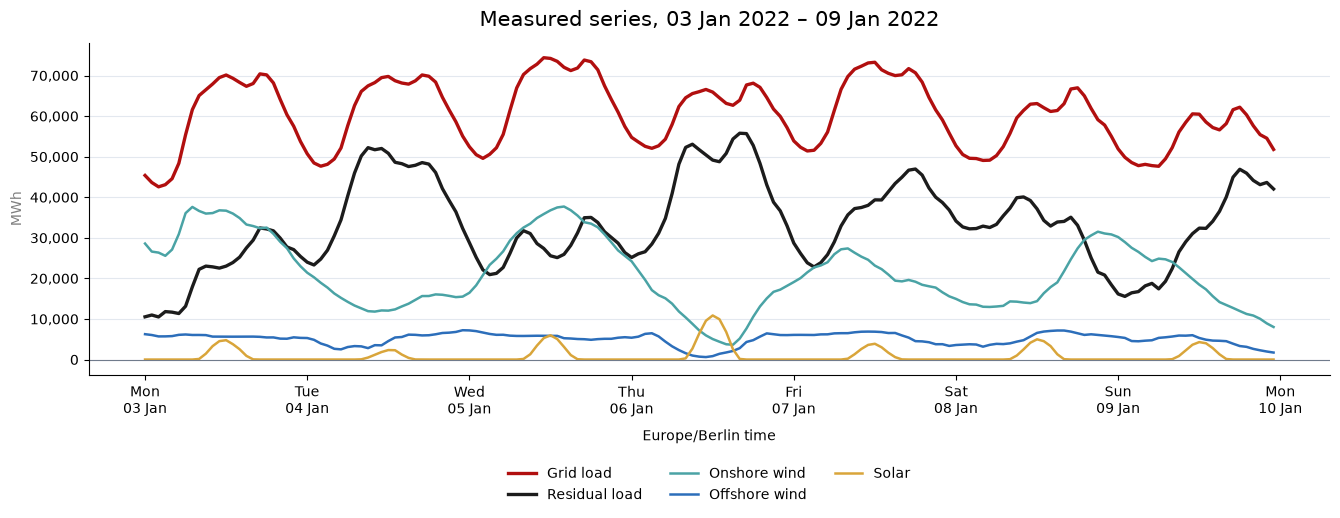

In [13]:
def plot_week(frame, columns, title):
    """One week of hourly values, MWh. Returns the plotted span so §2.4 can compare the two."""
    fig, ax = plt.subplots(figsize=(13.5, 5.5))

    for col in columns:
        ax.plot(frame.index, frame[col].to_numpy(), **series_style(col))

    ax.axhline(0, color=COLORS["muted"], lw=0.8)
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_ylabel("MWh", color="grey")
    ax.set_xlabel("Europe/Berlin time", labelpad=8)
    ax.grid(axis="y", color=COLORS["grid"], lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d %b"))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.24))
    plt.tight_layout()
    plt.show()

    return frame.index[0], frame.index[-1]


PHYSICAL_COLS = ["grid_load", "residual_load", "wind_on", "wind_off", "solar"]
physical_span = plot_week(
    week,
    PHYSICAL_COLS,
    f"Measured series, {week.index[0]:%d %b %Y} – {week.index[-1]:%d %b %Y}",
)

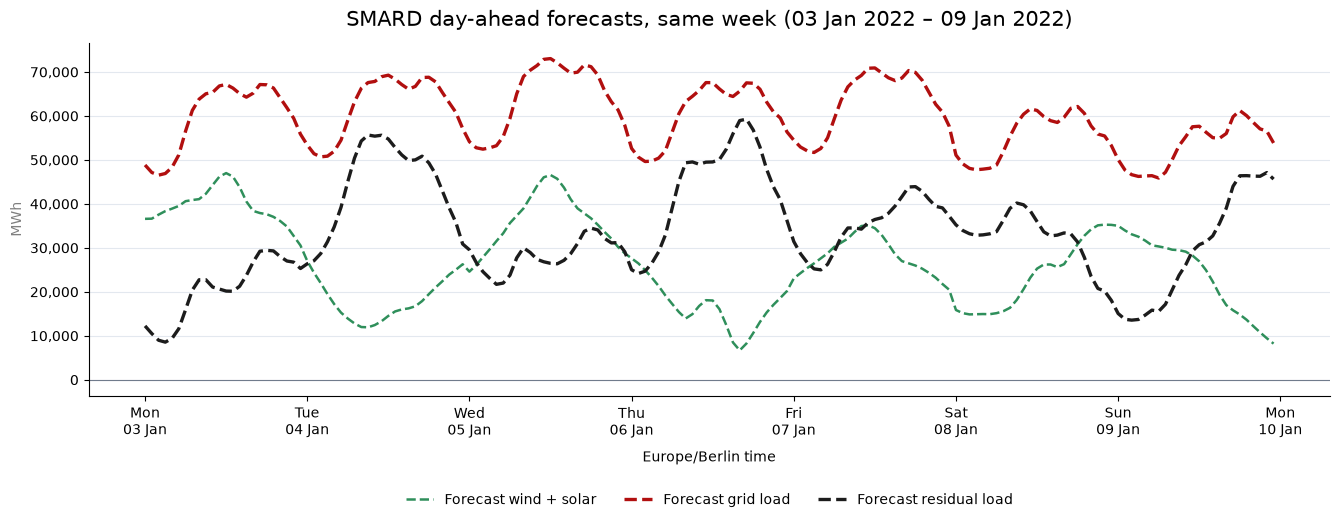

In [14]:
# FORECAST_COLS comes from §1.2 — each forecast keeps its measured counterpart's colour, dashed.
forecast_span = plot_week(
    week,
    FORECAST_COLS,
    f"SMARD day-ahead forecasts, same week ({week.index[0]:%d %b %Y} – {week.index[-1]:%d %b %Y})",
)

**The series behave as they physically should.** `grid_load` repeats a clear daily cycle with a
visibly lower weekend, `solar` returns to zero every night and peaks at midday, wind moves on its
own multi-day rhythm, and `residual_load` tracks `grid_load` minus the wind and solar support —
dipping hardest exactly where wind and solar are strongest. The forecast panel shows the same
shapes: the SMARD day-ahead series are close enough to the measured ones that their errors, not
their shapes, are the interesting quantity — which is why `fc_residual_load` is the benchmark this project
has to beat.

### 2.4 — Self-check

In [15]:
assert len(week) == WEEK_HOURS, len(week)
assert week.index[0].dayofweek == 0 and week.index[0].hour == 0, week.index[0]
assert week.index[-1].dayofweek == 6 and week.index[-1].hour == 23, week.index[-1]
assert (week.index.to_series().diff().dropna() == pd.Timedelta("1h")).all(), "internal gap"
assert week[SERIES].notna().all().all(), "NaN inside the selected week"
assert physical_span == forecast_span, (physical_span, forecast_span)
assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)

print("sanity-check self-check passed")
print(f"  {len(week)} consecutive rows, {week.index[0]:%A %H:%M} -> {week.index[-1]:%A %H:%M}")
print(f"  both plots cover {physical_span[0]:%Y-%m-%d} -> {physical_span[1]:%Y-%m-%d}")
print(f"  no column added to time_series ({len(time_series.columns)} columns)")

sanity-check self-check passed
  168 consecutive rows, Monday 00:00 -> Sunday 23:00
  both plots cover 2022-01-03 -> 2022-01-09
  no column added to time_series (18 columns)


---

## 3 — Univariate and time structure

Eight views, all ported from [`EDA-simple-claude.ipynb`](EDA-simple-claude.ipynb)'s tagged cells:
what each series looks like on its own, and what calendar structure it carries. Nothing here
overlaps with the other three source notebooks, so no merge decisions were needed — only the
`time_series` rename, the shared helpers from §1, and the colour configuration from §1.2.

Six otherwise-central plots from the same source notebook are **absent**, their cells being
untagged: the residual-load identity histogram, the `SERIES` boxplot, the Jan–Sep matched trend
bars, the Pearson correlation heatmap, the residual-vs-renewables scatter and the negative-share
heatmap. That was a discussed cut, not an oversight — restoring any of them means tagging the
source cell and revising
[`03.3`](../../.claude/specs/03.3-univariate-and-time-structure.md).

### 3.1 — Every series over the full record

Weekly and monthly means per series, both via `period_mean`, so the incomplete opening/closing
periods are dropped rather than drawn as fake edge dips. Each panel carries its series' own colour
from §1.2.

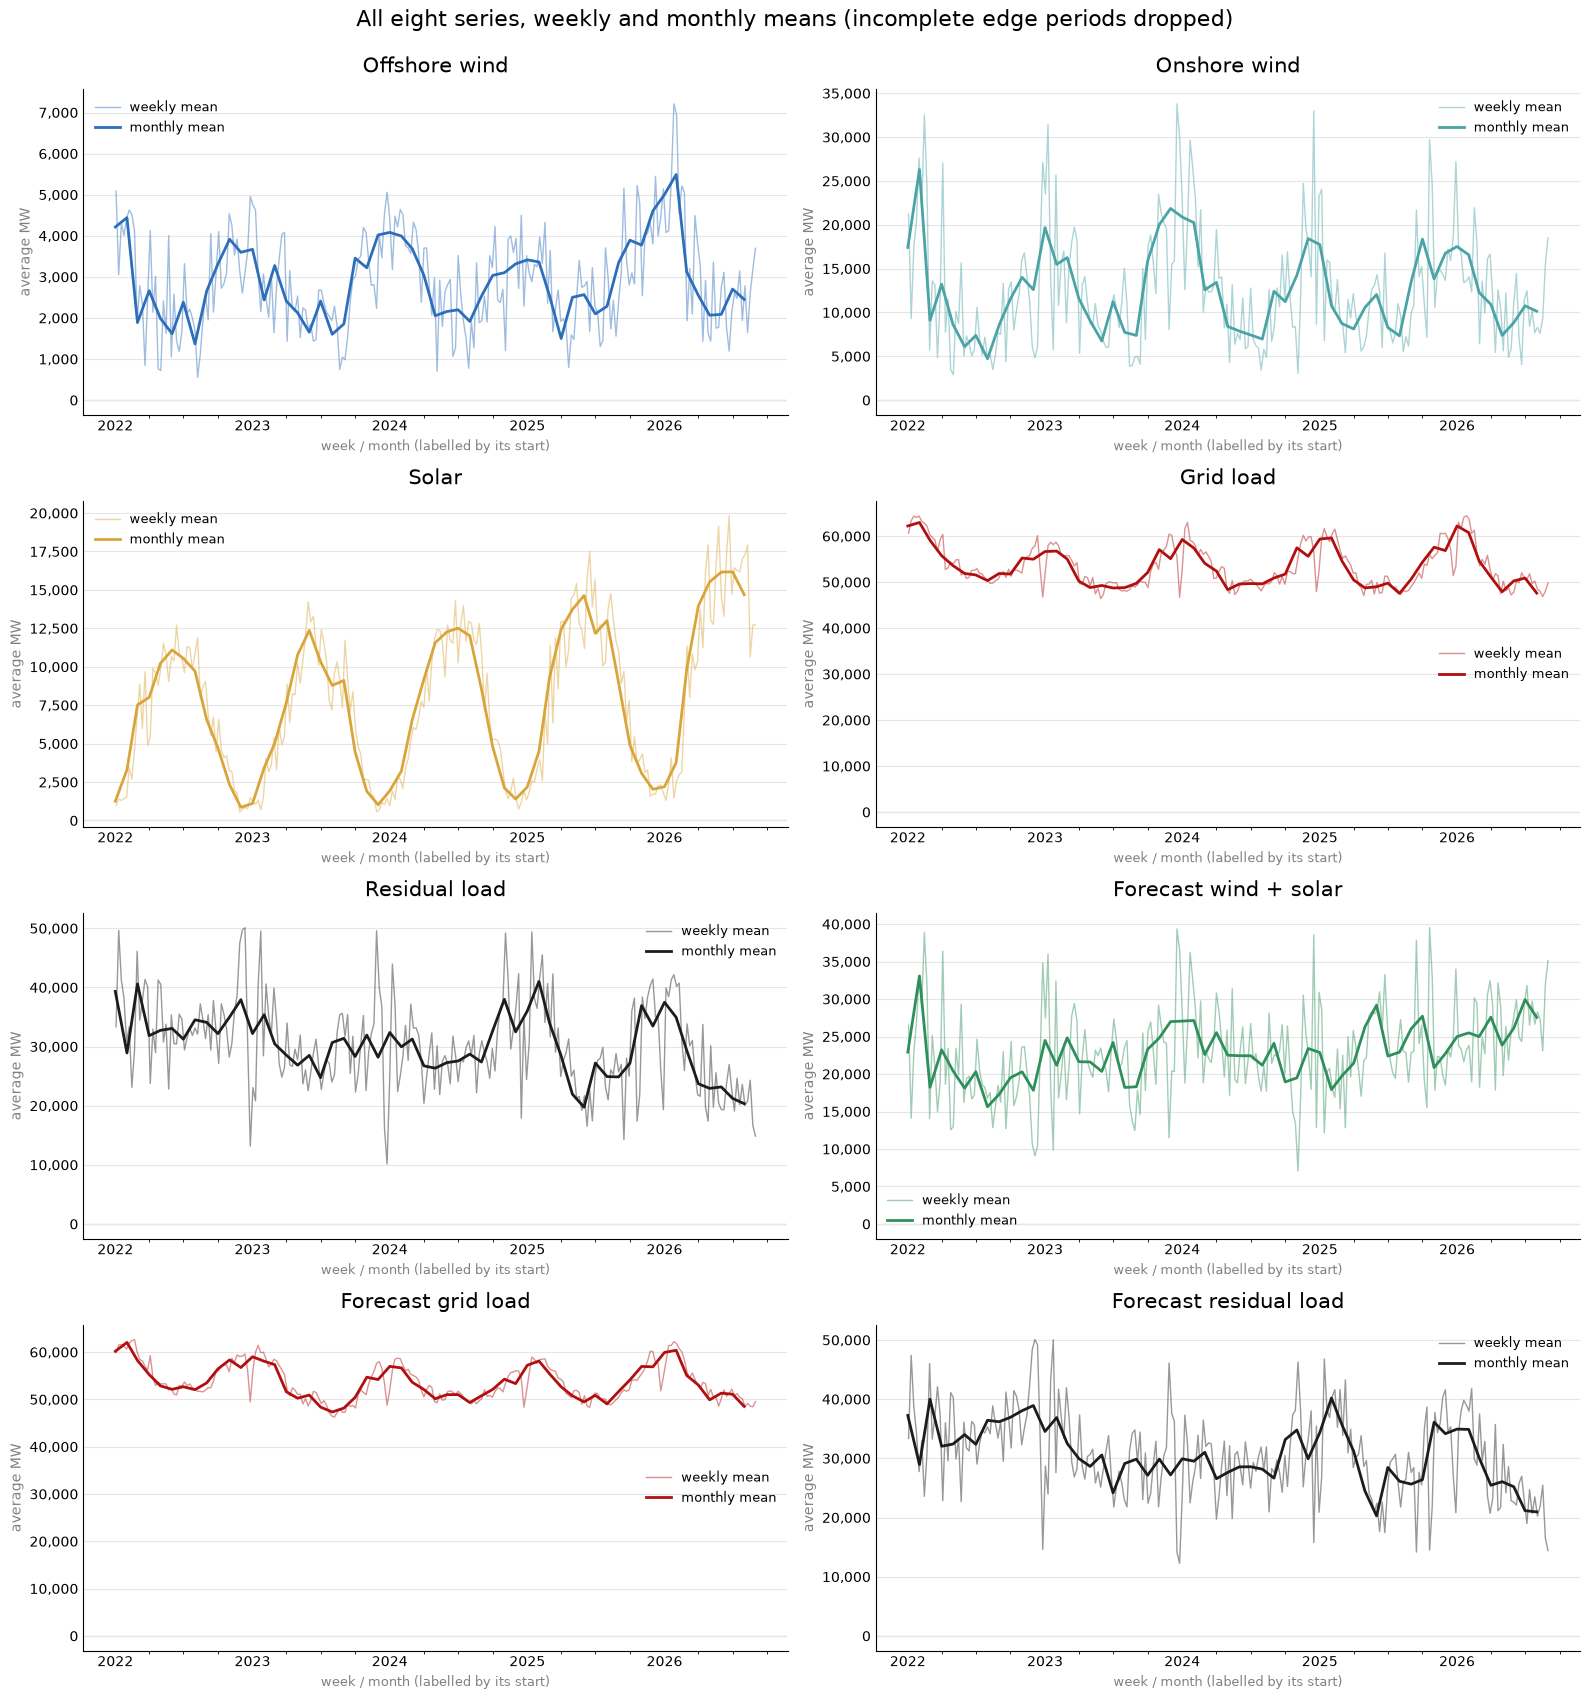

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(16, 17))

for ax, col in zip(axes.flat, SERIES):
    weekly = period_mean(time_series[col], "W")
    monthly = period_mean(time_series[col], "M")
    ax.plot(
        weekly.index, weekly.to_numpy(),
        color=SERIES_COLOR[col], linewidth=1.0, alpha=0.45, label="weekly mean",
    )
    ax.plot(
        monthly.index, monthly.to_numpy(),
        color=SERIES_COLOR[col], linewidth=2.0, label="monthly mean",
    )
    ax.axhline(0, color="0.6", linewidth=0.8, zorder=0)
    style_timeseries(ax, SERIES_LABEL[col], "average MW")
    ax.set_xlabel("week / month (labelled by its start)", color="grey", fontsize=9)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle(
    "All eight series, weekly and monthly means (incomplete edge periods dropped)",
    fontsize=16, y=0.997,
)
plt.tight_layout()
plt.show()

**`solar` is the one series with an unmistakable trend**: its summer peaks grow from roughly
11 GW to over 16 GW across the record. Wind, on- and offshore, shows no comparable climb — it is
dominated by weather variance, and a single windy or still week moves the level further than the
whole record's trend does. `grid_load` drifts gently down and is otherwise remarkably stable.

`residual_load` inherits all of it: a downward drift driven mostly by solar build-out, on top of
the largest short-term variance of any series here. The gap between the thin weekly line and the
thick monthly one is the point of this figure — for the wind and residual panels, monthly means
hide swings that matter for a day-ahead forecast.

### 3.2 — Distribution of each series

Hourly values, so each number is a level reading: over a single hour, `MWh` and `MW` are the same
number, and the axis says `MW` rather than restating it as an energy-per-hour. The red line marks
zero, which only `residual_load` and its forecast ever cross.

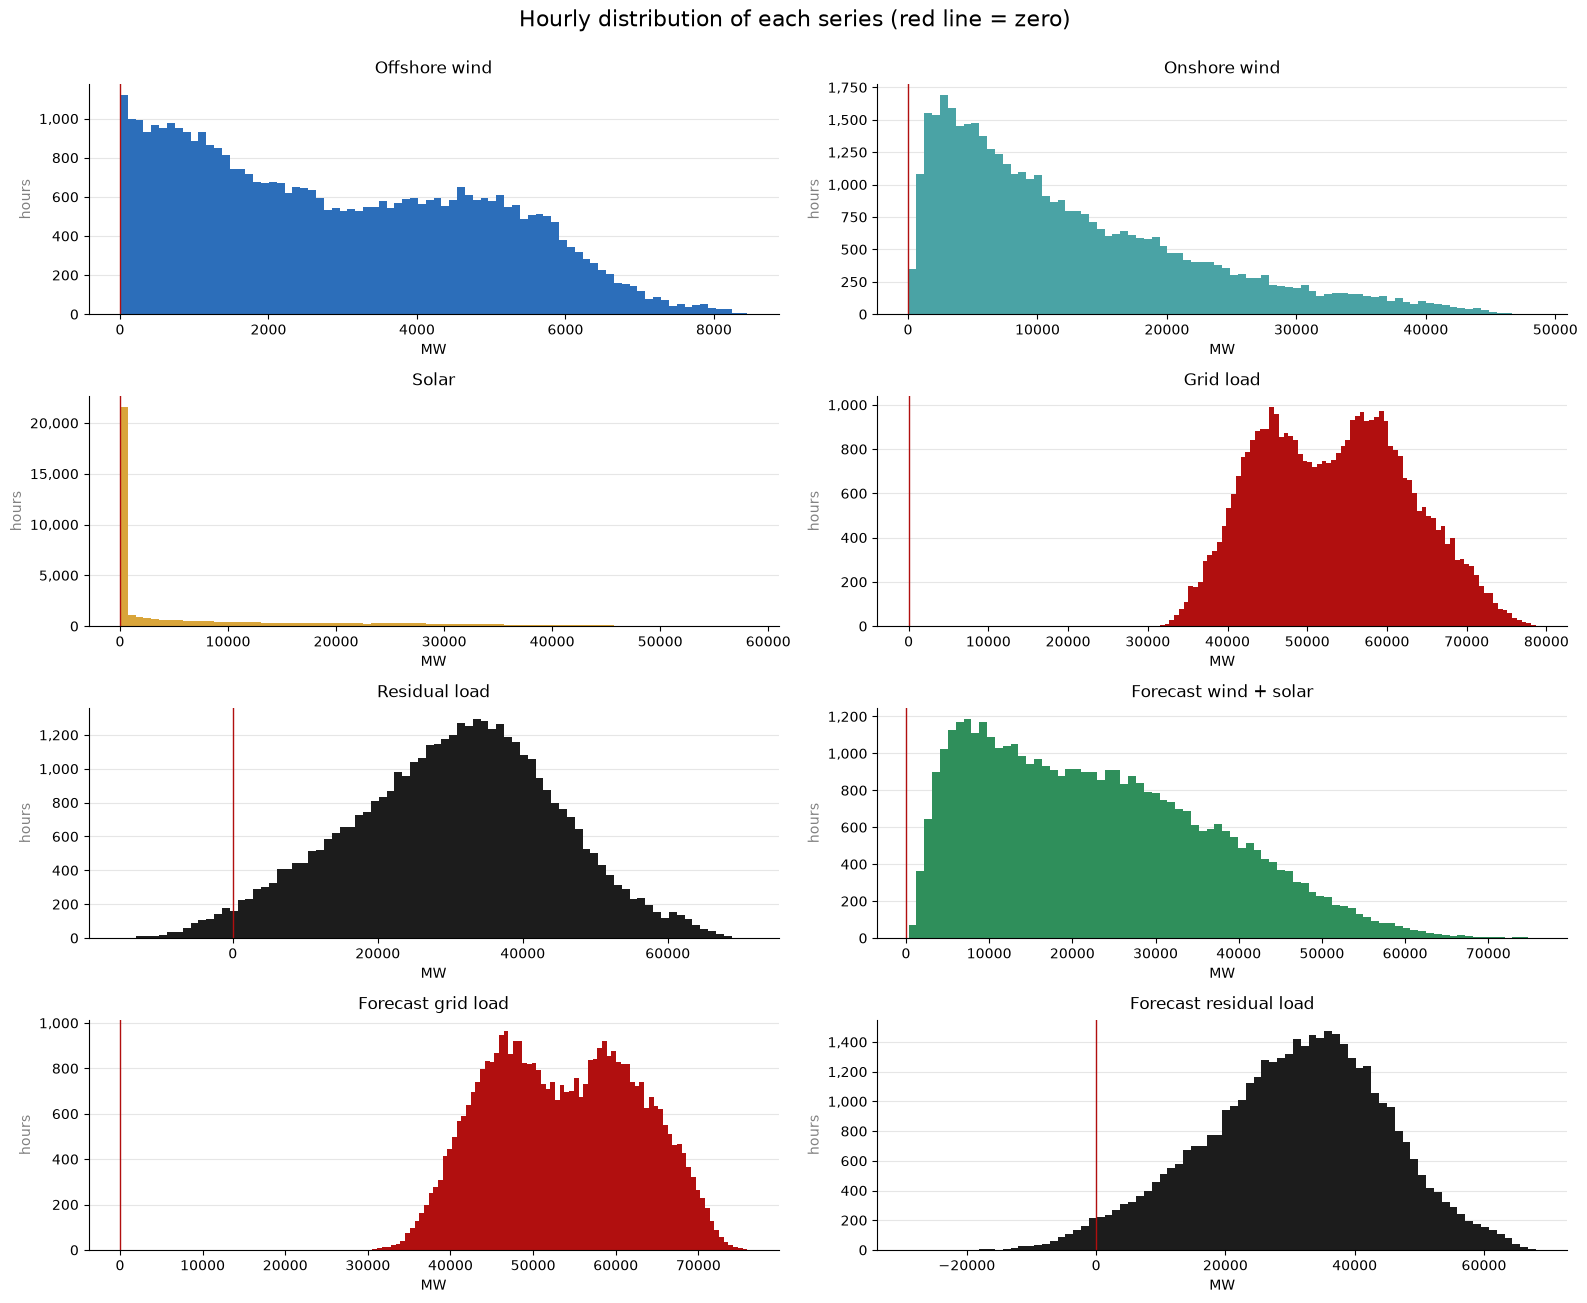

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(16, 13))

for ax, col in zip(axes.flat, SERIES):
    ax.hist(time_series[col], bins=80, color=SERIES_COLOR[col])
    ax.axvline(0, color=COLORS["red"], linewidth=1.0)
    ax.set_title(SERIES_LABEL[col], fontsize=12, pad=8)
    ax.set_xlabel("MW")
    ax.set_ylabel("hours", color="grey")
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")

fig.suptitle("Hourly distribution of each series (red line = zero)", fontsize=16, y=0.999)
plt.tight_layout()
plt.show()

`grid_load` is close to symmetric around a high level; the generation series are strongly
right-skewed with a mass near zero (solar is zero every night by construction); `residual_load` is
the only series with meaningful weight **below zero**, which is the phenomenon this project is
about. Note also that no series is log-transformable: `residual_load` goes negative, and the
generation series sit on zero.

### 3.3 — Annual seasonality

Monthly means, month on the x-axis, one line per year. The last year in the record is partial, so
its line stops early — that is the data ending, not a collapse.

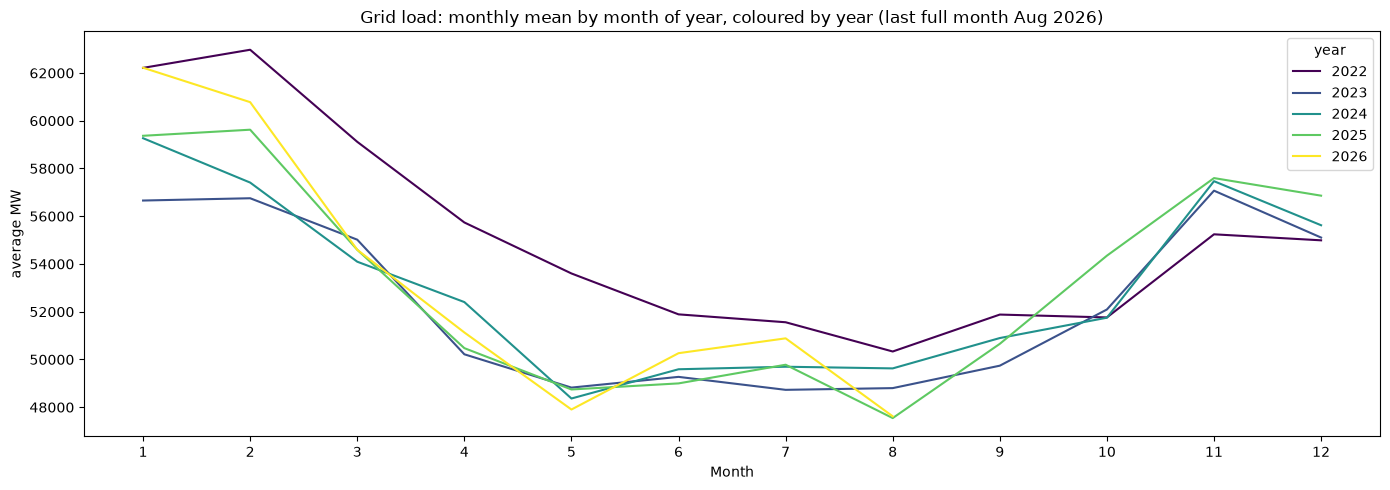

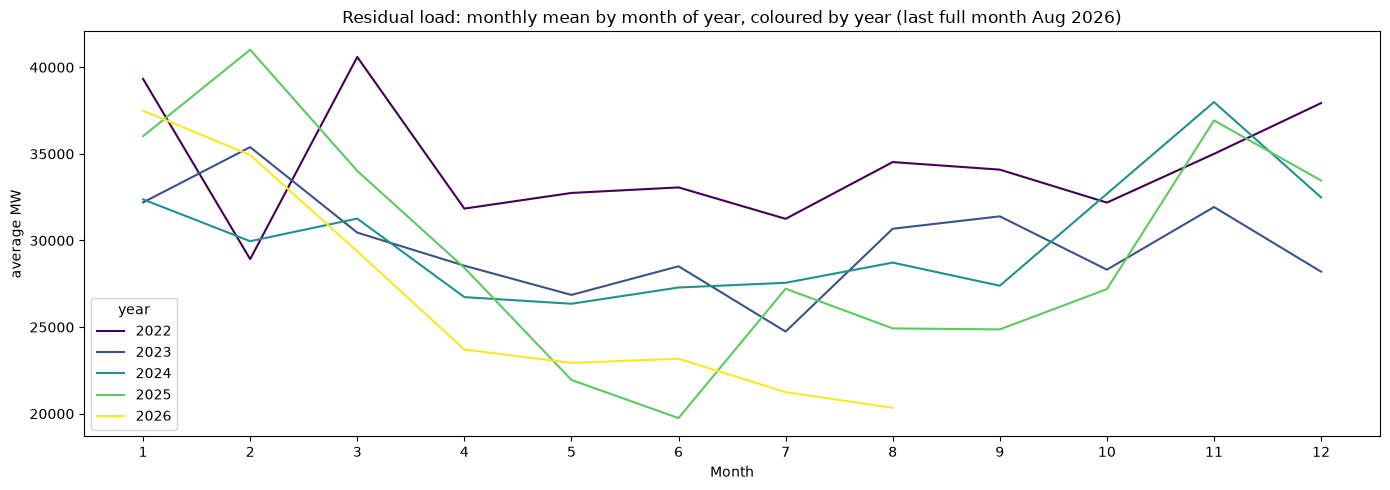

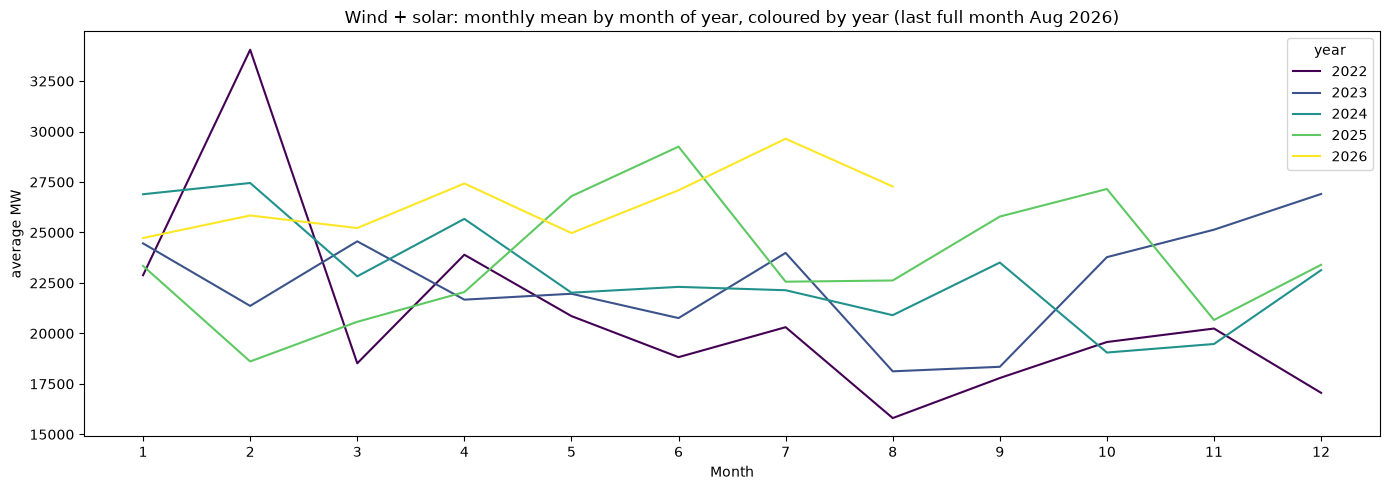

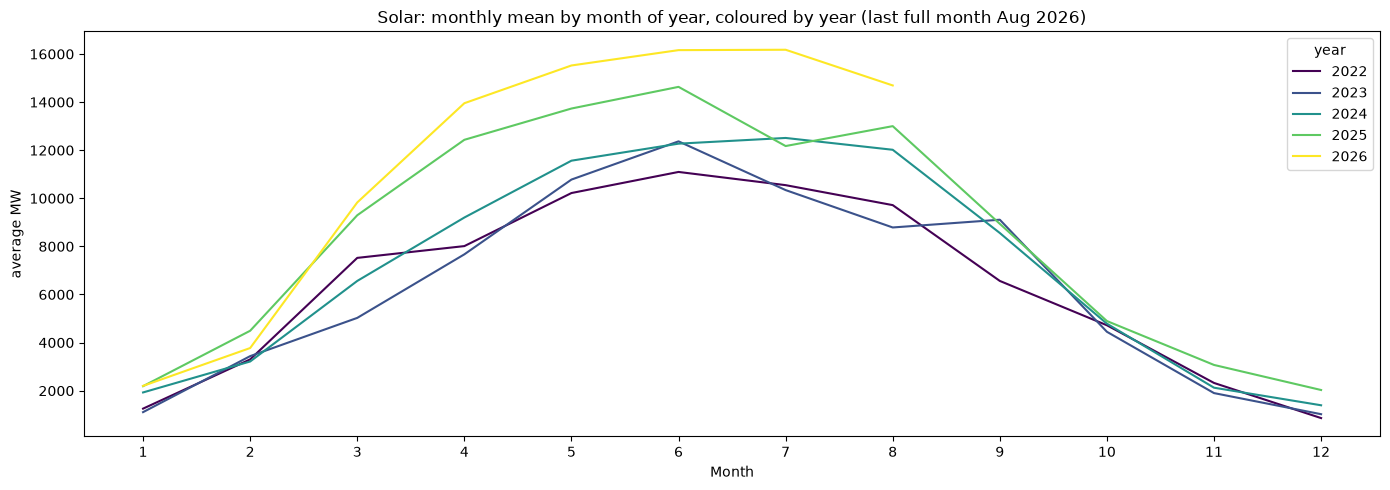

In [18]:
# The record's own end month, so no calendar literal is needed in the title.
last_complete = period_mean(time_series["grid_load"], "M").index.max()

for col in ["grid_load", "residual_load", "renewables", "solar"]:
    monthly = period_mean(time_series[col], "M").to_frame(col)
    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month
    seasonal_plot(
        monthly,
        col,
        f"{SERIES_LABEL[col]}: monthly mean by month of year, coloured by year "
        f"(last full month {last_complete:%b %Y})",
        "average MW",
    )

`grid_load` traces the expected winter-high / summer-low curve, and the year lines sit almost on
top of each other — demand seasonality is stable. `solar` is the mirror image and just as regular.
`renewables` combines a flat-ish wind contribution with the solar hump, and `residual_load`
inherits both: highest in winter, deeply suppressed in the May–August midday season, and shifting
downward year on year as installed renewable capacity grows.

### 3.4 — Weekly rhythm

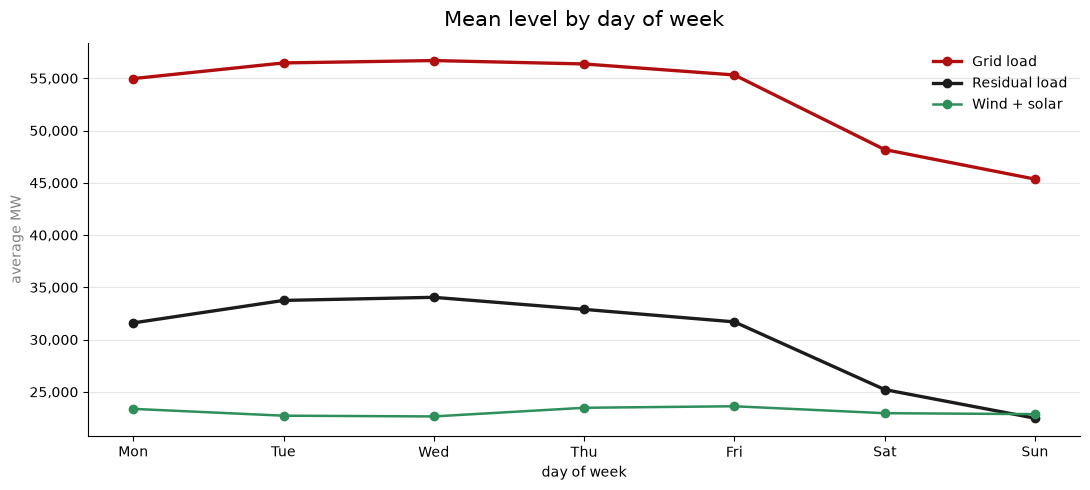

,weekday,weekend,delta_%
grid_load,55966.0,46769.0,-16.0
residual_load,32797.0,23853.0,-27.0
renewables,23169.0,22916.0,-1.0


In [19]:
PROFILE_COLS = ["grid_load", "residual_load", "renewables"]

dow_profile = time_series.groupby("dow")[PROFILE_COLS].mean()
dow_profile.index = DAY_NAMES

fig, ax = plt.subplots(figsize=(11, 5))
for col in PROFILE_COLS:
    ax.plot(dow_profile.index, dow_profile[col].to_numpy(), marker="o", **series_style(col))
ax.set_title("Mean level by day of week", fontsize=15, pad=12)
ax.set_ylabel("average MW", color="grey")
ax.set_xlabel("day of week")
ax.grid(axis="y", color="0.9", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

weekend_contrast = time_series.groupby("is_weekend")[PROFILE_COLS].mean().T
weekend_contrast.columns = ["weekday", "weekend"]
weekend_contrast["delta_%"] = (
    100 * (weekend_contrast["weekend"] / weekend_contrast["weekday"] - 1)
).round(1)
display(weekend_contrast.round(0))

Monday to Friday form a flat plateau, Saturday drops and Sunday drops further — the classic demand
week. `renewables` is essentially flat across the week, as it must be: the weather does not know
what day it is. Because demand falls and supply does not, the weekend cut in `residual_load` is
**larger in percentage terms** than the one in `grid_load` — the weekly cycle is a residual-load
effect amplified by an unchanged renewable infeed.

### 3.5 — Daily rhythm, per season and day type

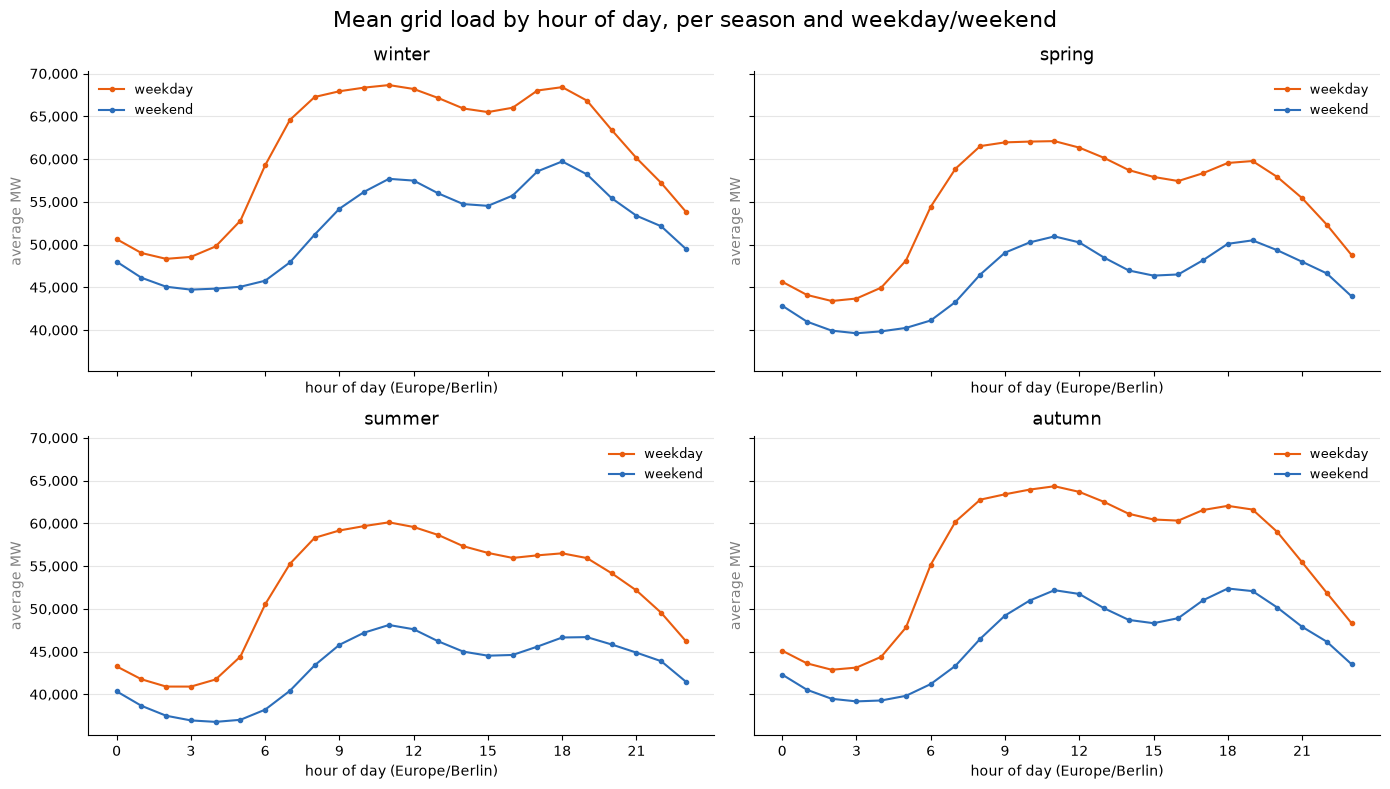

In [20]:
hour_profile = time_series.groupby(["season", "is_weekend", "hour"], observed=True)["grid_load"].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True, sharex=True)

for ax, season in zip(axes.flat, SEASON_ORDER):
    for weekend, label in [(False, "weekday"), (True, "weekend")]:
        profile = hour_profile.loc[(season, weekend)]
        ax.plot(
            profile.index, profile.to_numpy(),
            marker="o", markersize=3, color=DAY_TYPE_COLOR[label], label=label,
        )
    ax.set_title(season, fontsize=13, pad=8)
    ax.set_xlabel("hour of day (Europe/Berlin)")
    ax.set_ylabel("average MW", color="grey")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Mean grid load by hour of day, per season and weekday/weekend", fontsize=16)
plt.tight_layout()
plt.show()

The daily shape is the same everywhere — overnight trough, steep 05:00–08:00 ramp, working-day
plateau, evening fall — but its **profile through the middle of the day changes with the season**.
In winter the weekday curve holds a broad plateau from 09:00 to 12:00 and then returns to a second
peak at 18:00 that is just as high, as darkness and heating meet the tail of the working day. In
summer that second peak is much weaker and the midday hours sag: the 12:00–16:00 stretch falls
below the morning maximum, because behind-the-meter solar serves load that therefore never appears
as grid load at all. Spring sits between the two; autumn resembles winter with a smaller
amplitude.

The weekday/weekend gap is a near-constant vertical offset in every season, with the **same
shape**: weekends keep the morning ramp and evening peak, simply lower and starting later. That is
a useful modelling fact — the weekend effect is close to multiplicative on the level rather than a
different daily shape.

### 3.6 — Federal holidays

German **federal** holidays only — `holidays.country_holidays("DE")` with no `subdiv`, the
project's single holiday source of truth. Grid load is a national quantity, and state-specific
holidays would make the comparison depend on which Bundesland happened to be picked. Each holiday
is compared against non-holiday days of the **same weekday** within ±14 days.

In [21]:
holiday_years = range(min(YEARS), max(YEARS) + 1)  # from YEARS, never a literal
de_holidays = holidays.country_holidays("DE", years=holiday_years)  # no subdiv -> federal only
holiday_dates = set(de_holidays)  # set(), not the dict: Series.isin on a dict subclass is no contract

daily_load = time_series.groupby("date")[["grid_load", "residual_load"]].mean()
daily_load.index = pd.DatetimeIndex(daily_load.index)
daily_load["dow"] = daily_load.index.dayofweek
daily_load["is_holiday"] = pd.Series(daily_load.index.date, index=daily_load.index).isin(holiday_dates)

# State-only holidays would mean the call picked up a subdiv default; both spellings checked.
STATE_ONLY = {
    "Fronleichnam", "Allerheiligen", "Reformationstag", "Mariä Himmelfahrt",
    "Heilige Drei Könige", "Friedensfest", "Buß- und Bettag", "Weltkindertag",
    "Corpus Christi", "All Saints' Day", "Reformation Day", "Assumption Day",
    "Epiphany", "Peace Festival", "Repentance and Prayer Day", "World Children's Day",
}
holiday_names = {name for name in de_holidays.values()}
assert not (holiday_names & STATE_ONLY), sorted(holiday_names & STATE_ONLY)

print(
    f"{len(de_holidays)} federal holidays across {min(YEARS)}-{max(YEARS)}, "
    f"{int(daily_load['is_holiday'].sum())} of them inside the record"
)
print(f"distinct holiday names ({len(holiday_names)}): {sorted(holiday_names)}")

45 federal holidays across 2022-2026, 42 of them inside the record
distinct holiday names (9): ['Ascension Day', 'Christmas Day', 'Easter Monday', 'German Unity Day', 'Good Friday', 'Labor Day', "New Year's Day", 'Pentecost Monday', 'Second Day of Christmas']


In [22]:
rows = []
for day in daily_load.index[daily_load["is_holiday"]]:
    window = daily_load.loc[day - pd.Timedelta("14D"): day + pd.Timedelta("14D")]
    reference = window[(~window["is_holiday"]) & (window["dow"] == daily_load.at[day, "dow"])]
    if reference.empty:
        continue
    rows.append(
        {
            "holiday": de_holidays.get(day.date()),
            "date": day.date(),
            "weekday": day.day_name(),
            "load": daily_load.at[day, "grid_load"],
            "reference": reference["grid_load"].mean(),
            "delta_%": 100 * (daily_load.at[day, "grid_load"] / reference["grid_load"].mean() - 1),
        }
    )

holiday_effect = pd.DataFrame(rows)

by_name = (
    holiday_effect.groupby("holiday")
    .agg(n=("delta_%", "size"), mean_delta_pct=("delta_%", "mean"))
    .sort_values("mean_delta_pct")
    .round(1)
)
display(by_name)

,n,mean_delta_pct
holiday,,
Christmas Day,4,-23.7
Second Day of Christmas,4,-23.3
New Year's Day,5,-23.2
Easter Monday,5,-23.1
Pentecost Monday,5,-22.7
Ascension Day,5,-19.2
Labor Day,5,-19.0
German Unity Day,4,-18.2
Good Friday,5,-16.9


**Every federal holiday depresses grid load** against comparable same-weekday days in the
surrounding four weeks, and the striking thing is how narrow the range is: no holiday behaves
qualitatively differently from the others. A holiday is worth roughly a fifth of a day's load,
whichever holiday it is — which makes a single "is holiday" feature a reasonable modelling
simplification rather than a lossy one.

That the list contains no Fronleichnam, Allerheiligen or Reformationstag is the check that the
no-`subdiv` call really did return federal holidays only; the assertion above fails loudly if a
state-level holiday ever appears.

**One caveat on method.** For the Christmas holidays the ±14-day reference window sits partly
inside the depressed Christmas period itself, so those deltas **understate** the true effect. The
numbers above are a lower bound for Christmas Day and Boxing Day, not a measurement of the full
holiday-season dip.

### 3.7 — Where the residual-load tails sit on the calendar

The extreme 1 % of hours at each end, selected **by rank**: this is a descriptive slice, not a
risk definition, and no flag column is written back onto `time_series`. Colours come from §1.2's
tail pair: blue for the low (oversupply) end, red for the high (tight-margin) end.

411 hours in each tail (1 % of the record by rank)
  low  tail spans    -15,562 ..     -3,503 MW
  high tail spans     61,693 ..     70,964 MW


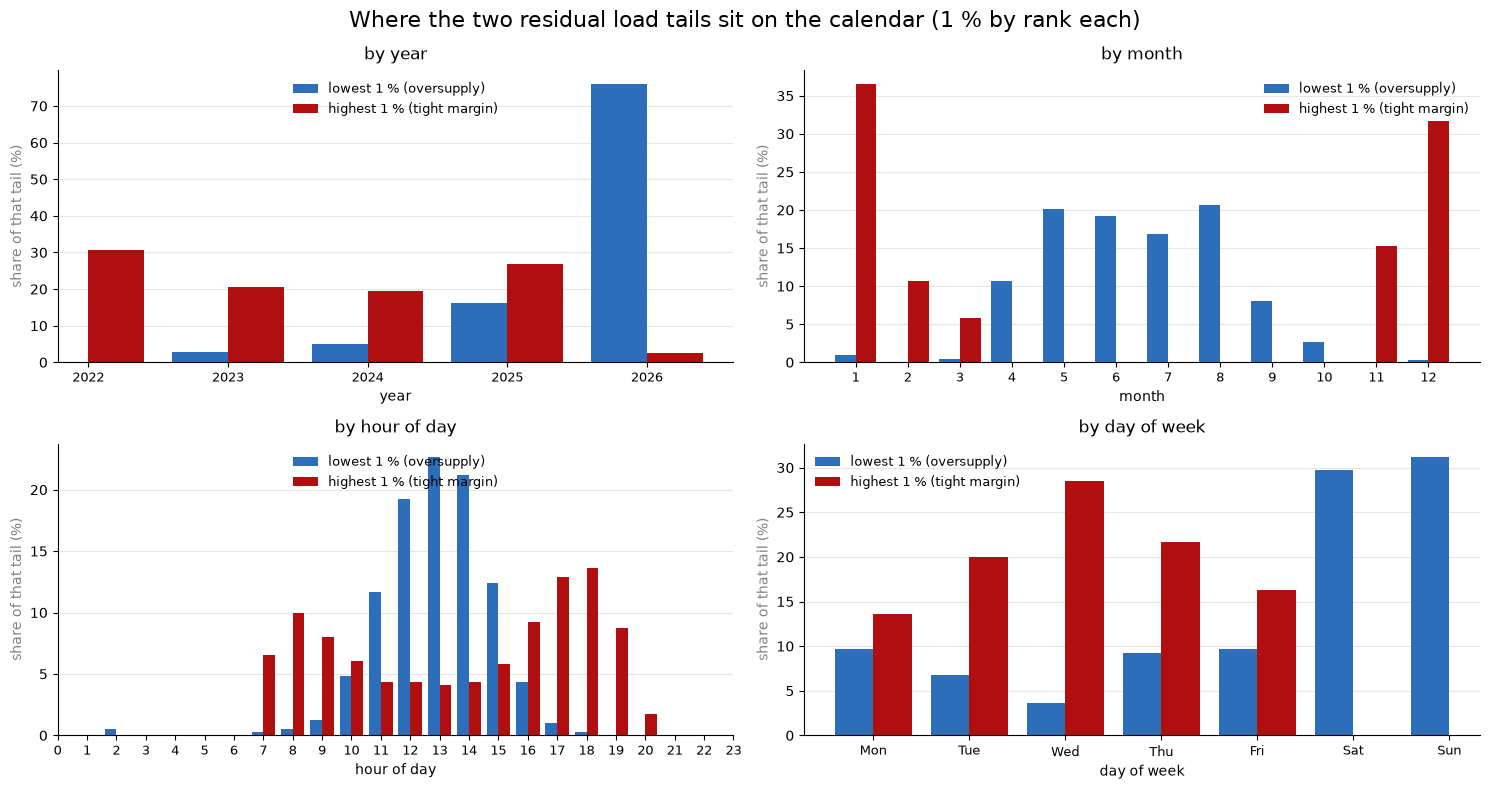

In [23]:
n_tail = round(0.01 * len(time_series))
low_tail = time_series["residual_load"].nsmallest(n_tail)   # descriptive slice, never persisted
high_tail = time_series["residual_load"].nlargest(n_tail)

print(f"{n_tail:,} hours in each tail (1 % of the record by rank)")
print(f"  low  tail spans {low_tail.min():>10,.0f} .. {low_tail.max():>10,.0f} MW")
print(f"  high tail spans {high_tail.min():>10,.0f} .. {high_tail.max():>10,.0f} MW")

DIMENSIONS = [
    ("year", lambda idx: idx.year, None),
    ("month", lambda idx: idx.month, range(1, 13)),
    ("hour of day", lambda idx: idx.hour, range(24)),
    ("day of week", lambda idx: idx.dayofweek, range(7)),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for ax, (label, extract, full_range) in zip(axes.flat, DIMENSIONS):
    frame = pd.DataFrame(
        {
            "lowest 1 % (oversupply)": pd.Series(extract(low_tail.index)).value_counts(normalize=True),
            "highest 1 % (tight margin)": pd.Series(extract(high_tail.index)).value_counts(normalize=True),
        }
    )
    if full_range is not None:
        frame = frame.reindex(list(full_range))
    frame = frame.sort_index() * 100

    x = np.arange(len(frame))
    ax.bar(x - 0.2, frame.iloc[:, 0].to_numpy(), width=0.4, label=frame.columns[0],
           color=TAIL_COLOR["low"])
    ax.bar(x + 0.2, frame.iloc[:, 1].to_numpy(), width=0.4, label=frame.columns[1],
           color=TAIL_COLOR["high"])
    ax.set_xticks(x)
    ax.set_xticklabels(
        DAY_NAMES if label == "day of week" else [str(v) for v in frame.index], fontsize=9
    )
    ax.set_title(f"by {label}", fontsize=12, pad=8)
    ax.set_ylabel("share of that tail (%)", color="grey")
    ax.set_xlabel(label)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle(
    "Where the two residual load tails sit on the calendar (1 % by rank each)", fontsize=16
)
plt.tight_layout()
plt.show()

The two tails have **almost mirror-image calendar signatures**, which is the most useful thing in
this section.

**The low tail (oversupply)** is overwhelmingly recent, concentrated in the high-solar months,
in the midday hours, and at weekends — the weekly demand minimum of §3.4 lining up with the daily
solar maximum of §3.5. **The high tail (tight margins) is the mirror image**: weekday-only, spread
far more evenly across years rather than trending, sitting in the winter months and peaking at the
evening hours with a secondary morning cluster.

That contrast is worth dwelling on. The low tail is **growing and seasonal**; the high tail is
**stable and structural**. One is a new phenomenon created by renewable build-out, the other the
classic winter stress case that has always been there. For the modelling spec this is a strong
hint that **the two risk cases may not be one problem** — they run on different mechanisms, in
opposite seasons and at opposite hours. Whether to treat them as one target or two is a modelling
decision; this notebook only records that the evidence points toward two.

### 3.8 — Two representative extreme episodes

Selected by a **stated, reproducible, rank-based rule** rather than by eye:

1. **The longest run of consecutive negative `residual_load` hours.** Ties broken by earliest
   start — which matters, because the runners-up are only an hour shorter.
2. **The highest 24-hour rolling mean.** The window is time-based (`rolling("24h")`), not
   row-based, so the DST gaps cannot let a "24-row" window span 25 wall-clock hours.
   `min_periods=24` stops a partial window at the start of the record from winning.

The selection code below carries no tag of its own; it is ported because the tagged plot after it
cannot run without it.

In [24]:
negative = time_series["residual_load"] < 0

# --- rule 1: longest consecutive negative run, ties broken by earliest start
blocks = (negative != negative.shift()).cumsum()
runs = (
    pd.DataFrame(
        {
            "length": negative.groupby(blocks).size(),
            "is_negative": negative.groupby(blocks).first(),
            "start": time_series.index.to_series().groupby(blocks).min(),
        }
    )
    .query("is_negative")
    .sort_values(["length", "start"], ascending=[False, True])
)
print("longest negative runs (top 5), showing the tie the rule has to break:")
display(runs.head(5)[["start", "length"]].reset_index(drop=True))

run_start = runs.iloc[0]["start"]
run_end = run_start + pd.Timedelta(hours=int(runs.iloc[0]["length"]) - 1)

# --- rule 2: highest 24-hour rolling mean, on a TIME-based window
rolling_24h = time_series["residual_load"].rolling("24h", min_periods=24).mean()
peak_end = rolling_24h.idxmax()
peak_start = peak_end - pd.Timedelta("23h")
print(f"\nhighest 24 h rolling mean: {rolling_24h.max():,.0f} MW over {peak_start} .. {peak_end}")

longest negative runs (top 5), showing the tie the rule has to break:


,start,length
0,2026-08-30 05:00:00,12
1,2026-06-13 08:00:00,11
2,2026-06-14 08:00:00,11
3,2025-10-26 04:00:00,10
4,2026-01-01 06:00:00,9



highest 24 h rolling mean: 61,086 MW over 2022-01-10 06:00:00 .. 2022-01-11 05:00:00


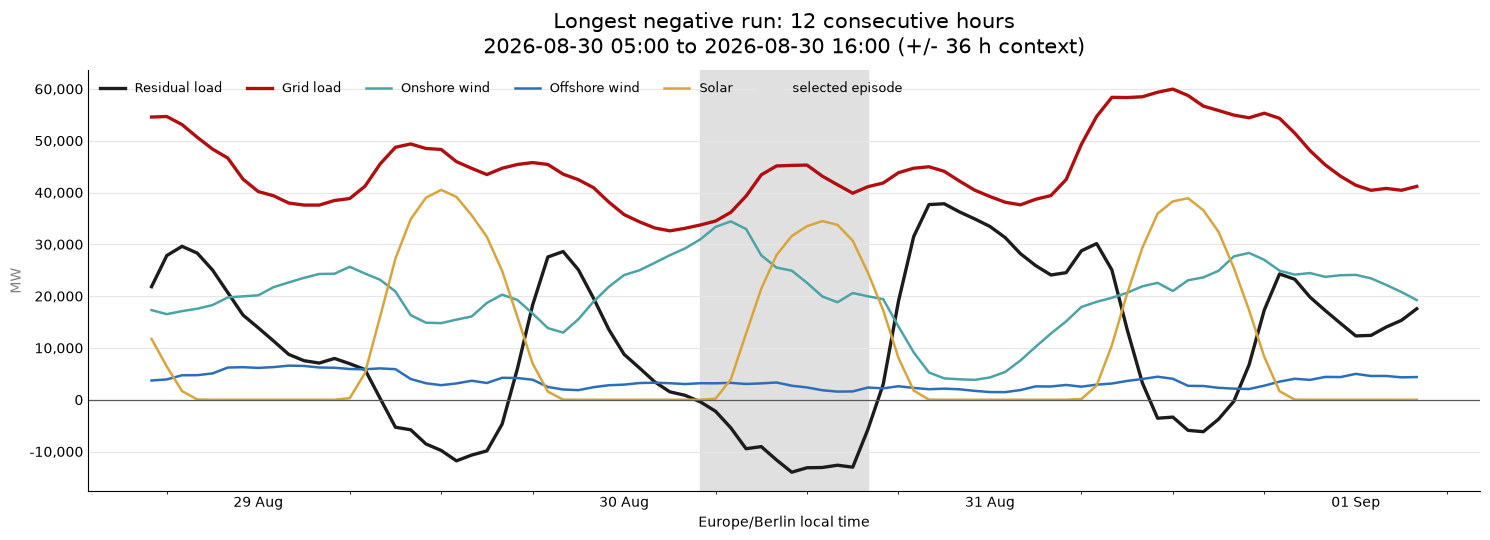

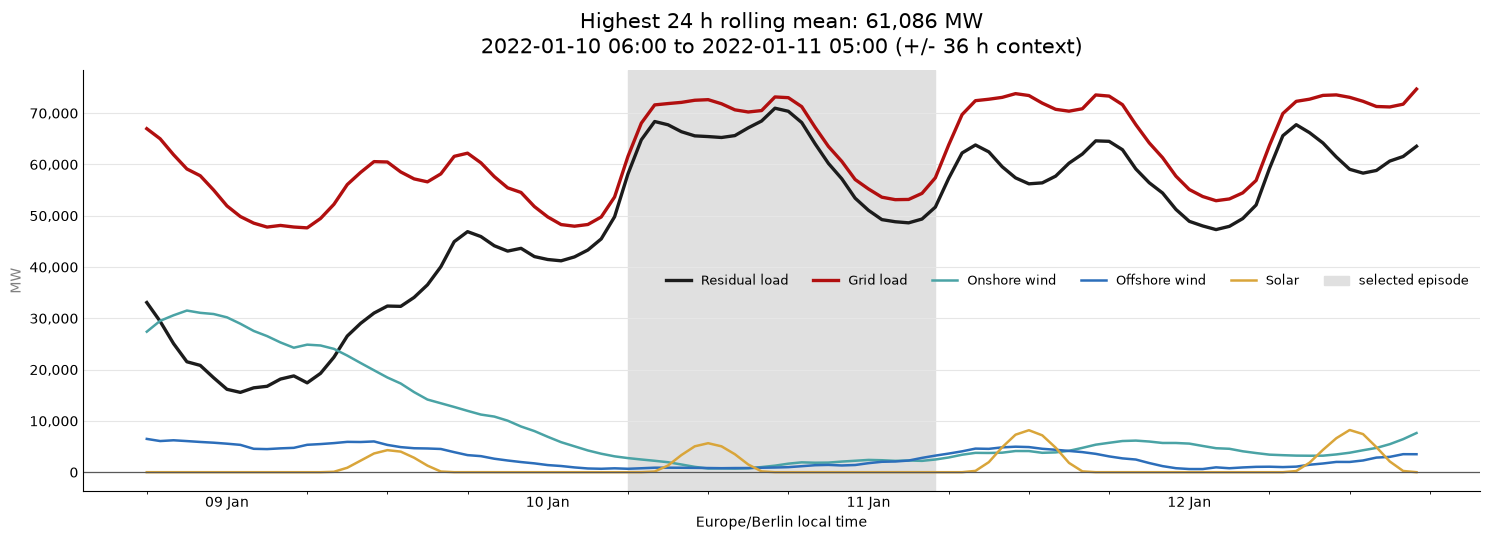

In [25]:
EPISODE_COLS = ["residual_load", "grid_load", "wind_on", "wind_off", "solar"]
episodes = [
    (f"Longest negative run: {int(runs.iloc[0]['length'])} consecutive hours", run_start, run_end),
    (f"Highest 24 h rolling mean: {rolling_24h.max():,.0f} MW", peak_start, peak_end),
]

for title, start, end in episodes:
    window = time_series.loc[start - pd.Timedelta("36h"): end + pd.Timedelta("36h"), EPISODE_COLS]

    fig, ax = plt.subplots(figsize=(15, 5.5))
    for col in EPISODE_COLS:
        ax.plot(window.index, window[col].to_numpy(), **series_style(col))
    ax.axhline(0, color="0.35", linewidth=0.9)
    ax.axvspan(start, end, color="0.88", zorder=0, label="selected episode")

    style_timeseries(
        ax,
        f"{title}\n{start:%Y-%m-%d %H:%M} to {end:%Y-%m-%d %H:%M} (+/- 36 h context)",
        "MW",
    )
    # style_timeseries assumes a multi-year axis; a few-day window needs day ticks.
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=(0, 6, 12, 18)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.set_xlabel("Europe/Berlin local time")
    ax.legend(frameon=False, ncol=6, fontsize=9)
    plt.tight_layout()
    plt.show()

The two episodes show the two mechanisms in their pure form, and their **time scales are very
different**. The longest negative run is only twelve hours: a single late-summer day where solar
peaks above 30 GW against a weekend-level demand, pushing `residual_load` to roughly −14 GW around
midday before it recovers overnight. The ±36 h context shows the neighbouring days dipping below
zero as well — the oversupply case is a *recurring midday* phenomenon, not a multi-day state.

The high 24-hour mean is the opposite: a full winter day where wind has collapsed to near zero and
solar contributes almost nothing, so `residual_load` tracks `grid_load` almost exactly at a level
above 60 GW for a whole day — a *Dunkelflaute*-shaped episode where conventional generation and
imports carry essentially the entire load. Oversupply arrives in hours; tight margins arrive in
days.

### 3.9 — Self-check

In [26]:
assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)
assert not (holiday_names & STATE_ONLY), "state-only holiday in the federal list"
assert len(low_tail) == len(high_tail) == n_tail
assert low_tail.max() < high_tail.min(), "the two tails overlap"
assert run_end > run_start and peak_end > peak_start

print("univariate/time-structure self-check passed")
print(f"  {len(holiday_names)} distinct federal holidays, none state-only")
print(f"  {n_tail:,} hours per tail, ranges disjoint")
print(f"  no column added to time_series ({len(time_series.columns)} columns)")

univariate/time-structure self-check passed
  9 distinct federal holidays, none state-only
  411 hours per tail, ranges disjoint
  no column added to time_series (18 columns)


---

## 4 — Two-series comparison views

Four plots from [`EDA-magc.ipynb`](EDA-magc.ipynb) and [`EDA-robert.ipynb`](EDA-robert.ipynb) that
put two series on **one axis**, each kept because it answers "how do these two move together"
rather than repeating §3's per-series views.

Two tagged charts from `EDA-magc.ipynb` are deliberately **not** here — her weekly-mean and
monthly-mean `grid_load` + `residual_load` overlays (cells 15 and 17). §3.1 already shows both
series at both resolutions, so those two would be a third telling of the same thing. That was the
team's decision, recorded in [`03.4`](../../.claude/specs/03.4-two-series-comparison-views.md).

Every aggregate in this section goes through `period_mean`, never `.resample()`, so the partial
opening and closing periods are dropped the same way as everywhere else in the notebook.

### 4.1 — Daily means, load against residual load

Daily resolution appears nowhere in §3, which reaches only weekly and monthly. It is the
resolution at which the weekly cycle is still visible but the hourly shape is gone.

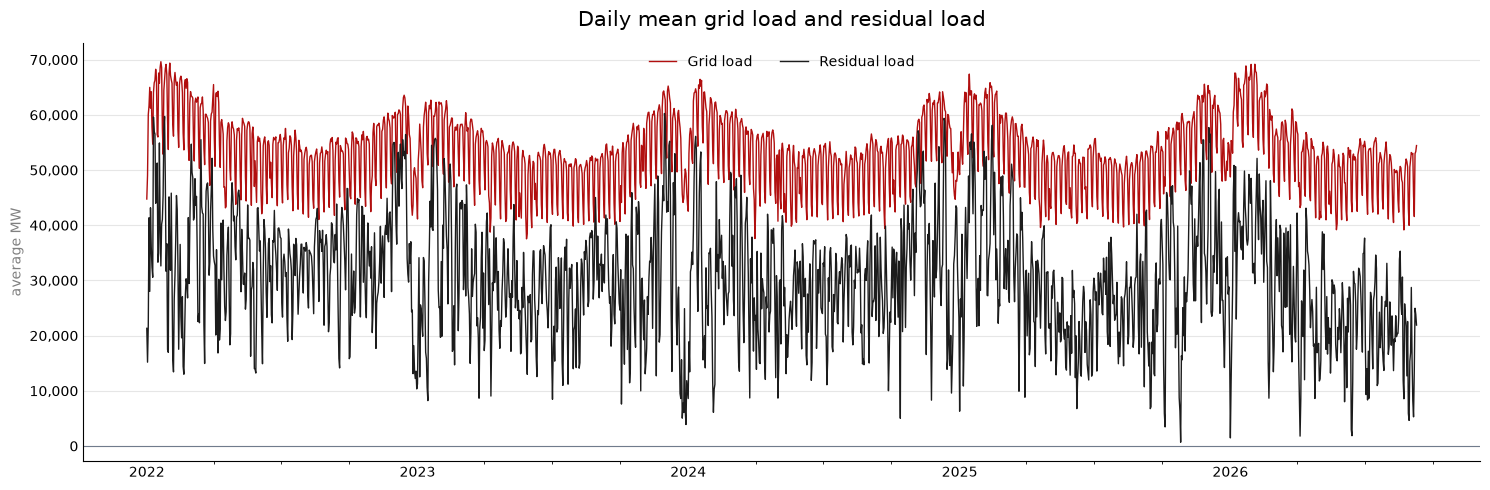

daily means: 1,713 days, 2022-01-01 .. 2026-09-09

day-to-day spread (std of daily means, average MW) — widest and narrowest month:
  grid_load      max   6,267 (month 12)   min   4,382 (month  8)
  residual_load  max  14,900 (month 12)   min   7,648 (month  7)

lowest summer daily mean residual load, per year (average MW):
timestamp
2022    14899.0
2023     8461.0
2024    11090.0
2025     6764.0
2026     1860.0


In [27]:
COMPARE_COLS = ["grid_load", "residual_load"]
daily_means = {col: period_mean(time_series[col], "D") for col in COMPARE_COLS}

fig, ax = plt.subplots(figsize=(15, 5))
for col in COMPARE_COLS:
    ax.plot(daily_means[col].index, daily_means[col].to_numpy(), **series_style(col, linewidth=1.0))

ax.axhline(0, color=COLORS["muted"], linewidth=0.8)
style_timeseries(ax, "Daily mean grid load and residual load", "average MW")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

print(
    f"daily means: {len(daily_means['grid_load']):,} days, "
    f"{daily_means['grid_load'].index.min():%Y-%m-%d} .. {daily_means['grid_load'].index.max():%Y-%m-%d}"
)

daily_frame = pd.DataFrame(daily_means)
spread = daily_frame.groupby(daily_frame.index.month).std().round(0)
print("\nday-to-day spread (std of daily means, average MW) — widest and narrowest month:")
for col in COMPARE_COLS:
    print(
        f"  {col:<14} max {spread[col].max():>7,.0f} (month {spread[col].idxmax():>2})"
        f"   min {spread[col].min():>7,.0f} (month {spread[col].idxmin():>2})"
    )

summer = daily_frame[daily_frame.index.month.isin([6, 7, 8])]
print("\nlowest summer daily mean residual load, per year (average MW):")
print(summer.groupby(summer.index.year)["residual_load"].min().round(0).to_string())

The two series share the same winter-high / summer-low seasonality, but they behave completely
differently **day to day**. `grid_load` is a tidy band: its daily means scatter by roughly 4–6 GW
within a month, and the band keeps its width and position across the whole record. `residual_load`
scatters two to three times as much, and — the part worth noting — **its scatter is widest in
winter**, not in summer, because that is when wind swings hardest.

The second feature is the downward drift of the summer floor. The lowest summer daily mean falls
from around 15 GW in the first year of the record to under 2 GW in the last: whole days are
approaching zero net residual demand. `grid_load` shows nothing comparable. Whatever is getting
harder to forecast here, it is not demand.

### 4.2 — Grid load: hourly noise against its own aggregates

Kept alongside §3.1's `grid_load` panel rather than in place of it: that one shows the trend, this
one shows how far the hourly data sits from it. The grey band is every hourly value in the record.

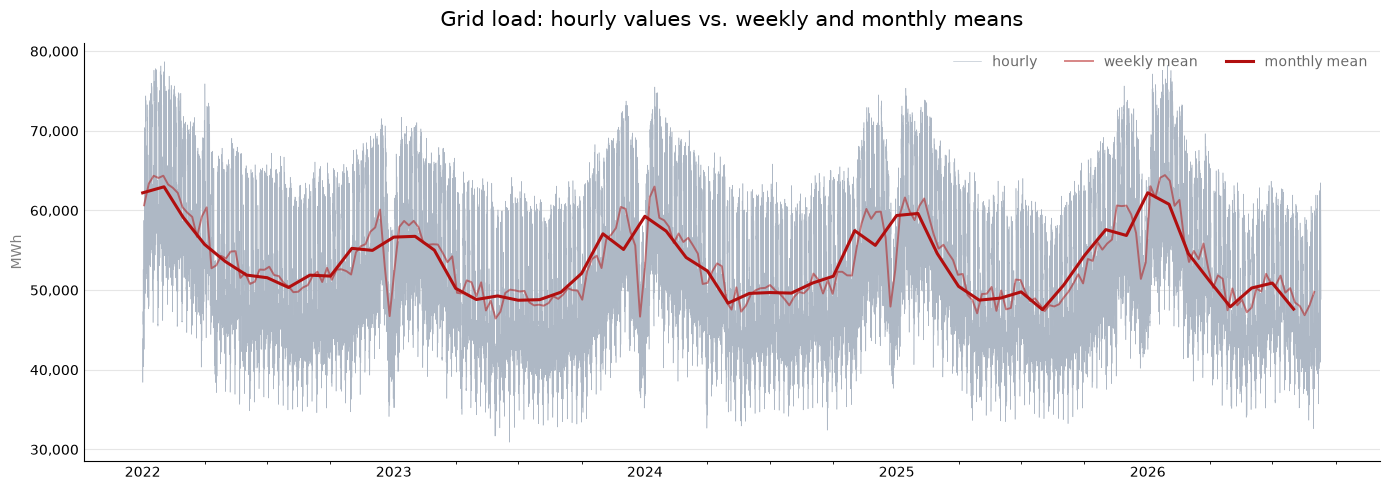

hourly range  : 47,778 MWh
monthly range : 15,428 MWh  (32% of it)


In [28]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    time_series.index, time_series["grid_load"].to_numpy(),
    color=COLORS["gray"], linewidth=0.4, label="hourly",
)
weekly_grid_load = period_mean(time_series["grid_load"], "W")
monthly_grid_load = period_mean(time_series["grid_load"], "M")
ax.plot(
    weekly_grid_load.index, weekly_grid_load.to_numpy(),
    color=SERIES_COLOR["grid_load"], linewidth=1.4, alpha=0.5, label="weekly mean",
)
ax.plot(
    monthly_grid_load.index, monthly_grid_load.to_numpy(),
    color=SERIES_COLOR["grid_load"], linewidth=2.2, label="monthly mean",
)

style_timeseries(ax, "Grid load: hourly values vs. weekly and monthly means", "MWh")
ax.legend(frameon=False, loc="upper right", ncols=3, labelcolor="dimgrey")
plt.tight_layout()
plt.show()

hourly_spread = time_series["grid_load"].max() - time_series["grid_load"].min()
monthly_spread = monthly_grid_load.max() - monthly_grid_load.min()
print(f"hourly range  : {hourly_spread:,.0f} MWh")
print(f"monthly range : {monthly_spread:,.0f} MWh  ({monthly_spread / hourly_spread:.0%} of it)")

The hourly band is several times wider than anything the aggregates show: the monthly mean moves
across a range that is a fraction of the hourly one. Almost all of that hourly width is the daily
and weekly cycle of §3.4–§3.5, which the aggregates average away by construction. For a day-ahead
model this is the whole problem in one picture — the level is easy and nearly stationary, the
within-week shape is where the variance lives.

### 4.3 — Seasonal levels side by side

,grid_load,residual_load
season,,
winter,58524.0,34264.0
spring,52323.0,29064.0
summer,49635.0,26871.0
autumn,53308.0,31312.0


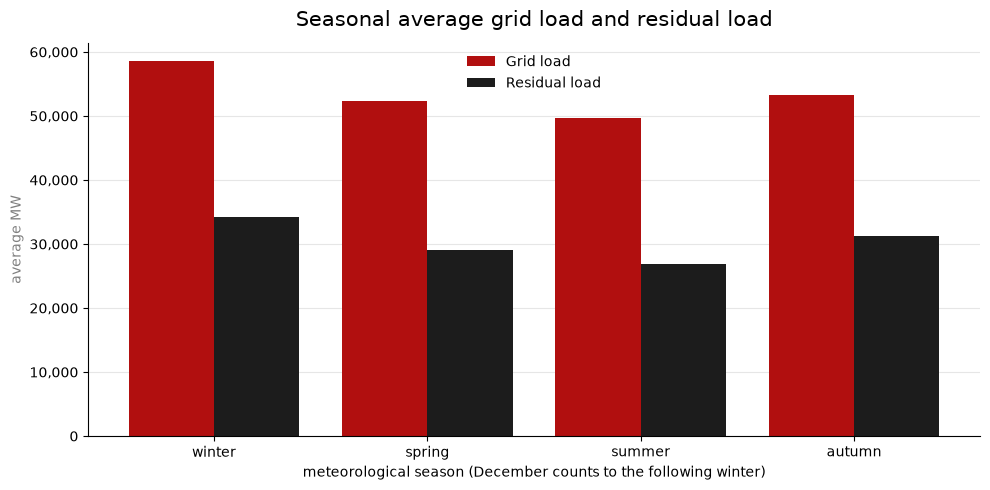

wind + solar contribution implied by the gap (average MW):
season
winter    24260.0
spring    23259.0
summer    22764.0
autumn    21995.0
  spread across seasons: 2,265 MW (10% of the mean)

same gap by calendar month (average MW):
month
1     24461.0
2     25477.0
3     22341.0
4     24143.0
5     23321.0
6     23646.0
7     23727.0
8     20947.0
9     22189.0
10    22390.0
11    21380.0
12    22624.0


In [29]:
seasonal_levels = (
    time_series.groupby("season", observed=True)[COMPARE_COLS].mean().reindex(SEASON_ORDER)
)
display(seasonal_levels.round(0))

x = np.arange(len(SEASON_ORDER))
fig, ax = plt.subplots(figsize=(10, 5))
for offset, col in zip((-0.2, 0.2), COMPARE_COLS):
    ax.bar(
        x + offset, seasonal_levels[col].to_numpy(), width=0.4,
        color=SERIES_COLOR[col], label=SERIES_LABEL[col],
    )

ax.set_xticks(x)
ax.set_xticklabels(SEASON_ORDER)
ax.set_title("Seasonal average grid load and residual load", fontsize=15, pad=12)
ax.set_xlabel("meteorological season (December counts to the following winter)")
ax.set_ylabel("average MW", color="grey")
ax.grid(axis="y", color="0.9", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

gap = (seasonal_levels["grid_load"] - seasonal_levels["residual_load"]).round(0)
print("wind + solar contribution implied by the gap (average MW):")
print(gap.to_string())
print(f"  spread across seasons: {gap.max() - gap.min():,.0f} MW "
      f"({(gap.max() - gap.min()) / gap.mean():.0%} of the mean)")

monthly_gap = (
    time_series.groupby("month")["grid_load"].mean() - time_series.groupby("month")["residual_load"].mean()
).round(0)
print("\nsame gap by calendar month (average MW):")
print(monthly_gap.to_string())

A plain level comparison, and a different question from §3.3's year-over-year seasonal curves.
Both series are highest in winter and lowest in summer, and the surprise is in the printed gap —
the wind + solar contribution implied by the two bars. **It is nearly flat across the seasons**,
around 22–24 GW in every one of them, varying by about a tenth of its own size. Wind's winter
strength very nearly substitutes for solar's summer strength at the level of a seasonal mean.

So the seasonal contrast in `residual_load` is, at the mean, mostly *demand* seasonality passed
straight through — not a season of heavy renewable displacement. The renewables show up elsewhere:
in the shape of the day (§3.5's summer midday sag), in the extremes (§3.7's midday-summer
oversupply tail), and in the year-on-year drift (§4.1) — not in this average. A model that only
learned the seasonal mean would see almost none of what makes residual load hard.

### 4.4 — Solar against total wind

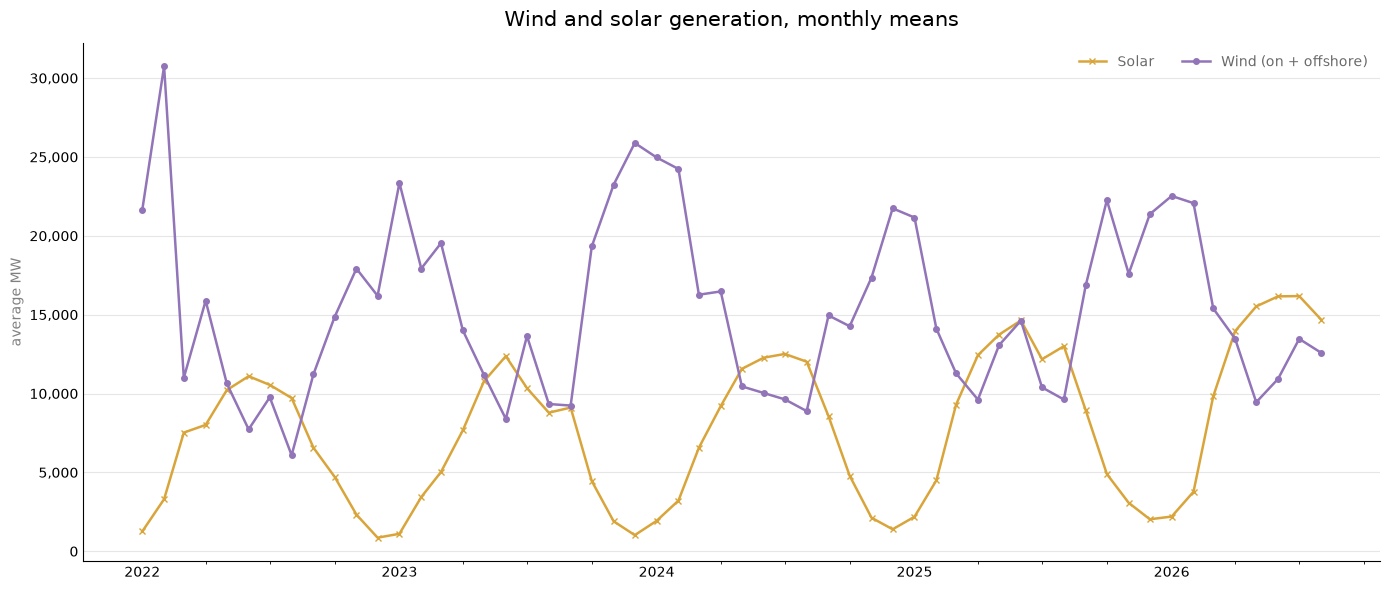

correlation of the two monthly series: -0.77
months where solar exceeds wind: 18 of 56


In [30]:
# wind_total is derived at plot time and never persisted onto time_series (§7 asserts this).
wind_total = time_series["wind_on"] + time_series["wind_off"]

monthly_solar = period_mean(time_series["solar"], "M")
monthly_wind = period_mean(wind_total, "M")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    monthly_solar.index, monthly_solar.to_numpy(),
    color=SERIES_COLOR["solar"], linewidth=1.8, marker="x", markersize=4,
    label=SERIES_LABEL["solar"],
)
ax.plot(
    monthly_wind.index, monthly_wind.to_numpy(),
    color=SERIES_COLOR["wind_total"], linewidth=1.8, marker="o", markersize=4,
    label=SERIES_LABEL["wind_total"],
)

style_timeseries(ax, "Wind and solar generation, monthly means", "average MW")
ax.legend(frameon=False, loc="upper right", ncols=2, labelcolor="dimgrey")
plt.tight_layout()
plt.show()

overlap = pd.DataFrame({"solar": monthly_solar, "wind_total": monthly_wind})
print(f"correlation of the two monthly series: {overlap.corr().iloc[0, 1]:+.2f}")
print(f"months where solar exceeds wind: {int((overlap['solar'] > overlap['wind_total']).sum())} "
      f"of {len(overlap)}")

**The two renewables are seasonally opposed**, and this is the mechanism behind §4.3's flat gap.
Solar peaks in June–July and nearly vanishes in December; wind does the reverse. Their monthly
means are strongly negatively correlated, and solar exceeds wind in fewer than a third of the
months — the summer ones. Added together they cancel to something remarkably steady from month to
month.

That cancellation is a property of the **monthly mean only**, and reading it as stability would be
a mistake. Wind arrives in multi-day bursts and lulls while solar arrives on a fixed daily
schedule, so the same monthly average can be a calm month or a wild one — which is exactly what
§4.1's winter scatter shows. For feature engineering this argues for keeping wind and solar
**separate** rather than modelling a single renewables aggregate: opposite seasonal signs,
different daily shapes (§3.5), different variance structure, and summing them first throws all
three away.

### 4.5 — Self-check

In [31]:
assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)
assert "wind_total" not in time_series.columns, "wind_total must stay local to its cell"
assert len(daily_means["grid_load"]) == len(daily_means["residual_load"])
assert list(seasonal_levels.index) == SEASON_ORDER, list(seasonal_levels.index)
assert len(monthly_solar) == len(monthly_wind) == len(monthly_grid_load)

print("two-series comparison self-check passed")
print(f"  {len(daily_means['grid_load']):,} complete days, {len(monthly_solar)} complete months")
print(f"  wind_total local only; time_series still {len(time_series.columns)} columns")

two-series comparison self-check passed
  1,713 complete days, 56 complete months
  wind_total local only; time_series still 18 columns


---

## 5 — Calendar structure and single events

Six plots from [`EDA-hari.ipynb`](EDA-hari.ipynb), rebuilt against `time_series`. Everything in
that notebook was in GW and carried hardcoded year lists; here every value is in the project's
MW and every year comes from `YEARS`.

The first figure **merges three**: hari's month/weekday/season × hour heatmaps of `residual_load`
(his cell 29) gain a `grid_load` row, and [`EDA-magc.ipynb`](EDA-magc.ipynb)'s two separate
hour × weekday heatmaps (cells 22 and 24) are superseded by it rather than ported alongside.
Hari's ramp-magnitude heatmap by season × hour is not here: §6's ramp views already cover ramp
behaviour, which is why the team excluded it.

### 5.1 — Calendar context, both series

Two rows, two colour scales — and that is not a styling choice. The two series sit on different
levels and mean different things, so one shared colour bar would make one of the rows unreadable.
`grid_load` is strictly positive and takes a sequential ramp towards its own red. `residual_load`
is coloured by §1.2's `residual_scale`, which keeps **zero white** in every case: a diverging
scale centred on zero when the surface crosses it, otherwise the relevant half of that same scale
starting at zero. Averaged over a whole record, these calendar cells stay positive — hours that go
negative are individual hours, not whole calendar cells — so the row below uses the one-sided
half, with white for "close to zero" and black for the highest residual demand.

residual_load grid spans 10,532 .. 46,537 MW — one-sided scale


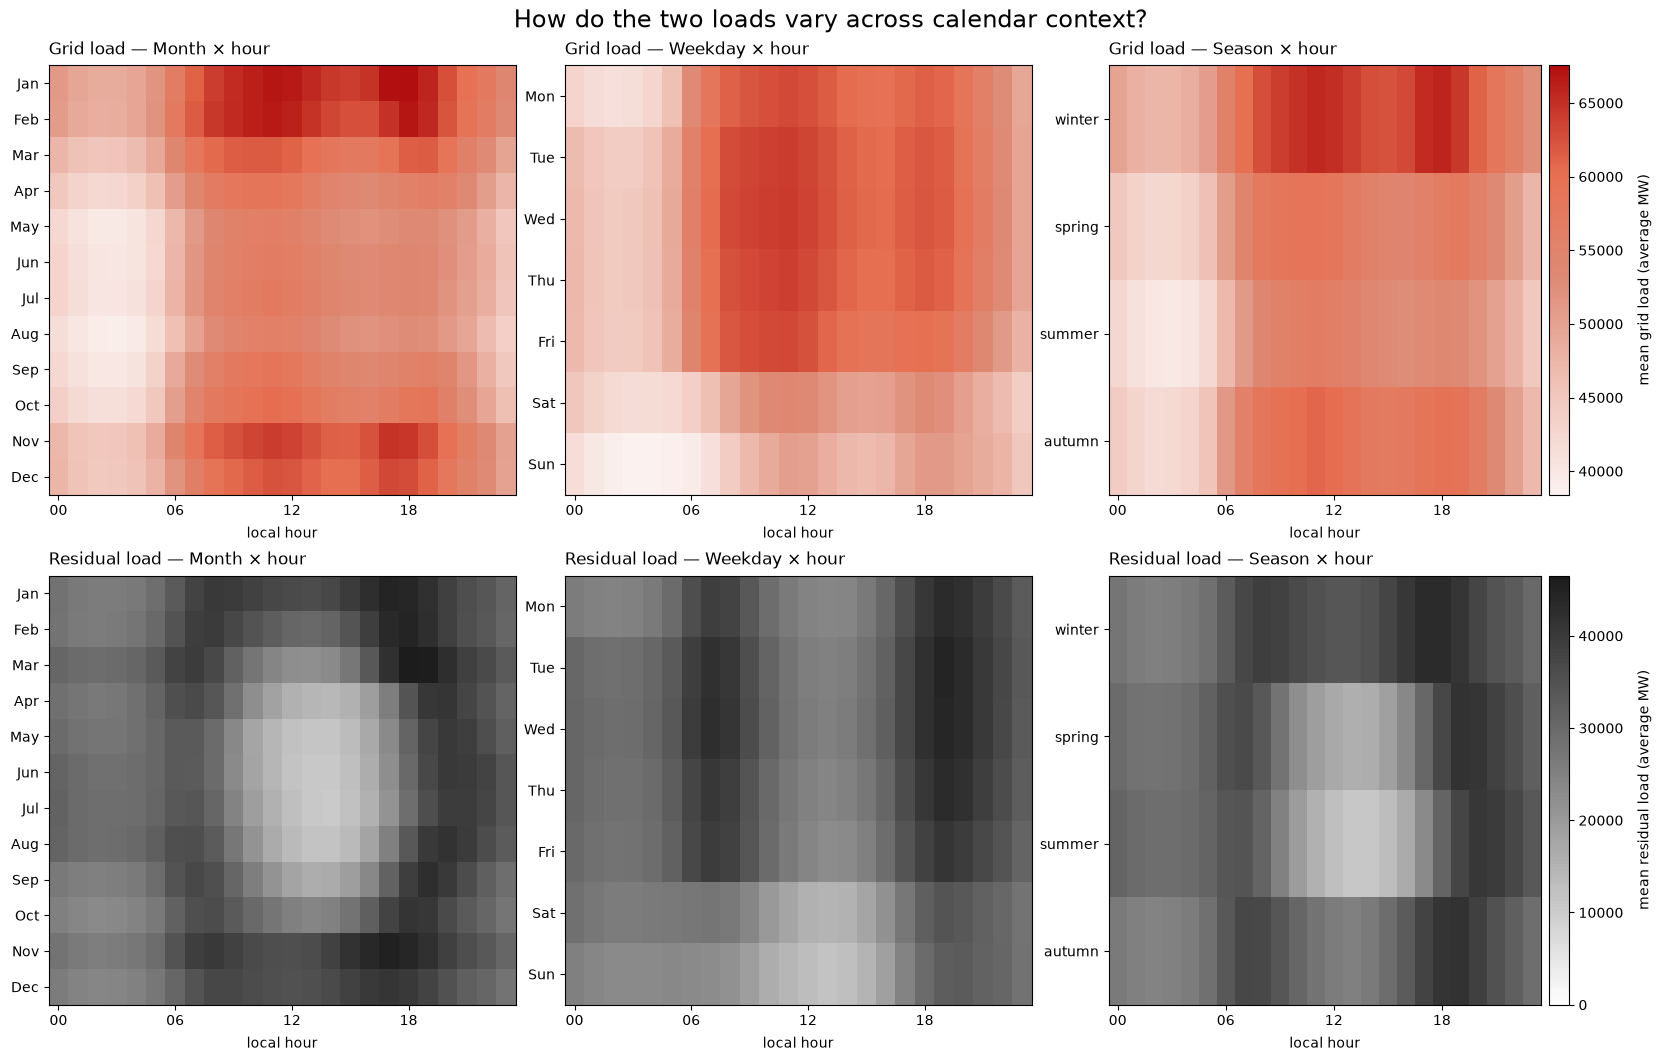

In [32]:
import calendar

MONTH_NAMES = list(calendar.month_abbr)[1:]  # "Jan" .. "Dec", no calendar literal needed

HEATMAP_DIMENSIONS = [
    ("month", MONTH_NAMES, range(1, 13), "Month × hour"),
    ("dow", DAY_NAMES, range(7), "Weekday × hour"),
    ("season", SEASON_ORDER, SEASON_ORDER, "Season × hour"),
]

fig = plt.figure(figsize=(16.5, 10.5), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1.08, 1.08, 1.00, 0.045])

for row, col in enumerate(["grid_load", "residual_load"]):
    tables = [
        time_series.pivot_table(index=dim, columns="hour", values=col, aggfunc="mean",
                                observed=True).reindex(order)
        for dim, _, order, _ in HEATMAP_DIMENSIONS
    ]
    vmin = min(np.nanmin(t.to_numpy()) for t in tables)
    vmax = max(np.nanmax(t.to_numpy()) for t in tables)

    if col == "residual_load":
        # §1.2 decides how a residual-load surface is coloured; zero stays white either way.
        cmap, norm = residual_scale(vmin, vmax)
        print(
            f"residual_load grid spans {vmin:,.0f} .. {vmax:,.0f} MW — "
            f"{'zero-centred diverging' if vmin < 0 < vmax else 'one-sided'} scale"
        )
    else:
        cmap, norm = GRID_LOAD_CMAP, Normalize(vmin=vmin, vmax=vmax)

    for position, (table, (_, labels, _, title)) in enumerate(zip(tables, HEATMAP_DIMENSIONS)):
        ax = fig.add_subplot(gs[row, position])
        im = ax.imshow(
            table.to_numpy(), aspect="auto", cmap=cmap, norm=norm, interpolation="nearest",
        )
        ax.set_title(f"{SERIES_LABEL[col]} — {title}", loc="left", fontsize=12, pad=8)
        ax.set_yticks(range(len(labels)), labels)
        ax.set_xticks(range(0, 24, 6), ["00", "06", "12", "18"])
        ax.set_xlabel("local hour", labelpad=6)

    cax = fig.add_subplot(gs[row, 3])
    fig.colorbar(im, cax=cax).set_label(f"mean {SERIES_LABEL[col].lower()} (average MW)", labelpad=10)

fig.suptitle("How do the two loads vary across calendar context?", fontsize=17)
plt.show()

The two rows carry **different information**, which is the argument for showing both. `grid_load`
is dominated by the working day: a bright band from 08:00 to 20:00 that is present in every month
and every weekday, dimmer at the weekend and in summer, and otherwise almost featureless.

`residual_load`'s picture is the interesting one. Its month × hour panel opens a **pale well
through the middle of the day from March to September** — pale meaning *low*, the hours where
solar pushes residual demand towards zero — while November to February stay uniformly dark from
midnight to midnight. The season panel says the same in four rows. The weekday panel adds §3.7's
finding: Saturday and Sunday are lighter than the working week at every hour, and their midday
well is the palest region of the whole figure.

The calendar structure of the two series is therefore not one structure at two levels. `grid_load`
is organised by the working day; `residual_load` is organised by **sunlight**, with the working
day as a secondary effect. That is the whole reason `residual_load`, not `grid_load`, is the
target of this project.

### 5.2 — The national daily rhythm, all series on one axis

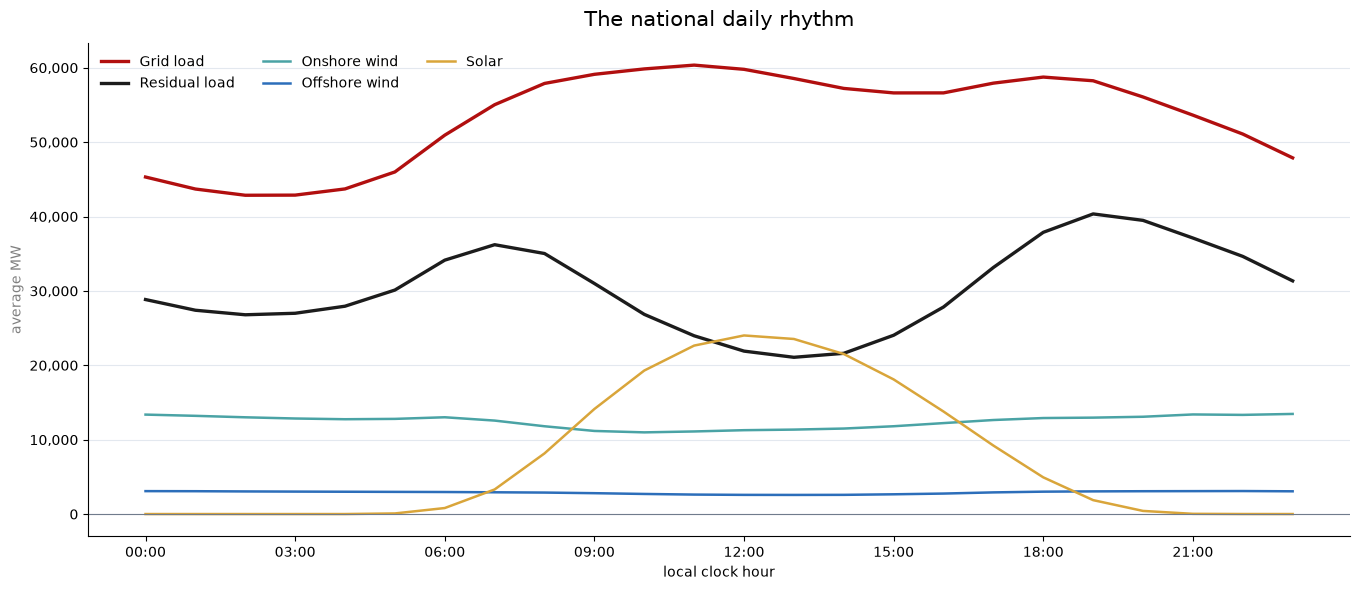

In [33]:
RHYTHM_COLS = ["grid_load", "residual_load", "wind_on", "wind_off", "solar"]
hourly_profile = time_series.groupby("hour")[RHYTHM_COLS].mean()

fig, ax = plt.subplots(figsize=(13.7, 6.0))
for col in RHYTHM_COLS:
    ax.plot(hourly_profile.index, hourly_profile[col].to_numpy(), **series_style(col))

ax.axhline(0, color=COLORS["muted"], lw=0.8)
ax.set_title("The national daily rhythm", fontsize=15, pad=12)
ax.set_xlabel("local clock hour")
ax.set_ylabel("average MW", color="grey")
ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
ax.grid(axis="y", color=COLORS["grid"], lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

One picture of the whole mechanism. Demand ramps from its overnight trough to a daytime plateau;
solar rises and falls inside that plateau; wind, on- and offshore, is nearly flat across the day
because weather has no clock. `residual_load` is what is left, and its daily shape is therefore
**demand's shape with solar's shape subtracted** — the midday dip that neither `grid_load` nor any
single generation series shows on its own.

### 5.3 — Grid load on national holidays

The same federal holiday list as §3.6 — `holidays.country_holidays("DE")`, no `subdiv`, one source
of truth — but a different question: §3.6 measured *how much* each holiday depresses load, this
shows *what shape* the depressed day has. Colours follow §1.2's day-type pair, with holidays taking
the non-working-day blue.

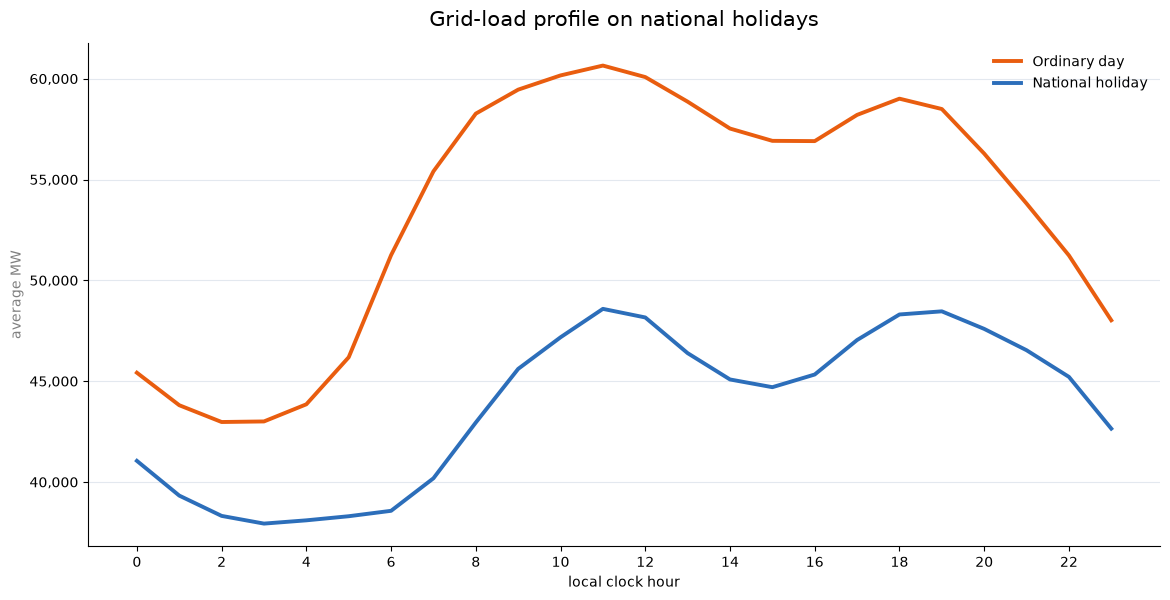

holiday days in the record : 42
largest gap                : 15,317 MW at 08:00
smallest gap               : 4,371 MW at 00:00


In [34]:
is_holiday = pd.Series(time_series.index.date, index=time_series.index).isin(holiday_dates)

holiday_profile = (
    time_series.groupby([is_holiday.rename("is_holiday"), "hour"])["grid_load"]
    .mean()
    .unstack(0)
    .rename(columns={False: "Ordinary day", True: "National holiday"})
)

fig, ax = plt.subplots(figsize=(11.8, 6.1))
ax.plot(
    holiday_profile.index, holiday_profile["Ordinary day"].to_numpy(),
    color=DAY_TYPE_COLOR["weekday"], lw=2.8, label="Ordinary day",
)
ax.plot(
    holiday_profile.index, holiday_profile["National holiday"].to_numpy(),
    color=DAY_TYPE_COLOR["weekend"], lw=2.8, label="National holiday",
)

ax.set_title("Grid-load profile on national holidays", fontsize=15, pad=12)
ax.set_xlabel("local clock hour")
ax.set_ylabel("average MW", color="grey")
ax.set_xticks(range(0, 24, 2))
ax.grid(axis="y", color=COLORS["grid"], lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

peak_gap = (holiday_profile["Ordinary day"] - holiday_profile["National holiday"])
print(f"holiday days in the record : {int(is_holiday.groupby(time_series.index.date).any().sum())}")
print(f"largest gap                : {peak_gap.max():,.0f} MW at {peak_gap.idxmax():02d}:00")
print(f"smallest gap               : {peak_gap.min():,.0f} MW at {peak_gap.idxmin():02d}:00")

A holiday does not flatten the day — it **lowers and softens** it. The overnight trough is nearly
unchanged, because base load does not take holidays; the gap opens through the working hours and
is widest in the morning, exactly where an ordinary day's ramp is steepest. The holiday curve keeps
a recognisable daytime hump, it is simply shallower and later.

Combined with §3.6's roughly one-fifth reduction, the modelling read is that a holiday behaves like
an extra weekend day rather than like a shutdown — which is why a single binary holiday feature,
interacted with the hour of day, is likely to be enough.

### 5.4 — A single-event study: Euro 2024

Germany's five matches at Euro 2024, against matched ordinary days at the same weekday and hour
(±7 to ±28 days, excluding the tournament window). The fixture dates are **historical fact, not a
property of the record**, so they are the one place in this notebook where calendar literals are
deliberate; the cell checks the record actually covers them and skips cleanly if it does not.

In [35]:
EURO_YEAR = 2024  # euro-fixture-literal: historical fact, not a property of the record

# (month, day, kickoff hour, opponent, stage) for Germany's five matches, all in EURO_YEAR.
EURO_FIXTURES = pd.DataFrame(
    [
        (6, 14, 21, "Scotland", "Group stage"),
        (6, 19, 18, "Hungary", "Group stage"),
        (6, 23, 21, "Switzerland", "Group stage"),
        (6, 29, 21, "Denmark", "Round of 16"),
        (7, 5, 18, "Spain", "Quarter-final"),
    ],
    columns=["month", "day", "hour", "opponent", "stage"],
)
EURO_FIXTURES["kickoff"] = [
    pd.Timestamp(year=EURO_YEAR, month=row.month, day=row.day, hour=row.hour)
    for row in EURO_FIXTURES.itertuples(index=False)
]
TOURNAMENT = (
    pd.Timestamp(year=EURO_YEAR, month=6, day=14),
    pd.Timestamp(year=EURO_YEAR, month=7, day=14),
)

RELATIVE_HOURS = range(-4, 5)
REFERENCE_OFFSETS = [-28, -21, -14, -7, 7, 14, 21, 28]

covered = EURO_FIXTURES["kickoff"].between(time_series.index.min(), time_series.index.max()).all()
if not covered:
    print(f"record does not cover the Euro {EURO_YEAR} fixtures — event study skipped")
    event_curves = pd.DataFrame(columns=["event", "relative_hour", "grid_load", "delta_load"])
else:
    rows = []
    for match in EURO_FIXTURES.itertuples(index=False):
        for relative_hour in RELATIVE_HOURS:
            event_time = match.kickoff + pd.Timedelta(hours=relative_hour)
            if event_time not in time_series.index:
                continue
            references = [
                time_series.at[reference_time, "grid_load"]
                for offset in REFERENCE_OFFSETS
                for reference_time in [event_time + pd.Timedelta(days=offset)]
                if reference_time in time_series.index
                and not (TOURNAMENT[0] <= reference_time.normalize() <= TOURNAMENT[1])
            ]
            if not references:
                continue
            observed = time_series.at[event_time, "grid_load"]
            rows.append(
                {
                    "event": f"Germany–{match.opponent}",
                    "relative_hour": relative_hour,
                    "grid_load": observed,
                    "delta_load": observed - float(np.mean(references)),
                }
            )
    event_curves = pd.DataFrame(rows)

display(EURO_FIXTURES[["kickoff", "opponent", "stage"]])
print(
    f"complete event-hour comparisons: {len(event_curves)} of "
    f"{len(EURO_FIXTURES) * len(list(RELATIVE_HOURS))}"
)

,kickoff,opponent,stage
0,2024-06-14 21:00:00,Scotland,Group stage
1,2024-06-19 18:00:00,Hungary,Group stage
2,2024-06-23 21:00:00,Switzerland,Group stage
3,2024-06-29 21:00:00,Denmark,Round of 16
4,2024-07-05 18:00:00,Spain,Quarter-final


complete event-hour comparisons: 45 of 45


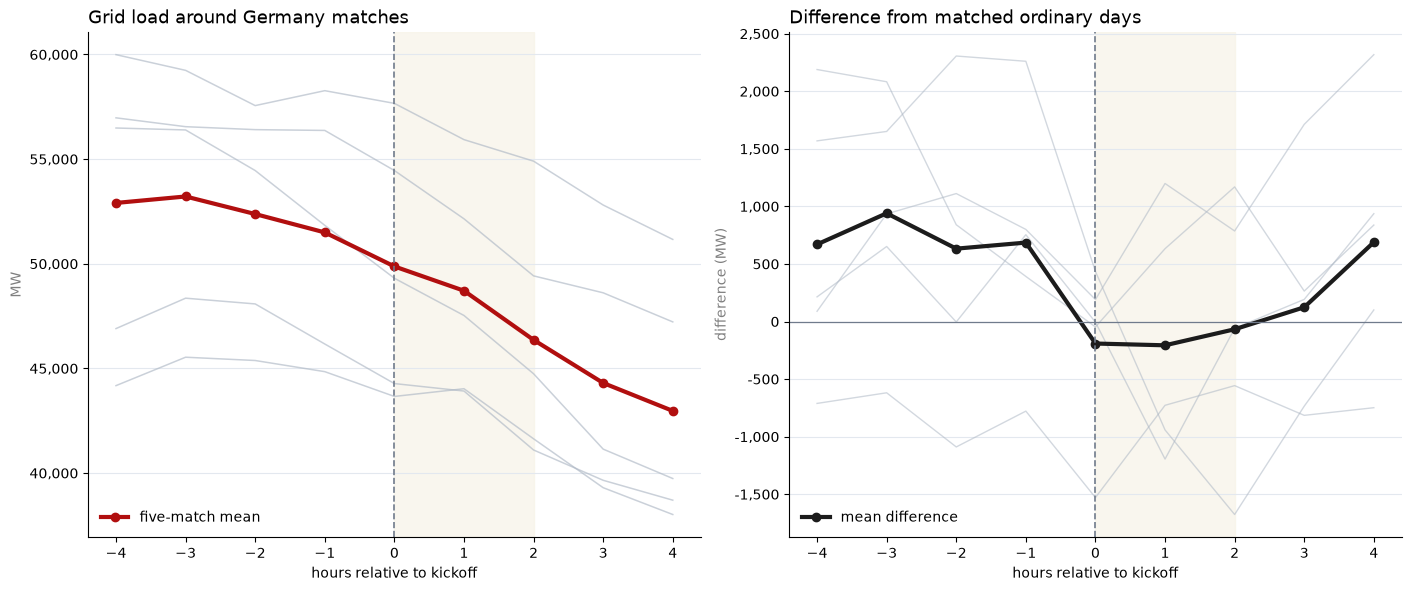

mean deviation during the first two hours of play: -155 MW
largest single-hour deviation: 940 MW at h-3


In [36]:
if event_curves.empty:
    print("no event hours available — nothing to plot")
else:
    event_mean = event_curves.groupby("relative_hour")[["grid_load", "delta_load"]].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), sharex=True, constrained_layout=True)
    for _, curve in event_curves.groupby("event"):
        axes[0].plot(curve["relative_hour"], curve["grid_load"], color=COLORS["gray"], lw=1.1, alpha=0.65)
        axes[1].plot(curve["relative_hour"], curve["delta_load"], color=COLORS["gray"], lw=1.0, alpha=0.55)

    axes[0].plot(
        event_mean.index, event_mean["grid_load"].to_numpy(),
        color=SERIES_COLOR["grid_load"], lw=3.0, marker="o", label="five-match mean",
    )
    axes[1].plot(
        event_mean.index, event_mean["delta_load"].to_numpy(),
        color=COLORS["black"], lw=3.0, marker="o", label="mean difference",
    )

    for ax in axes:
        ax.axvline(0, color=COLORS["muted"], lw=1.2, ls="--")
        ax.axvspan(0, 2, color=COLORS["cream"], alpha=0.7, zorder=0)
        ax.set_xlabel("hours relative to kickoff")
        ax.set_xticks(list(RELATIVE_HOURS))
        ax.grid(axis="y", color=COLORS["grid"], lw=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
        ax.legend(frameon=False)

    axes[0].set_title("Grid load around Germany matches", loc="left", fontsize=13)
    axes[0].set_ylabel("MW", color="grey")
    axes[1].axhline(0, color=COLORS["muted"], lw=0.9)
    axes[1].set_title("Difference from matched ordinary days", loc="left", fontsize=13)
    axes[1].set_ylabel("difference (MW)", color="grey")
    plt.show()

    kickoff_window = event_mean.loc[0:2, "delta_load"]
    print(f"mean deviation during the first two hours of play: {kickoff_window.mean():+,.0f} MW")
    print(f"largest single-hour deviation: {event_mean['delta_load'].abs().max():,.0f} MW "
          f"at h{event_mean['delta_load'].abs().idxmax():+d}")

An honest null-ish result, and worth keeping for exactly that reason. The deviation from matched
ordinary days during the match hours is small against the scale of national demand — a few hundred
MW on a base near 60 GW, comfortably inside the spread of the five individual matches. Whatever
happens in living rooms does not move the national aggregate the way the folklore suggests.

The value of this plot is therefore **negative evidence**: single cultural events at this scale are
not a feature worth engineering, and the model does not need an events calendar to explain the
residual variance of a June evening.

### 5.5 — How much of the daily shape fits into a few harmonics?

A Fourier view of the mean `residual_load` day: fit 1, 2 and 3 harmonics of a 24-hour period to
the hour-of-day mean and see how quickly the observed shape is recovered. This is a modelling
question — it is asking how many Fourier features a model would need to encode the daily cycle.

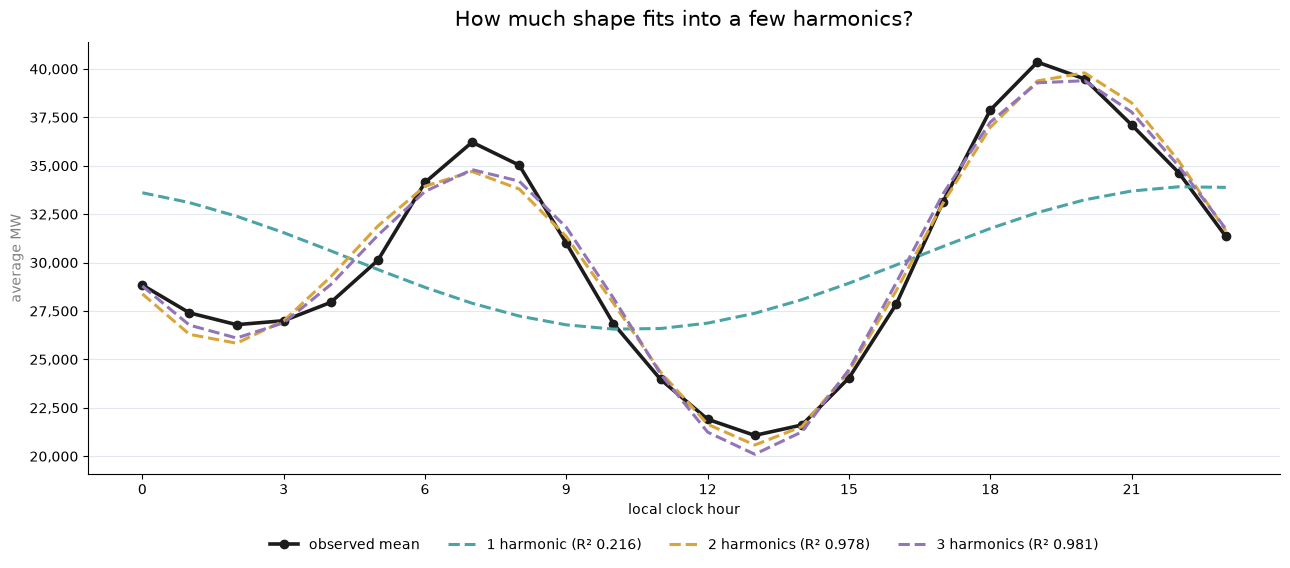

In [37]:
def harmonic_fit(y, n_harmonics):
    """Least-squares fit of `n_harmonics` sine/cosine pairs (period 24 h) to an hour-of-day mean."""
    hours = np.arange(24)
    columns = [np.ones_like(hours, dtype=float)]
    for k in range(1, n_harmonics + 1):
        columns.extend([np.sin(2 * np.pi * k * hours / 24), np.cos(2 * np.pi * k * hours / 24)])
    design = np.column_stack(columns)
    mask = np.isfinite(y)
    beta = np.linalg.lstsq(design[mask], y[mask], rcond=None)[0]
    return design @ beta


mean24 = time_series.groupby("hour")["residual_load"].mean().reindex(range(24)).to_numpy()
hours = np.arange(24)

HARMONIC_STYLE = {1: COLORS["teal"], 2: COLORS["gold"], 3: COLORS["purple"]}

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.plot(hours, mean24, color=SERIES_COLOR["residual_load"], marker="o", lw=2.6, label="observed mean")
for n_harmonics, color in HARMONIC_STYLE.items():
    fitted = harmonic_fit(mean24, n_harmonics)
    residual_share = 1 - np.var(mean24 - fitted) / np.var(mean24)
    ax.plot(
        hours, fitted, color=color, ls="--", lw=2.2,
        label=f"{n_harmonics} harmonic{'s' if n_harmonics > 1 else ''} (R² {residual_share:.3f})",
    )

ax.set_title("How much shape fits into a few harmonics?", fontsize=15, pad=12)
ax.set_xlabel("local clock hour")
ax.set_ylabel("average MW", color="grey")
ax.set_xticks(range(0, 24, 3))
ax.grid(axis="y", color=COLORS["grid"], lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

The R² values in the legend make the answer unusually sharp. **One harmonic is not merely
imprecise, it is the wrong shape** — a single sine/cosine pair can only produce one peak and one
trough per day, so it fits a lazy hump that peaks where the real curve has its midday minimum, and
explains barely a fifth of the variance. **Two harmonics jump to almost all of it**, because the
real shape is a twin-peaked day: a morning ramp, the solar-driven midday trough, and the evening
maximum. The third harmonic adds very little beyond sharpening the corners.

For modelling that is a concrete, cheap result: two Fourier pairs on the hour of day encode the
mean daily cycle of `residual_load` nearly completely — but starting at one would systematically
misplace exactly the hours this project cares about.

### 5.6 — Has the daily shape itself changed?

Anchor years, compared on the **same calendar window** so the partial final year is not judged
against full ones. The anchors are computed from `YEARS` — first year, middle year, last complete
year, and the current partial year if there is one — never hardcoded, so the selection follows the
record if the fetch range widens.

In [38]:
# A year is complete when the record covers both its first and its last hour.
complete_years = [
    year for year in YEARS
    if time_series.index.min() <= pd.Timestamp(year=year, month=1, day=1)
    and time_series.index.max() >= pd.Timestamp(year=year, month=12, day=31, hour=23)
]
partial_years = [year for year in YEARS if year not in complete_years]

anchor_years = sorted(
    dict.fromkeys(
        [YEARS[0], YEARS[len(YEARS) // 2]]
        + ([complete_years[-1]] if complete_years else [])
        + ([partial_years[-1]] if partial_years else [])
    )
)
baseline_year = anchor_years[0]

# Matched window: 1 Jan to the last date the final year reaches, applied to every year.
cutoff = time_series.index.max()
matched = time_series[
    (time_series.index.month < cutoff.month)
    | ((time_series.index.month == cutoff.month) & (time_series.index.day <= cutoff.day))
]
annual_shape = matched.groupby(["year", "hour"])["residual_load"].mean().unstack(0)

print(f"complete years : {complete_years}")
print(f"partial years  : {partial_years}")
print(f"anchor years   : {anchor_years}  (baseline {baseline_year})")
print(f"matched window : 1 Jan .. {cutoff:%d %b} of each year, {len(matched):,} of {len(time_series):,} rows")

complete years : [2022, 2023, 2024, 2025]
partial years  : [2026]
anchor years   : [2022, 2024, 2025, 2026]  (baseline 2022)
matched window : 1 Jan .. 09 Sep of each year, 30,259 of 41,107 rows


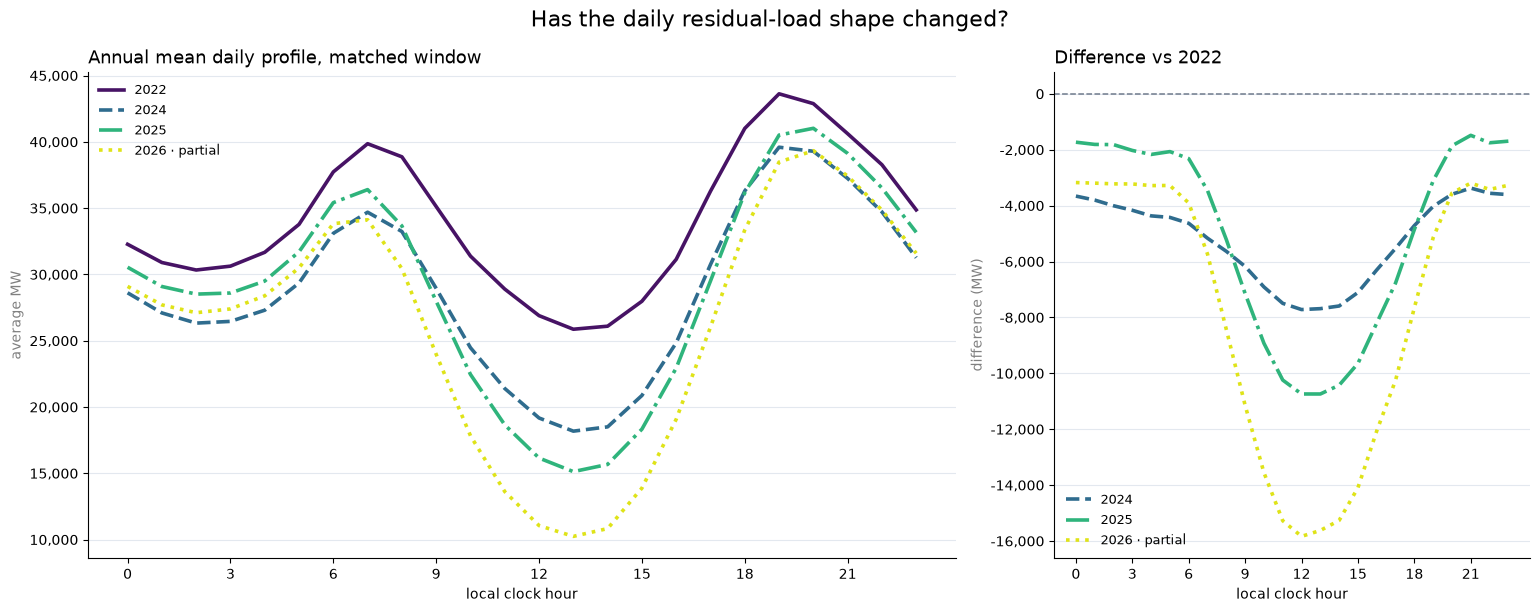

matched-window means by anchor year (average MW):
  2022: midday 10-15h   27,851   night 00-05h   31,596
  2024: midday 10-15h   20,432   night 00-05h   27,525
  2025: midday 10-15h   17,731   night 00-05h   29,659
  2026: midday 10-15h   12,911   night 00-05h   28,365


In [39]:
ANCHOR_COLOR = year_colors(anchor_years)
ANCHOR_DASHES = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.2), gridspec_kw={"width_ratios": [1.55, 0.85]})

for position, year in enumerate(anchor_years):
    label = f"{year} · partial" if year in partial_years else str(year)
    style = dict(
        color=ANCHOR_COLOR[year],
        ls=ANCHOR_DASHES[position % len(ANCHOR_DASHES)],
        lw=2.6,
        label=label,
    )
    axes[0].plot(annual_shape.index, annual_shape[year].to_numpy(), **style)
    if year != baseline_year:
        axes[1].plot(
            annual_shape.index,
            (annual_shape[year] - annual_shape[baseline_year]).to_numpy(),
            **style,
        )

axes[0].set_title("Annual mean daily profile, matched window", loc="left", fontsize=13)
axes[0].set_ylabel("average MW", color="grey")
axes[1].axhline(0, color=COLORS["muted"], ls="--", lw=1.1)
axes[1].set_title(f"Difference vs {baseline_year}", loc="left", fontsize=13)
axes[1].set_ylabel("difference (MW)", color="grey")

for ax in axes:
    ax.set_xlabel("local clock hour")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(axis="y", color=COLORS["grid"], lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Has the daily residual-load shape changed?", fontsize=16)
plt.tight_layout()
plt.show()

midday = annual_shape.loc[10:15].mean()
night = annual_shape.loc[0:5].mean()
print("matched-window means by anchor year (average MW):")
for year in anchor_years:
    print(f"  {year}: midday 10-15h {midday[year]:>8,.0f}   night 00-05h {night[year]:>8,.0f}")

The daily shape has not merely shifted down — it has **changed form**, and the difference panel
shows how unevenly. Overnight, the most recent years sit a few GW below the baseline year. Through
the middle of the day they sit *four to five times* further below it, and the gap keeps growing
year by year. The evening peak, meanwhile, has barely moved: the most recent years nearly meet the
baseline again at 19:00–21:00.

So the day has gone from one broad daytime plateau to a pronounced **double peak with a midday
valley** — solar build-out written directly into the shape of the day, not into its level.

This matters for the forecast target. A model trained on the earlier years' daily profile would be
systematically wrong at exactly the hours that now produce the oversupply extremes of §3.7 — and
the drift is ongoing, so the most recent year is the most informative one about the next.

### 5.7 — Self-check

In [40]:
assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)
assert set(anchor_years) <= set(YEARS), anchor_years
assert len(anchor_years) == len(set(anchor_years)) <= 4, anchor_years
assert baseline_year == anchor_years[0]
assert set(complete_years) | set(partial_years) == set(YEARS)
assert list(holiday_profile.columns) == ["Ordinary day", "National holiday"]
assert len(hourly_profile) == 24, len(hourly_profile)

print("calendar-structure self-check passed")
print(f"  anchors {anchor_years} computed from YEARS, baseline {baseline_year}")
print(f"  {len(event_curves)} Euro {EURO_YEAR} event hours compared")
print(f"  no column added to time_series ({len(time_series.columns)} columns)")

calendar-structure self-check passed
  anchors [2022, 2024, 2025, 2026] computed from YEARS, baseline 2022
  45 Euro 2024 event hours compared
  no column added to time_series (18 columns)


---

## 6 — Temporal dependence, decomposition, ramps and extremes

The analytically heaviest section, and the one with the most merging behind it. Three near-duplicate
ACF/PACF analyses become one; [`EDA-magc.ipynb`](EDA-magc.ipynb)'s STL decomposition is extended
from one series to both and from one year to the full record; and
[`EDA-simple-claude.ipynb`](EDA-simple-claude.ipynb)'s residual-load distribution is merged with
[`EDA-hari.ipynb`](EDA-hari.ipynb)'s ramp-percentile panel into a single figure.

Everything hari contributed here was in GW or GW/h; all of it is converted to the project's **MW**
for levels and **MW/h** for ramps.

### 6.1 — Autocorrelation

Two figures per series. The first is the full ACF/PACF grid — 168 lags, then zooms on 0–48 and
48–72 — which shows the daily and weekly cycles as they are. The second removes the weekday × hour
mean first and asks what dependence is *left* once the calendar structure of §3 and §5 is taken
out; that one runs on the series' own longest gap-free segment, because an ACF counts lags by
position and the spring DST gaps would otherwise silently shift every lag after them.

`EDA-magc.ipynb`'s separate ACF/PACF (her cell 30) is a subset of this and is not ported.

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

DEPENDENCE_COLS = ["grid_load", "residual_load"]


def longest_gapfree_segment(col):
    """Longest run of consecutive hourly rows with no missing value in `col`.

    Breaks on both a missing value and an index gap: `spans_gap` marks the row after each DST
    jump, and a lag count that runs across one of those is off by an hour from there on.
    """
    usable = time_series[col].notna() & ~time_series["spans_gap"]
    # A new block starts wherever the row is unusable; keep the longest block of usable rows.
    blocks = (~usable).cumsum()
    lengths = usable.groupby(blocks).sum()
    best = lengths.idxmax()
    segment = time_series.loc[(blocks == best) & usable, col]
    return segment


segments = {col: longest_gapfree_segment(col) for col in DEPENDENCE_COLS}
for col, segment in segments.items():
    print(
        f"{col:<14} longest gap-free segment: {len(segment):,} hours, "
        f"{segment.index.min():%Y-%m-%d %H:%M} .. {segment.index.max():%Y-%m-%d %H:%M}"
    )

grid_load      longest gap-free segment: 8,902 hours, 2023-03-26 04:00 .. 2024-03-31 01:00
residual_load  longest gap-free segment: 8,902 hours, 2023-03-26 04:00 .. 2024-03-31 01:00


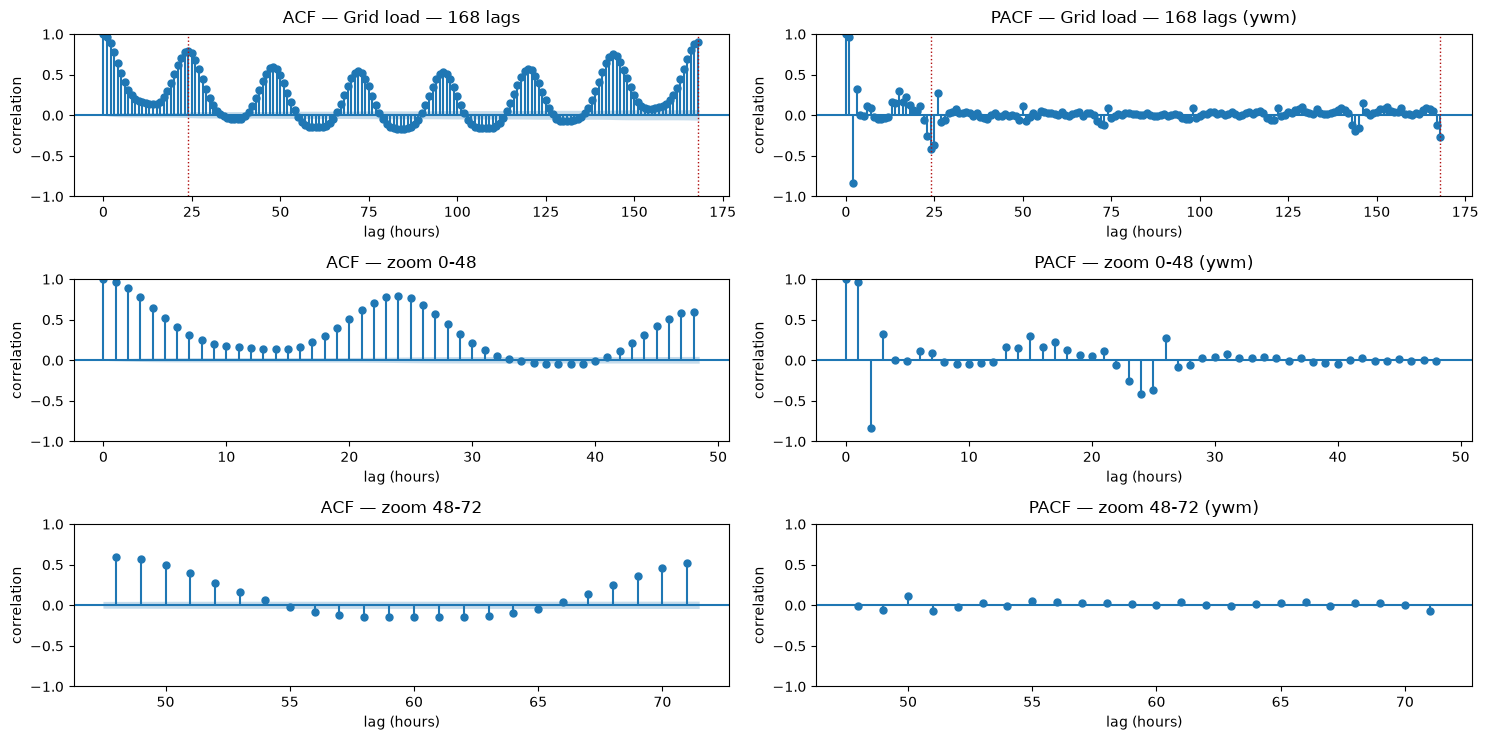

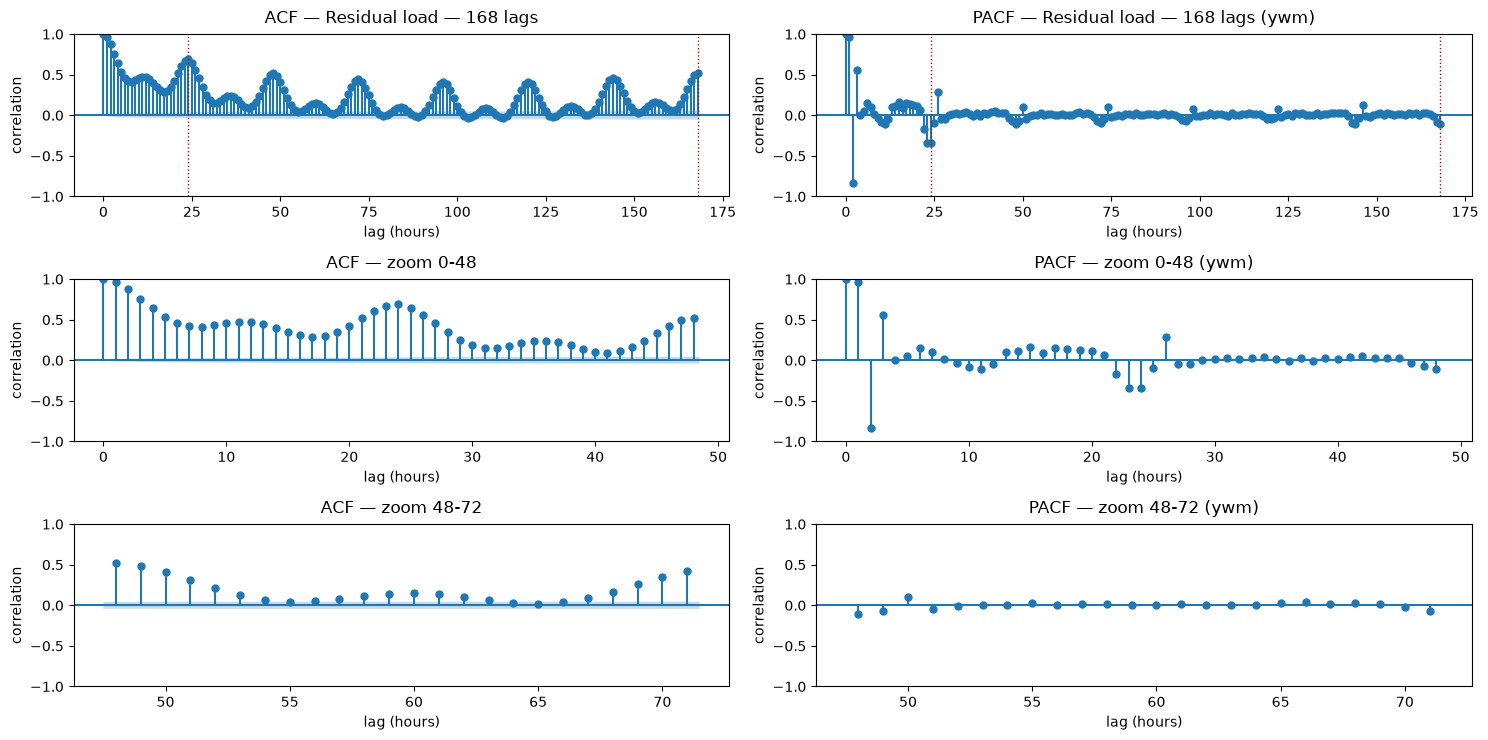

In [42]:
for col in DEPENDENCE_COLS:
    fig, axes = plt.subplots(3, 2, figsize=(15, 7.5))
    series = time_series[col].to_numpy()

    plot_acf(series, lags=168, ax=axes[0, 0])
    plot_pacf(series, lags=168, method="ywm", ax=axes[0, 1])
    plot_acf(series, lags=48, ax=axes[1, 0])
    plot_pacf(series, lags=48, method="ywm", ax=axes[1, 1])
    plot_acf(series, lags=range(48, 72, 1), ax=axes[2, 0])
    plot_pacf(series, lags=range(48, 72, 1), method="ywm", ax=axes[2, 1])

    # set_title AFTER the plot calls: statsmodels writes its own title into the axes.
    label = SERIES_LABEL[col]
    for ax, title in zip(
        axes.flat,
        [f"ACF — {label} — 168 lags", f"PACF — {label} — 168 lags (ywm)",
         "ACF — zoom 0-48", "PACF — zoom 0-48 (ywm)",
         "ACF — zoom 48-72", "PACF — zoom 48-72 (ywm)"],
    ):
        ax.set_title(title, fontsize=12, pad=8)
        ax.set_xlabel("lag (hours)")
        ax.set_ylabel("correlation")

    for ax in axes[0]:
        for lag in (24, 168):
            ax.axvline(lag, color=COLORS["red"], linestyle=":", linewidth=1)

    plt.tight_layout()
    plt.show()

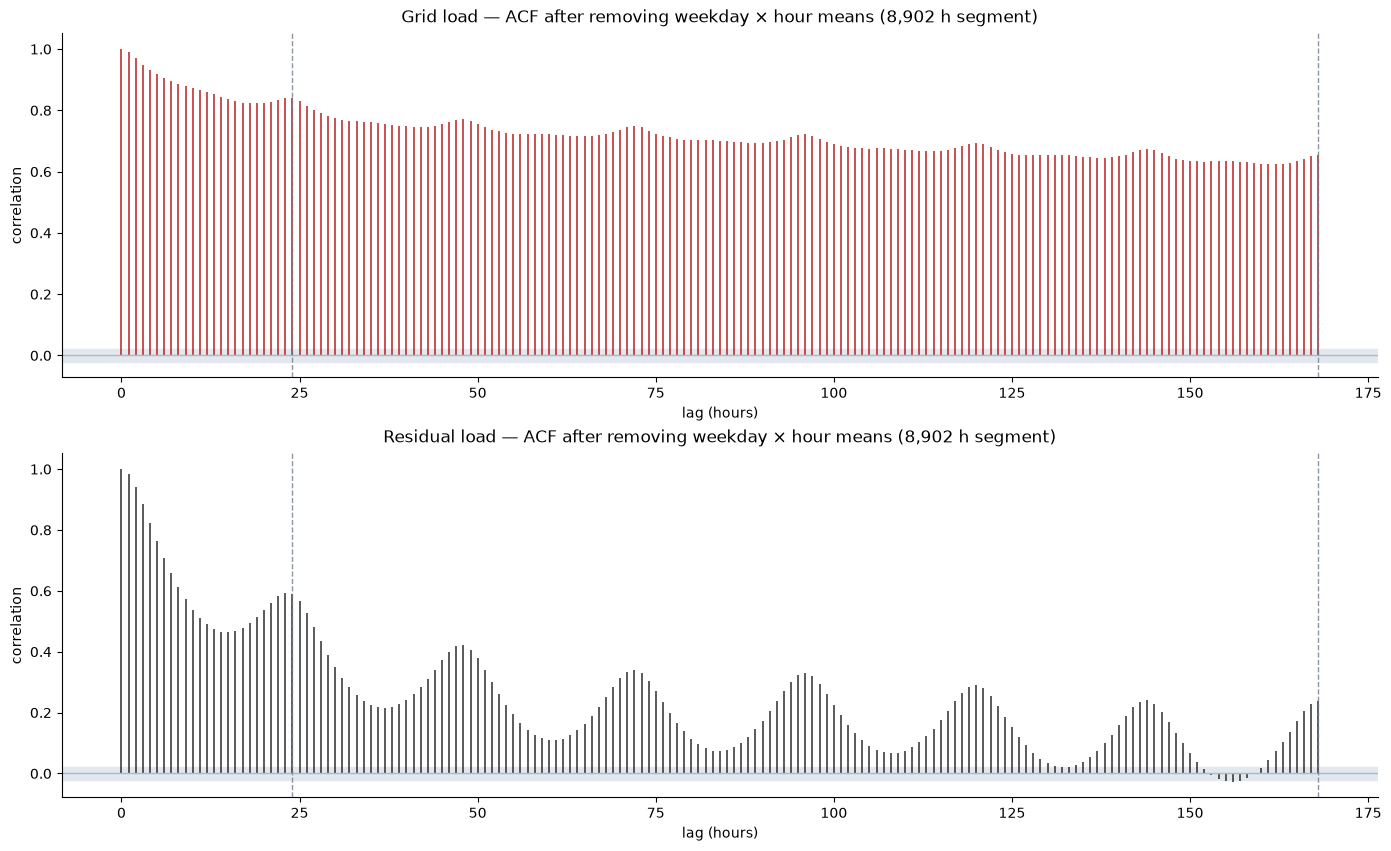

In [43]:
fig, axes = plt.subplots(len(DEPENDENCE_COLS), 1, figsize=(13.8, 8.4), constrained_layout=True)

for ax, col in zip(np.atleast_1d(axes), DEPENDENCE_COLS):
    segment = segments[col]
    calendar_mean = segment.groupby(
        [segment.index.dayofweek, segment.index.hour]
    ).transform("mean")
    adjusted = segment - calendar_mean

    values = acf(adjusted.to_numpy(), nlags=min(168, len(adjusted) // 3), fft=True)
    confidence = 1.96 / np.sqrt(len(adjusted))
    lags = np.arange(len(values))

    ax.axhspan(-confidence, confidence, color=COLORS["grid"], zorder=0)
    ax.vlines(lags, 0, values, color=SERIES_COLOR[col], lw=1.2, alpha=0.85)
    ax.axhline(0, color=COLORS["gray"], lw=1.0)
    for lag in (24, 168):
        if lag <= lags.max():
            ax.axvline(lag, color=COLORS["muted"], ls="--", lw=1.0, alpha=0.8)

    ax.set_title(
        f"{SERIES_LABEL[col]} — ACF after removing weekday × hour means "
        f"({len(adjusted):,} h segment)",
        fontsize=12, pad=8,
    )
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("correlation")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

plt.show()

The raw ACFs are textbook: both series stay strongly autocorrelated out to a week, with peaks at
every multiple of 24 lags and a pronounced one at 168. The PACF concentrates almost everything in
the first few lags plus a spike at 24 — the usual signature of a series that is mostly "yesterday
at this hour plus a short memory".

The de-seasonalized ACFs show what a model that already knows the calendar would still have to
explain — and the two series answer very differently.

For **`grid_load`**, removing the weekday × hour mean barely helps: the correlation stays around
0.7 at *every* lag out to a full week, with only a shallow decay. What is left is not daily
structure at all but a **slow-moving level** — the annual season and the weather-driven drift that
a weekday × hour mean cannot represent. The practical reading is that grid load needs a recent-level
or seasonal term, not more daily lags.

For **`residual_load`** the same operation works much better: the correlation falls to roughly 0.2
within a day and a half, leaving clear but **decaying 24-hour echoes** on top of short-range
persistence. That is weather memory — wind and solar carry over from hour to hour and day to day,
but they do fade. Lagged features are worth more here than for grid load, and they have a horizon.

### 6.2 — Seasonal decomposition

STL with a 24-hour period, `robust=True`, over the **full record** and for **both** series —
magc's original covered `grid_load` only, over a one-year window.

One approximation to name: `period=24` assumes every day has 24 observations, and the spring DST
days in this record have 23. The decomposition is therefore very slightly misaligned after each
spring switch. That is an acceptable, documented approximation here, the same one the ACF lag
counting makes; it is not a reason to fill the gaps.

In [44]:
from statsmodels.tsa.seasonal import STL
from time import perf_counter

stl_results = {}
for col in DEPENDENCE_COLS:
    started = perf_counter()
    # Values, not the Series: the index has DST gaps and therefore no usable freq attribute.
    stl_results[col] = STL(time_series[col].to_numpy(), period=24, robust=True).fit()
    print(f"STL {col:<14} fitted in {perf_counter() - started:5.1f} s")

STL grid_load      fitted in   5.6 s
STL residual_load  fitted in   5.7 s


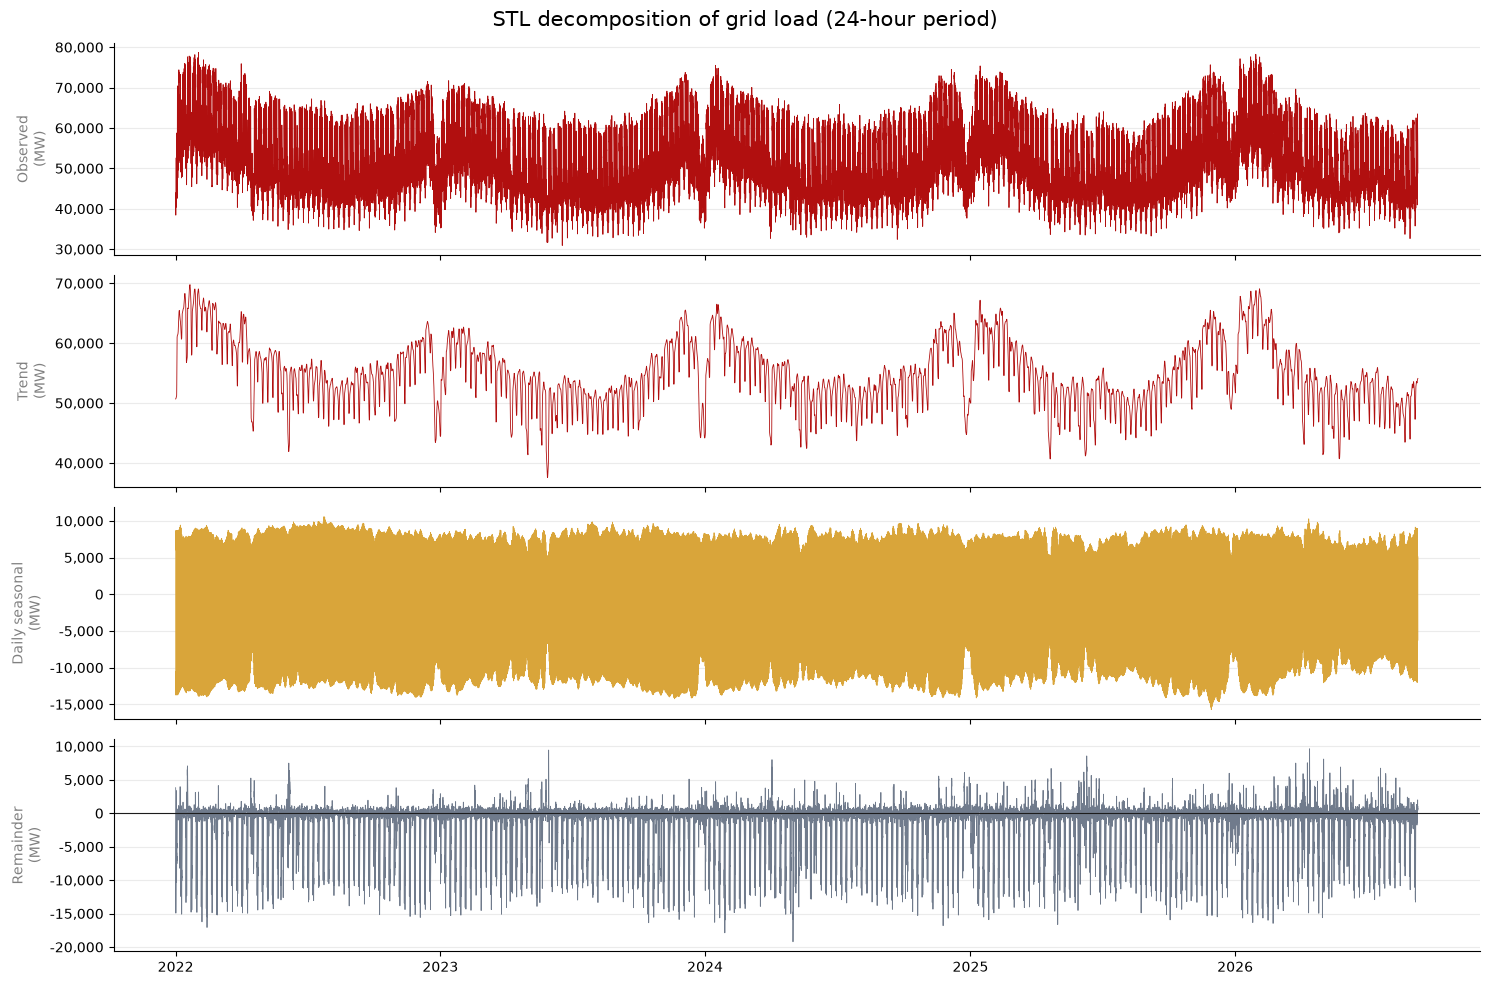

Grid load: daily-seasonal strength 0.77, remainder std 3,402 MW


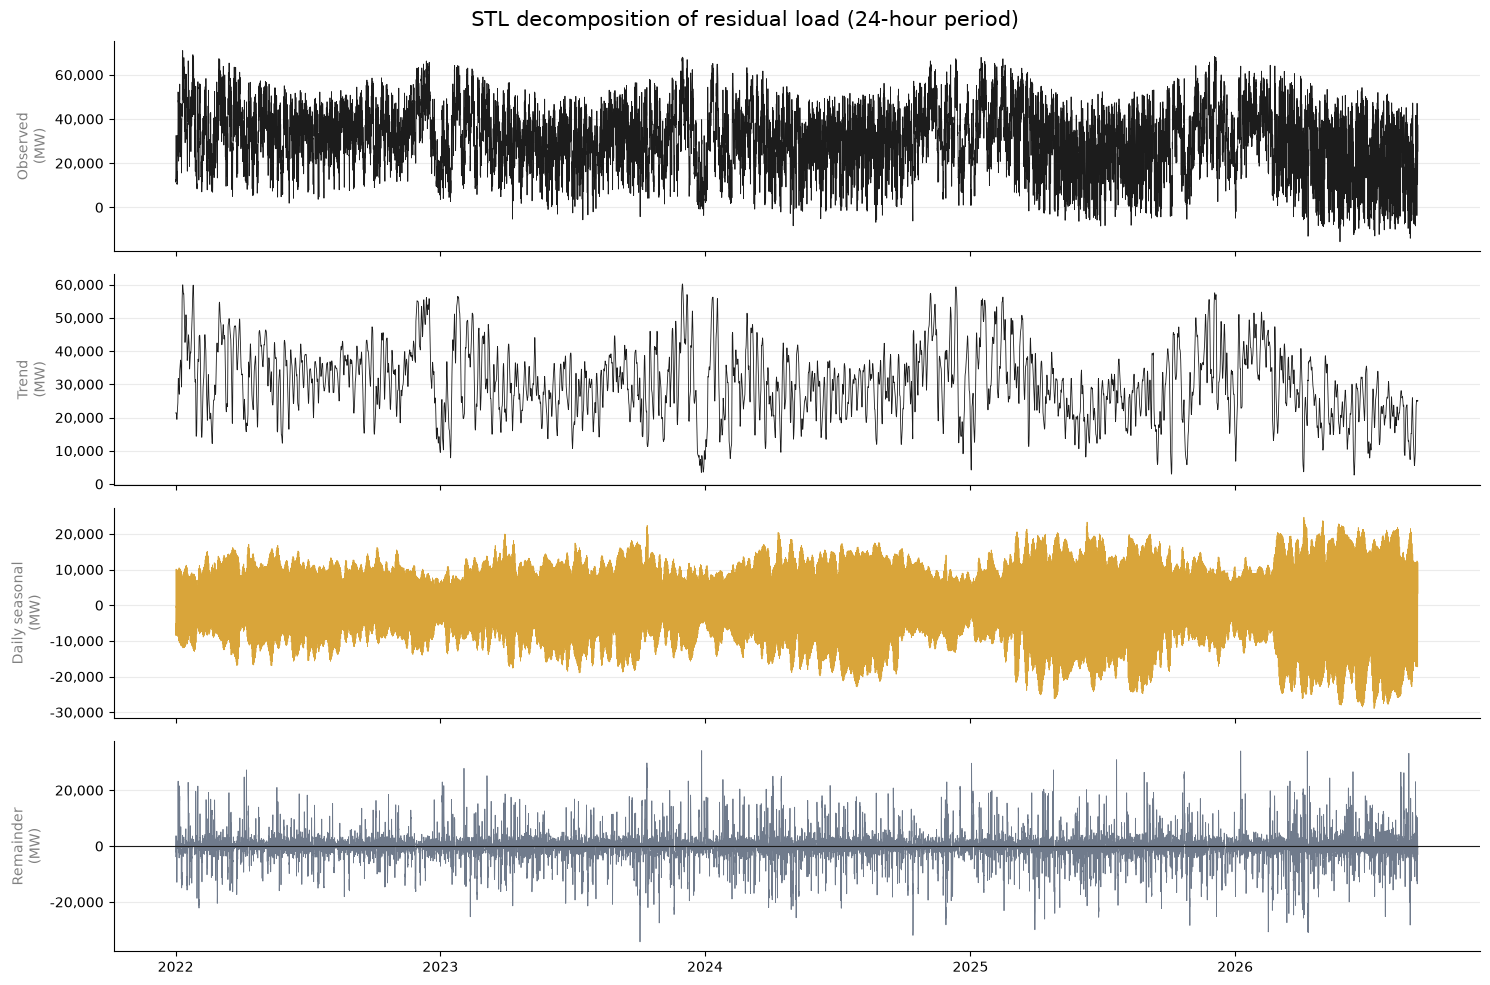

Residual load: daily-seasonal strength 0.69, remainder std 5,393 MW


In [45]:
for col in DEPENDENCE_COLS:
    result = stl_results[col]
    components = [
        ("Observed", time_series[col].to_numpy(), SERIES_COLOR[col]),
        ("Trend", result.trend, SERIES_COLOR[col]),
        ("Daily seasonal", result.seasonal, COLORS["gold"]),
        ("Remainder", result.resid, COLORS["muted"]),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
    for ax, (name, values, color) in zip(axes, components):
        ax.plot(time_series.index, values, color=color, linewidth=0.6)
        ax.set_ylabel(f"{name}\n(MW)", color="grey")
        ax.grid(axis="y", color="0.92", linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    axes[-1].axhline(0, color=COLORS["black"], linewidth=0.8)
    axes[-1].set_xlabel("")

    fig.suptitle(f"STL decomposition of {SERIES_LABEL[col].lower()} (24-hour period)", fontsize=15)
    plt.tight_layout()
    plt.show()

    strength = 1 - np.var(result.resid) / np.var(result.seasonal + result.resid)
    print(f"{SERIES_LABEL[col]}: daily-seasonal strength {strength:.2f}, "
          f"remainder std {np.std(result.resid):,.0f} MW")

The two decompositions separate cleanly, and their **daily-seasonal strengths differ**: for
`grid_load` the daily component is a large, stable share of the short-term variation, while
`residual_load`'s daily component has grown visibly over the record — the seasonal band widens
towards the recent years, which is §5.6's deepening midday valley seen from another angle.

The remainders are the part a forecast has to earn, and `residual_load`'s is **substantially
larger** — its standard deviation is printed above and runs well above `grid_load`'s. Both
remainders are spiky rather than smooth: a base of small deviations with occasional excursions many
times that size, spread across the whole record rather than concentrated in one season.

### 6.3 — The residual-load distribution and its ramps

Two questions in one figure, merged from two source notebooks: **where does residual load sit**
(simple-claude's histogram and summary statistics) and **how fast does it move** (hari's ramp
percentile curve). Levels are in MW, ramps in MW/h.

,residual_load (MW)
mean,30239.64
median,31152.16
std,14339.75
skew,-0.18
excess kurtosis,-0.28
min,-15561.59
max,70964.00
range,86525.59
min in std below median,3.26
max in std above median,2.78


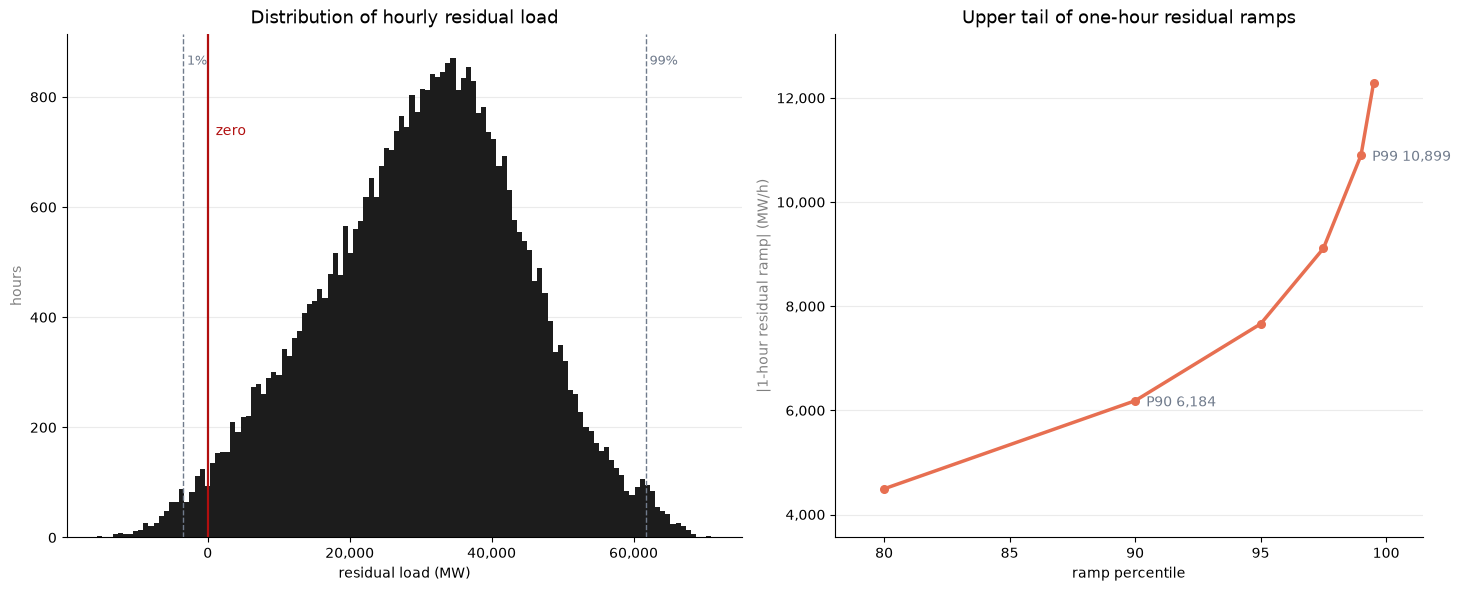

ramp NaNs: 6 (expected 6: one per DST gap plus the first row)


In [46]:
residual = time_series["residual_load"]

# ramp: masked at each DST gap, because a "one-hour" difference across a gap is a two-hour change.
ramp = residual.diff().mask(time_series["spans_gap"])
abs_ramp = ramp.abs().dropna()

shape = pd.Series(
    {
        "mean": residual.mean(),
        "median": residual.median(),
        "std": residual.std(),
        "skew": residual.skew(),
        "excess kurtosis": residual.kurt(),
        "min": residual.min(),
        "max": residual.max(),
        "range": residual.max() - residual.min(),
        "min in std below median": (residual.median() - residual.min()) / residual.std(),
        "max in std above median": (residual.max() - residual.median()) / residual.std(),
        "negative hours": int((residual < 0).sum()),
        "negative share %": 100 * (residual < 0).mean(),
    }
)
display(shape.round(2).to_frame("residual_load (MW)"))

RAMP_QUANTILES = [0.80, 0.90, 0.95, 0.975, 0.99, 0.995]
ramp_percentiles = abs_ramp.quantile(RAMP_QUANTILES)

fig, axes = plt.subplots(
    1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1.15, 1]}, constrained_layout=True
)

axes[0].hist(residual, bins=120, color=SERIES_COLOR["residual_load"])
for quantile in (0.01, 0.99):
    axes[0].axvline(residual.quantile(quantile), color=COLORS["muted"], linestyle="--", linewidth=1)
    axes[0].text(
        residual.quantile(quantile), axes[0].get_ylim()[1] * 0.94,
        f" {quantile:.0%}", color=COLORS["muted"], fontsize=9,
    )
axes[0].axvline(0, color=COLORS["red"], linewidth=1.6)
axes[0].text(0, axes[0].get_ylim()[1] * 0.80, "  zero", color=COLORS["red"], fontsize=10)
axes[0].set_title("Distribution of hourly residual load", fontsize=13, pad=8)
axes[0].set_xlabel("residual load (MW)")
axes[0].set_ylabel("hours", color="grey")

axes[1].plot(
    np.array(RAMP_QUANTILES) * 100, ramp_percentiles.to_numpy(),
    color=RAMP_COLOR, marker="o", markersize=5.5, lw=2.5,
)
for quantile in (0.90, 0.99):
    axes[1].annotate(
        f"P{quantile * 100:g} {ramp_percentiles.loc[quantile]:,.0f}",
        xy=(quantile * 100, ramp_percentiles.loc[quantile]),
        xytext=(8, -4), textcoords="offset points", fontsize=10, color=COLORS["muted"],
    )
axes[1].margins(x=0.10, y=0.12)
axes[1].set_title("Upper tail of one-hour residual ramps", fontsize=13, pad=8)
axes[1].set_xlabel("ramp percentile")
axes[1].set_ylabel("|1-hour residual ramp| (MW/h)", color="grey")

for ax in axes:
    ax.grid(axis="y", color="0.92", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
plt.show()

print(f"ramp NaNs: {int(ramp.isna().sum())} "
      f"(expected {int(time_series['spans_gap'].sum()) + 1}: one per DST gap plus the first row)")

The distribution is **broad and close to symmetric** — a mild negative skew, slightly flatter than
a normal curve, spread over a range of more than 80 GW. There is no second mode and no sharp
cut-off: oversupply is not a separate population of hours but the far end of one continuum, which
is why every threshold question in this project is a judgement call rather than something the data
answers on its own.

Two numbers in the table matter more than the shape. The minimum sits **further below the median
than the maximum sits above it** in standard-deviation terms, so the low tail is the longer one.
And around 2 % of all hours are already **negative** — a small share, but a growing and highly
clustered one, as §3.7 and §6.5 show.

The ramp curve is the other half of the operating picture, and it is deliberately shown next to the
distribution because the two describe different risks. A typical hour changes by very little; the
upper percentiles rise steeply, so the hours that matter are rare and large. Note this is
`|1 h residual ramp|` over the whole record — §6.4 shows that it is not stationary.

### 6.4 — Ramps by year

The same quantiles, split by year on the matched calendar window from §5.6 so the partial final
year is compared like for like.

,P50,P90,P95,P99
timestamp,,,,
2022,2181.0,5550.0,6490.0,8276.0
2023,2188.0,5693.0,6782.0,8652.0
2024,2325.0,6271.0,7643.0,9686.0
2025,2515.0,7273.0,9095.0,12389.0
2026,2631.0,8369.0,10360.0,13308.0


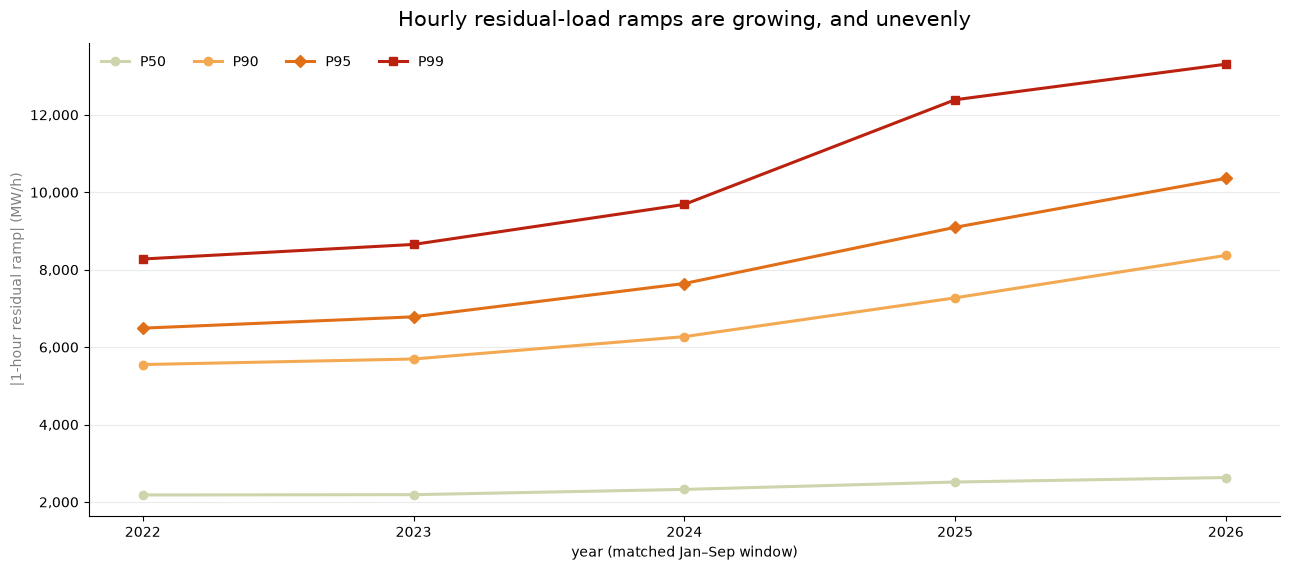

change from 2022 to 2026:
P50    20.6
P90    50.8
P95    59.6
P99    60.8


In [47]:
# `matched` (1 Jan .. the record's last calendar date, every year) comes from §5.6.
RAMP_YEAR_QUANTILES = [0.50, 0.90, 0.95, 0.99]
matched_ramp = ramp.abs().loc[matched.index].dropna()

ramp_by_year = (
    matched_ramp.groupby(matched_ramp.index.year)
    .quantile(RAMP_YEAR_QUANTILES)
    .unstack()
)
ramp_by_year.columns = [f"P{q * 100:g}" for q in RAMP_YEAR_QUANTILES]
display(ramp_by_year.round(0))

QUANTILE_COLOR = quantile_colors(ramp_by_year.columns)
MARKERS = ["o", "o", "D", "s"]

fig, ax = plt.subplots(figsize=(13, 5.8))
for marker, column in zip(MARKERS, ramp_by_year.columns):
    ax.plot(
        ramp_by_year.index, ramp_by_year[column].to_numpy(),
        color=QUANTILE_COLOR[column], marker=marker, lw=2.2, label=column,
    )

ax.set_title("Hourly residual-load ramps are growing, and unevenly", fontsize=15, pad=12)
ax.set_xlabel("year (matched Jan–Sep window)")
ax.set_ylabel("|1-hour residual ramp| (MW/h)", color="grey")
ax.set_xticks(list(ramp_by_year.index))
ax.grid(axis="y", color="0.92", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(ncol=len(ramp_by_year.columns), frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

growth = (ramp_by_year.iloc[-1] / ramp_by_year.iloc[0] - 1) * 100
print(f"change from {ramp_by_year.index[0]} to {ramp_by_year.index[-1]}:")
print(growth.round(1).to_string())

**Change has a different geometry from level.** The median hourly ramp has grown modestly, while
the upper percentiles have grown far faster: the distance between a typical hour and an extreme
hour is widening year on year. A model tuned on the average hour of an early year would be
progressively more wrong about the hours that matter.

This is the second candidate stress mode for the project, recorded and not thresholded: an hour can
be operationally hard because the **level** of residual load is extreme (§3.7) or because the
**rate of change** is, and those are not the same hours. Which of them the risk flag should key on
belongs to the modelling spec.

### 6.5 — Residual-load level by year

,median,p10,p90,n
timestamp,,,,
2022,34590.0,16719.0,49115.0,6047
2023,29619.0,13059.0,45902.0,6047
2024,29600.0,10068.0,45435.0,6071
2025,30242.0,7372.0,47743.0,6047
2026,29057.0,1305.0,45960.0,6047


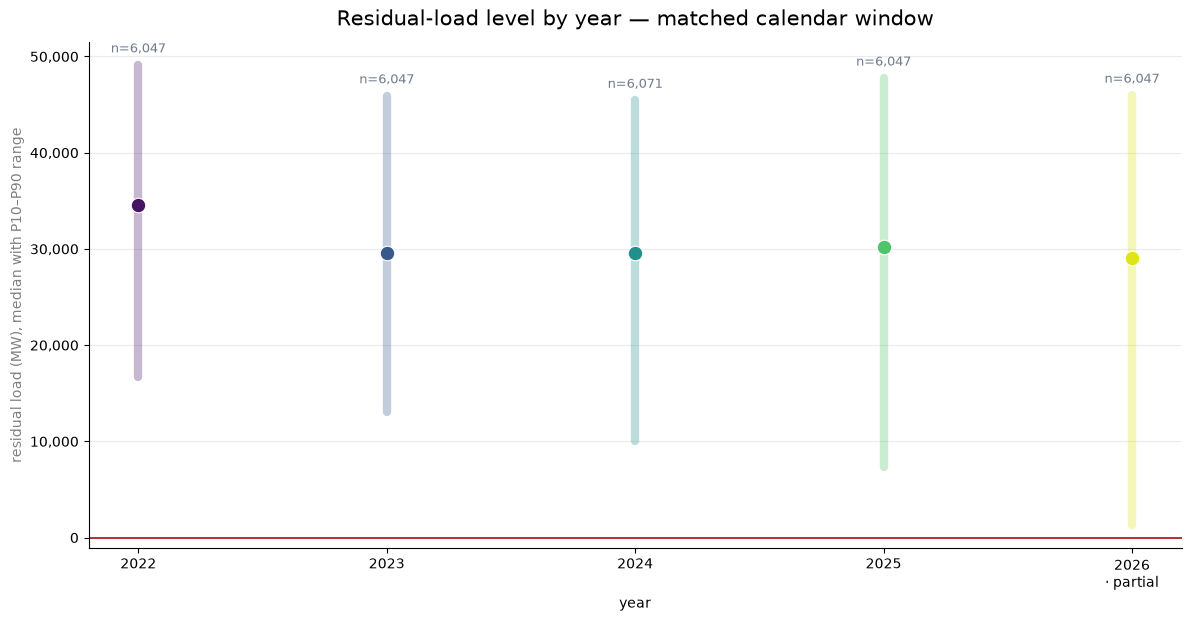

In [48]:
annual_level = matched["residual_load"].groupby(matched.index.year).agg(
    median="median",
    p10=lambda s: s.quantile(0.10),
    p90=lambda s: s.quantile(0.90),
    n="count",
)
display(annual_level.round(0))

LEVEL_YEAR_COLOR = year_colors(annual_level.index)

fig, ax = plt.subplots(figsize=(11.8, 6.1), constrained_layout=True)
for year, row in annual_level.iterrows():
    color = LEVEL_YEAR_COLOR[year]
    ax.plot(
        [year, year], [row["p10"], row["p90"]],
        lw=6, color=color, alpha=0.30, solid_capstyle="round", zorder=1,
    )
    ax.scatter(year, row["median"], s=110, color=color, edgecolor="white", linewidth=0.8, zorder=3)
    ax.text(
        year, row["p90"] + 0.02 * annual_level["p90"].max(),
        f"n={int(row['n']):,}", va="bottom", ha="center", fontsize=9.5, color=COLORS["muted"],
    )

ax.axhline(0, color=COLORS["red"], lw=1.2)
ax.set_xticks(
    list(annual_level.index),
    [f"{year}\n· partial" if year in partial_years else str(year) for year in annual_level.index],
)
ax.set_title("Residual-load level by year — matched calendar window", fontsize=15, pad=12)
ax.set_xlabel("year")
ax.set_ylabel("residual load (MW), median with P10–P90 range", color="grey")
ax.grid(axis="y", color="0.92", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
plt.show()

Median residual load falls year on year, but the **P10 end falls faster than the median** — the
distribution is not sliding down as a block, it is stretching downward. The low end of each year
reaches further towards, and eventually past, zero, while the P90 end barely moves: high-residual
hours are as high as they ever were.

Together with §6.4 this is the section's central finding. Over the record, `residual_load` has
become **lower at its low end, no lower at its high end, and faster-moving throughout** — the
oversupply mode is growing while the tight-margin mode stays put, which is exactly the two-mode
picture §3.7 found on the calendar.

### 6.6 — Self-check

In [49]:
assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)
assert "ramp" not in time_series.columns, "ramp must stay local to this section"
assert int(ramp.isna().sum()) == int(time_series["spans_gap"].sum()) + 1, int(ramp.isna().sum())
for col, segment in segments.items():
    step = segment.index.to_series().diff().dropna()
    assert (step == pd.Timedelta("1h")).all(), f"{col} segment is not gap-free"
assert set(stl_results) == set(DEPENDENCE_COLS)
assert list(ramp_by_year.index) == sorted(ramp_by_year.index)
assert set(annual_level.index) <= set(YEARS)

print("temporal-dependence self-check passed")
print(f"  ramp NaNs == spans_gap + 1 == {int(ramp.isna().sum())}")
print(f"  segments gap-free: " + ", ".join(f"{c} {len(s):,} h" for c, s in segments.items()))
print(f"  STL fitted for {len(stl_results)} series over the full record")
print(f"  no column added to time_series ({len(time_series.columns)} columns)")

temporal-dependence self-check passed
  ramp NaNs == spans_gap + 1 == 6
  segments gap-free: grid_load 8,902 h, residual_load 8,902 h
  STL fitted for 2 series over the full record
  no column added to time_series (18 columns)


---

## 7 — Context appendix

Four supporting views the team wanted kept, but kept **apart** from the main narrative: they
describe the dataset and its context rather than advancing the residual-load story. Then the
notebook's findings, and its closing self-check.

### 7.1 — Data completeness by calendar month

Coverage measured against `time_series`'s own gaps: for every calendar month the record touches,
the share of that month's hours that are present *and* valid in all eight series.

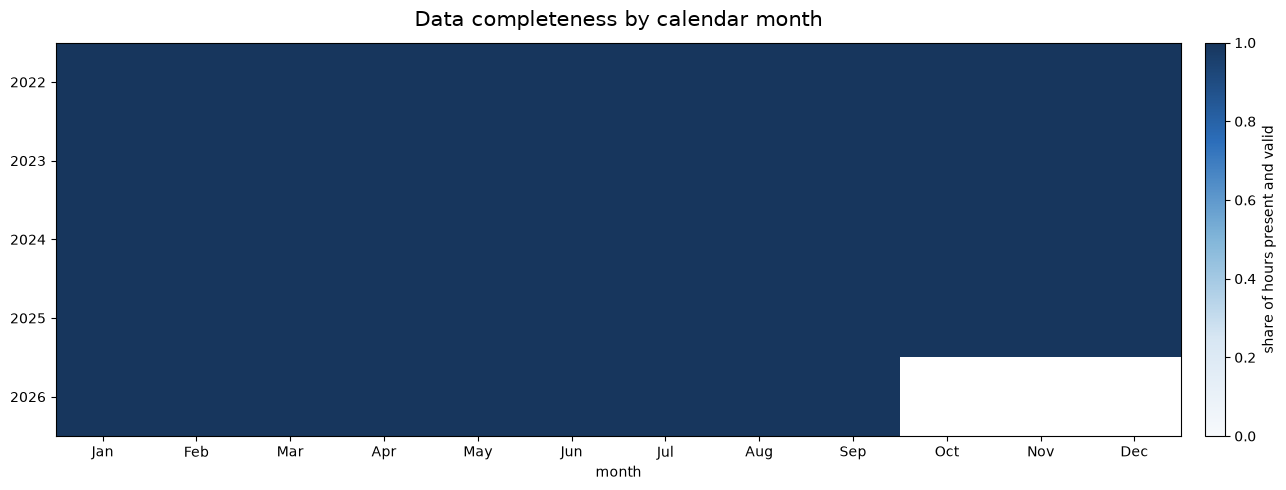

months below full coverage: 5 of 57
timestamp  timestamp
2022       3            0.9987
2023       3            0.9987
2024       3            0.9987
2025       3            0.9987
2026       3            0.9987


In [50]:
full_index = pd.date_range(time_series.index.min(), time_series.index.max(), freq="h")
valid_rows = time_series.index[time_series[SERIES].notna().all(axis=1)]

expected = pd.Series(1, index=full_index).groupby([full_index.year, full_index.month]).size()
observed = pd.Series(1, index=valid_rows).groupby([valid_rows.year, valid_rows.month]).size()

coverage = (observed / expected).unstack().reindex(index=YEARS, columns=range(1, 13))

fig, ax = plt.subplots(figsize=(13, 5.0))
im = ax.imshow(coverage.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap=SUPPORT_CMAP)
ax.set_title("Data completeness by calendar month", fontsize=15, pad=12)
ax.set_yticks(range(len(YEARS)), [str(year) for year in YEARS])
ax.set_xticks(range(12), MONTH_NAMES)
ax.set_xlabel("month")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02).set_label("share of hours present and valid")
plt.tight_layout()
plt.show()

incomplete = coverage.stack().loc[lambda s: s < 1]
print(f"months below full coverage: {len(incomplete)} of {int(coverage.notna().sum().sum())}")
print(incomplete.round(4).to_string())

The record is **complete apart from the months that contain a spring DST switch**, each of which
lands a hair below 1.0 because its local hour 02:00 does not exist — 743 hours in a 744-hour month.
Those are not missing data; they are missing *hours*, and §2.1 already established that nothing
else is absent.

One thing to read correctly: coverage here is measured against the record's **own span**, so the
final, partial month shows as complete — it contains every hour the record claims to contain. The
figure answers "is anything missing inside the downloaded range", not "does the range cover the
whole month".

### 7.2 — Which system variables move together

Spearman rank correlations, so a monotone but non-linear relation still registers. The wind + solar
share of load is included as a derived ratio, because "how much of demand renewables are covering"
is a different question from "how much they are generating".

This is **not** the Pearson `SERIES` correlation matrix — that one's source cell carries no tag and
is excluded. Different method, different columns; if the team wants the Pearson version back, that
means tagging the source cell and revising
[`03.3`](../../.claude/specs/03.3-univariate-and-time-structure.md).

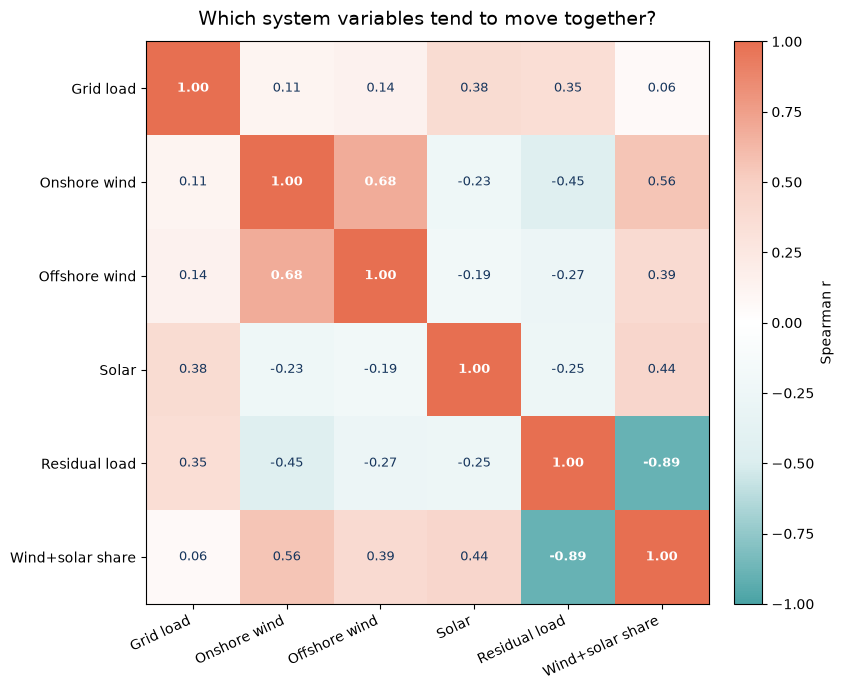

In [51]:
correlation_frame = time_series[["grid_load", "wind_on", "wind_off", "solar", "residual_load"]].copy()
correlation_frame["ws_share"] = time_series["renewables"] / time_series["grid_load"]

CORRELATION_LABELS = [
    "Grid load", "Onshore wind", "Offshore wind", "Solar", "Residual load", "Wind+solar share",
]
correlation = correlation_frame.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.2, 7))
im = ax.imshow(correlation.to_numpy(), vmin=-1, vmax=1, cmap=DIV_CMAP)
ax.set_title("Which system variables tend to move together?", fontsize=14, pad=12)
ax.set_xticks(range(len(CORRELATION_LABELS)), CORRELATION_LABELS, rotation=25, ha="right")
ax.set_yticks(range(len(CORRELATION_LABELS)), CORRELATION_LABELS)

for row in range(len(CORRELATION_LABELS)):
    for column in range(len(CORRELATION_LABELS)):
        value = correlation.iloc[row, column]
        ax.text(
            column, row, f"{value:.2f}", ha="center", va="center", fontsize=9.2,
            color="white" if abs(value) >= 0.58 else COLORS["ink"],
            fontweight="bold" if abs(value) >= 0.58 else "normal",
        )

fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04).set_label("Spearman r")
plt.tight_layout()
plt.show()

`residual_load` correlates strongly and positively with `grid_load` and strongly and negatively
with the wind + solar share — which is the identity behind it, visible as a measurement. More
useful are the weaker cells: **solar and wind are close to uncorrelated hour by hour**, confirming
from a third angle (after §4.4's monthly view and §5.2's daily one) that they are independent
inputs rather than two faces of one "renewables" variable.

### 7.3 — Load duration curves

Each series sorted from highest to lowest, against the share of hours at or above that level. Note
this runs over the **whole multi-year record**, not a single year as the source notebook did, so
"% of hours" mixes several years' seasons together — the curve describes the record, not a typical
year.

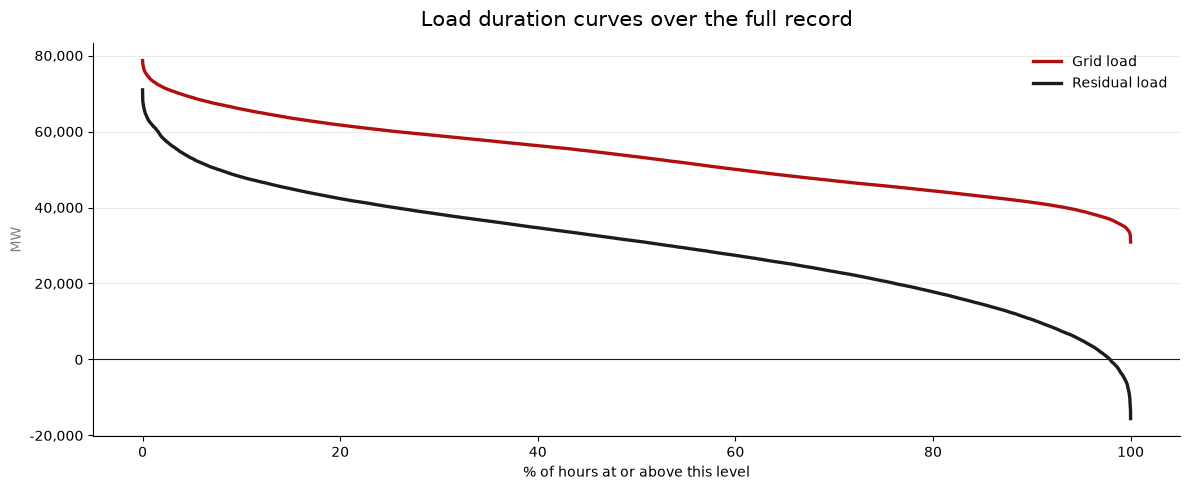

residual load is negative in 2.08 % of hours
  top    5% of hours: grid load >=   68,992 MW   residual load >=   52,919 MW
  top   10% of hours: grid load >=   65,923 MW   residual load >=   48,048 MW
  top   25% of hours: grid load >=   60,173 MW   residual load >=   40,192 MW
  top   50% of hours: grid load >=   53,380 MW   residual load >=   31,152 MW
  top   75% of hours: grid load >=   45,716 MW   residual load >=   20,636 MW
  top   95% of hours: grid load >=   39,083 MW   residual load >=    5,110 MW


In [52]:
DURATION_COLS = ["grid_load", "residual_load"]
share_of_hours = np.linspace(0, 100, len(time_series))

fig, ax = plt.subplots(figsize=(12, 5))
for col in DURATION_COLS:
    ax.plot(
        share_of_hours,
        time_series[col].sort_values(ascending=False).to_numpy(),
        **series_style(col),
    )
ax.axhline(0, color=COLORS["black"], linewidth=0.8)

ax.set_title("Load duration curves over the full record", fontsize=15, pad=12)
ax.set_xlabel("% of hours at or above this level")
ax.set_ylabel("MW", color="grey")
ax.grid(axis="y", color="0.92", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

negative_share = 100 * (time_series["residual_load"] < 0).mean()
print(f"residual load is negative in {negative_share:.2f} % of hours")
for level in (0.05, 0.10, 0.25, 0.50, 0.75, 0.95):
    print(
        f"  top {level:>5.0%} of hours: grid load >= {time_series['grid_load'].quantile(1 - level):>8,.0f} MW"
        f"   residual load >= {time_series['residual_load'].quantile(1 - level):>8,.0f} MW"
    )

The two curves have **different shapes, not just different levels**. `grid_load`'s is flat through
the middle and steep only at its extremes — the classic demand curve of a system whose load is
mostly predictable. `residual_load`'s falls steadily across its whole range and then dives through
zero at the right-hand end.

For capacity thinking that right-hand tail is the interesting one: the hours where residual load is
negative are few, but they are the hours in which something must absorb, curtail or export surplus
generation. The curve gives the team a way to read off how many hours sit beyond any candidate
level — without this notebook having to pick one.

### 7.4 — Wind and solar support through the year

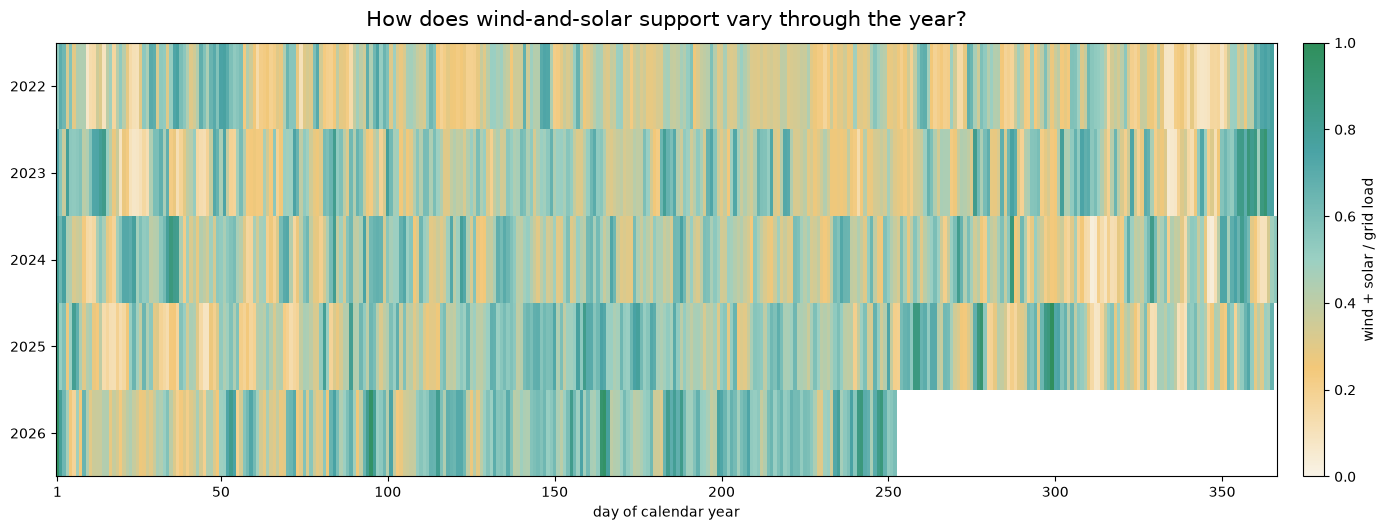

daily wind+solar / load, by year:


,mean,p90,max,days > 80%
timestamp,,,,
2022,0.378,0.593,0.767,0
2023,0.437,0.691,0.921,10
2024,0.436,0.658,0.889,8
2025,0.452,0.675,0.986,11
2026,0.516,0.732,0.970,16



monthly mean and day-to-day spread of that share (all years pooled):
            mean    std
timestamp              
1          0.415  0.200
2          0.428  0.191
3          0.407  0.167
4          0.468  0.155
5          0.477  0.136
6          0.479  0.147
7          0.477  0.134
8          0.434  0.149
9          0.438  0.171
10         0.430  0.193
11         0.377  0.182
12         0.417  0.238


In [53]:
daily_support = pd.DataFrame(
    {
        "load": period_mean(time_series["grid_load"], "D"),
        "renewables": period_mean(time_series["renewables"], "D"),
    }
)
daily_support["share"] = daily_support["renewables"] / daily_support["load"]

support_calendar = (
    daily_support["share"]
    .groupby([daily_support.index.year, daily_support.index.dayofyear])
    .mean()
    .unstack()
    .reindex(index=YEARS, columns=range(1, 367))
)

fig, ax = plt.subplots(figsize=(14, 5.4))
im = ax.imshow(support_calendar.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap=WIND_SOLAR_CMAP)
ax.set_title("How does wind-and-solar support vary through the year?", fontsize=15, pad=12)
ax.set_yticks(range(len(YEARS)), [str(year) for year in YEARS])
ax.set_xticks([0, 49, 99, 149, 199, 249, 299, 349], [1, 50, 100, 150, 200, 250, 300, 350])
ax.set_xlabel("day of calendar year")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02).set_label("wind + solar / grid load")
plt.tight_layout()
plt.show()

HIGH_SUPPORT = 0.80  # descriptive marker for "most of the day's demand", not a threshold

print("daily wind+solar / load, by year:")
display(
    daily_support.groupby(daily_support.index.year)["share"]
    .agg(
        mean="mean",
        p90=lambda s: s.quantile(0.90),
        max="max",
        days_above=lambda s: int((s > HIGH_SUPPORT).sum()),
    )
    .round(3)
    .rename(columns={"days_above": f"days > {HIGH_SUPPORT:.0%}"})
)

print("\nmonthly mean and day-to-day spread of that share (all years pooled):")
monthly_support = daily_support.groupby(daily_support.index.month)["share"].agg(["mean", "std"])
print(monthly_support.round(3).to_string())

What is striking here is how **little seasonal band there is**. Read across any row and the
dominant impression is texture — good weeks and bad weeks — not a summer-high, winter-low gradient.
The printed monthly means confirm it: the share moves only between roughly 0.38 and 0.48 across the
whole calendar, the flattest possible restatement of §4.3's finding that wind's winter strength
substitutes for solar's summer strength.

The seasonality that *is* there lives in the **spread, not the mean**: the day-to-day standard
deviation is markedly larger in the winter months than in the summer ones. Winter holds both the
worst supported days and some of the best, because wind can deliver or fail on any given day, while
summer's solar-driven support is comparatively metronomic. That is the same asymmetry §4.1 found in
daily residual load and §6.1 in its autocorrelation, seen once more as a share of demand.

Down the columns the picture does brighten year on year — the mean share rises steadily, and the
count of days supplying more than 80 % of demand grows from none in the first year to well over a
dozen in the last. No day yet reaches 100 %, but the best days are now within a few points of it.

---

## Findings

A compact summary of what this notebook established, section by section. These are **proposals for
the team, not settled project facts** — they are Claude's reading of the tagged material, and the
team decides what to keep.

> **The record's starting point is not a neutral baseline.** This snapshot opens in 2022, a year the
> team treats as anomalous for the German system, and spans fewer than five years in total. Every
> *trend* statement below — the solar build-out, the falling P10, the growing ramps, the rising
> renewable share — is measured from that opening year and inherits whatever was unusual about it.
> Those statements are provisional until the fetch is widened further back, and re-running this
> notebook on a longer record is expected to change their magnitudes and may change their direction.
>
> The *structural* findings are far more robust to the record's span: the shape of the day and the
> week, the calendar signature of the two tails, the autocorrelation structure, the near-flat
> seasonal renewable contribution, the harmonic content of the daily cycle. Read those as findings
> about the system; read the drift numbers as findings about this particular window.

**Data quality (§2).** The record is clean: zero missing values, zero duplicate timestamps, no
value-range violations, and night-time solar within tolerance. Its only gaps are one spring DST
hour per year, and the autumn fold is silently collapsed by SMARD rather than duplicated — so
"no duplicates" must not be read as "hour-complete". A physically plausible week confirms the
series behave as the domain says they should.

**Univariate and time structure (§3).** Solar is the only series with a clear multi-year trend;
wind is dominated by weather variance and grid load is remarkably stable. The calendar structure is
strong and regular: a weekday plateau with a weekend drop, a daily cycle whose midday behaviour
flips between winter and summer, and a federal-holiday effect worth roughly a fifth of a day's load
that is nearly the same size for every holiday. The residual-load extremes have **mirror-image
calendar signatures** — the oversupply tail is recent, summer, midday and weekend; the
tight-margin tail is winter, weekday and evening, and spread evenly across years.

**Two-series comparisons (§4).** The wind + solar contribution implied by the load/residual gap is
nearly flat across the seasons: wind's winter strength substitutes for solar's summer strength.
Residual load's seasonal contrast is therefore mostly demand seasonality passed through, while the
renewable effect lives in the daily shape, the extremes and the year-on-year drift. Wind and solar
should stay separate features.

**Calendar structure and single events (§5).** Grid load is organised by the working day; residual
load is organised by sunlight, with the working day as a secondary effect. Two Fourier harmonics on
the hour of day encode the mean daily residual-load cycle almost completely, but one does not — the
day is twin-peaked. The Euro 2024 event study is a null result: single cultural events do not move
national demand enough to be worth a feature.

**Temporal dependence and extremes (§6).** After removing weekday × hour means, grid load stays
correlated at every lag out to a week (a slow-moving level a calendar model misses), while residual
load decays within a day and a half with fading 24-hour echoes — lagged features pay off more for
the target than for demand. Residual load's distribution is broad, unimodal and mildly left-skewed,
with about 2 % of hours already negative. Over the record its **P10 has fallen sharply while its P90
has not moved**, and its ramp P99 has grown three times faster than its median.

**Context (§7).** Completeness is total apart from the DST hours. Solar and wind are close to
uncorrelated hour by hour. The two load duration curves differ in shape, not merely in level. And
wind-and-solar support rises year on year at every point in the calendar.

**The single most consequential observation across all of it** is that the two extremes of residual
load are not one phenomenon: they differ in season, hour, day type, trend and mechanism. Whether
the risk flag should treat them as one target or two — and whether the second stress mode should key
on the ramp rather than the level — are modelling decisions this notebook deliberately leaves open.

### 7.5 — Closing self-check

Structural invariants only, and deliberately free of any hardcoded row count or date bound: this
record's extent is expected to change. The comparison against `LOADED` is the mechanical proof that
nothing between §1 and here mutated `time_series`.

In [54]:
assert time_series.index.is_monotonic_increasing, "index is no longer sorted"
assert time_series.index.is_unique, "index has duplicate timestamps"
assert int(time_series[SERIES].isna().sum().sum()) == 0, "NaNs appeared in SERIES"
assert list(time_series.columns) == SERIES + DERIVED, list(time_series.columns)
assert len(time_series) == LOADED["rows"], (len(time_series), LOADED["rows"])
assert time_series.index.min() == LOADED["start"], (time_series.index.min(), LOADED["start"])
assert time_series.index.max() == LOADED["end"], (time_series.index.max(), LOADED["end"])
assert YEARS == sorted(int(y) for y in time_series["year"].unique())

print("closing self-check passed")
print(f"  index sorted and unique, no NaN across the {len(SERIES)} series")
print(f"  columns == SERIES + DERIVED ({len(time_series.columns)} columns) — no flag column crept in")
print(f"  unchanged since §1: {LOADED['rows']:,} rows, {LOADED['start']} -> {LOADED['end']}")
print(f"  years {YEARS}, all derived at run time")

closing self-check passed
  index sorted and unique, no NaN across the 8 series
  columns == SERIES + DERIVED (18 columns) — no flag column crept in
  unchanged since §1: 41,107 rows, 2022-01-01 00:00:00 -> 2026-09-09 23:00:00
  years [2022, 2023, 2024, 2025, 2026], all derived at run time
